In [48]:
# ───────────────────────────────────────────────────────────────
# 0. 설정
# ───────────────────────────────────────────────────────────────
import os, glob, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import norm, linregress
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 120
sns.set(style="whitegrid")

# 경로/참가자 설정
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
PARTICIPANTS = ['00223', 
                '00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228', '00217', '00210'
                ]
GROUP_OUT = os.path.join(os.path.dirname(BASE_DIR), 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

# ───────────────────────────────────────────────────────────────
# 공용 헬퍼
# ───────────────────────────────────────────────────────────────
def out_dir_for(pid: str) -> str:
    d = os.path.join(BASE_DIR, pid, 'summary')
    os.makedirs(d, exist_ok=True)
    return d

def save_df(df: pd.DataFrame, fpath: str, index=True):
    df.to_csv(fpath, index=index)
    print(f'📝 saved → {fpath}')

def save_fig(fig, fpath: str, dpi=300):
    fig.savefig(fpath, dpi=dpi, bbox_inches='tight')
    print(f'🖼  saved → {fpath}')

# ---------- meta-d′ MLE utils (기존 로직) ---------------------
# === zROC slope 안전 추정 유틸 ===
def _safe_slope(zF, zH, min_pts=3, s_min=0.2, s_max=5.0):
    zF = np.asarray(zF); zH = np.asarray(zH)
    mask = np.isfinite(zF) & np.isfinite(zH)
    zF, zH = zF[mask], zH[mask]
    if zF.size < min_pts or len(np.unique(zF)) < 2:
        return np.nan
    s = linregress(zF, zH)[0]
    if not np.isfinite(s) or (s <= 0):
        return np.nan
    return float(np.clip(s, s_min, s_max))

def make_counts(df_sub, n_ratings):
    sig = df_sub[df_sub.Stim=='first']
    noi = df_sub[df_sub.Stim=='second']
    r_hi2lo = range(n_ratings, 0, -1)
    r_lo2hi = range(1, n_ratings+1)
    
    nR_S1 = [((sig.ConfLevel==r)&(sig.RespInt=='first' )).sum() for r in r_hi2lo] + \
            [((sig.ConfLevel==r)&(sig.RespInt=='second')).sum() for r in r_lo2hi]
    nR_S2 = [((noi.ConfLevel==r)&(noi.RespInt=='first' )).sum() for r in r_hi2lo] + \
            [((noi.ConfLevel==r)&(noi.RespInt=='second')).sum() for r in r_lo2hi]
    return np.array(nR_S1, float)+0.5, np.array(nR_S2, float)+0.5

def fit_meta_d_logL(params, obj):
    meta_d1, t2c_vec     = params[0], params[1:]
    nR_S1,nR_S2,nR,d1,c1,s = obj
    shift = meta_d1*(c1/d1)
    mu1,sd1 = -meta_d1/2 - shift, 1.0
    mu2,sd2 =  meta_d1/2 - shift, 1.0/s
    C1,I1   = nR_S1[:nR], nR_S2[:nR]
    C2,I2   = nR_S2[nR:], nR_S1[nR:]
    crits   = [-np.inf]+list(t2c_vec[:nR-1])+[c1]+list(t2c_vec[nR-1:])+[np.inf]
    pr  = []
    pr.append([(norm.cdf(crits[i+1],mu1,sd1)-norm.cdf(crits[i],mu1,sd1))/norm.cdf(c1,mu1,sd1) for i in range(nR)])
    pr.append([(norm.cdf(crits[i+1],mu2,sd2)-norm.cdf(crits[i],mu2,sd2))/norm.cdf(c1,mu2,sd2) for i in range(nR)])
    pr.append([((1-norm.cdf(crits[nR+i],mu2,sd2))-(1-norm.cdf(crits[nR+i+1],mu2,sd2)))/(1-norm.cdf(c1,mu2,sd2)) for i in range(nR)])
    pr.append([((1-norm.cdf(crits[nR+i],mu1,sd1))-(1-norm.cdf(crits[nR+i+1],mu1,sd1)))/(1-norm.cdf(c1,mu1,sd1)) for i in range(nR)])
    pr = [np.clip(p,1e-10,1-1e-10) for p in pr]
    ll = (C1*np.log(pr[0])).sum()+(I1*np.log(pr[1])).sum()+(C2*np.log(pr[2])).sum()+(I2*np.log(pr[3])).sum()
    return -ll if np.isfinite(ll) else 1e300

def fit_meta_d_MLE(nR_S1, nR_S2, s=1.0):
    assert len(nR_S1)==len(nR_S2) and len(nR_S1)%2==0
    nR  = len(nR_S1)//2
    cumHR  = [sum(nR_S2[c:])/sum(nR_S2) for c in range(1,2*nR)]
    cumFAR = [sum(nR_S1[c:])/sum(nR_S1) for c in range(1,2*nR)]
    t1i    = nR-1
    zHR_t1  = norm.ppf(cumHR[t1i])
    zFAR_t1 = norm.ppf(cumFAR[t1i])
    d1      = zHR_t1 - zFAR_t1
    # ✅ d1 안정화
    if (not np.isfinite(d1)) or (abs(d1) < 1e-6):
        d1 = np.sign(d1) * 1e-6 if d1 != 0 else 1e-6
    c_all  = -(norm.ppf(cumHR)+norm.ppf(cumFAR))/2
    c1     = c_all[t1i]
    meta0  = d1
    shift0 = meta0 * (c1 / max(abs(d1), 1e-6))
    t2c0   = np.delete(c_all,t1i) - shift0
    nCrit  = 2*nR-1
    bounds = Bounds([-10]+[-20]*(nCrit-1),[10]+[20]*(nCrit-1))
    A      = np.zeros((nCrit-1,nCrit)); A[np.arange(nCrit-1),np.arange(nCrit-1)]=1; A[np.arange(nCrit-1),np.arange(1,nCrit)]=-1
    lc     = LinearConstraint(A,-np.inf,-1e-5)
    res    = minimize(fit_meta_d_logL, np.r_[meta0,t2c0],
                      args=([nR_S1,nR_S2,nR,d1,c1,s],),
                      method='trust-constr',jac='2-point',hess=SR1(),
                      bounds=bounds,constraints=[lc])
    meta_hat = abs(res.x[0])
    # ✅ 정식 UV–SDT: d_a를 직접 계산
    da_uv = np.sqrt(2.0/(1.0 + s*s)) * ( zHR_t1 - s*zFAR_t1 )
    meta_da_uv = np.sqrt(2.0/(1.0 + s*s)) * s * meta_hat
    return d1, da_uv, meta_hat, meta_da_uv
    
# ───────────────────────────────────────────────────────────────
# response-specific meta-dₐ (Maniscalco & Lau 2012 스타일)
#   - meta_da_rS1 : R1(여기서는 'no') 응답 기반
#   - meta_da_rS2 : R2(여기서는 'yes') 응답 기반
# ───────────────────────────────────────────────────────────────

def fitM_rS1_logL(params, obj):
    """
    R1(여기서는 'no') 응답에 대한 meta-d' log-likelihood
    params : [meta_d_rS1, t2c_1, t2c_2, ..., t2c_{m-1}]
    obj    : (nR_rS1, nR_rS2, t1_index, s, fncdf)
    """
    meta_d_rS1, t2c = params[0], params[1:]
    nR_rS1, nR_rS2, t1_i, s, fncdf = obj

    m = len(nR_rS1) // 2  # rating 수

    # type-1 criterion 위치 c1 (R1/R2 경계; 여기서는 NO vs YES)
    # t1_i는 type-1 경계 index (예: m-1)
    # UV-SDT 좌표에서 d₁', c₁'로 변환
    # 여기서는 s 값을 이미 da 계산에 반영했다고 보고 EV로 취급
    # (즉, meta_d_rS1는 이미 UV 모델에 상응하는 값)
    d1 = meta_d_rS1
    c1 = 0.0  # rs-meta에서는 type-1 criterion을 원점으로 두고 상대 위치로만 최적화

    # rating 경계 (type-2 기준들; c1 기준으로 좌우)
    # R1 쪽(왼쪽) m 구간에 대한 m-1개 기준
    crit_r1 = np.r_[-np.inf, np.sort(t2c[:m-1]), c1]
    crit_r2 = np.r_[c1, np.sort(t2c[m-1:]), np.inf]

    # S1, S2 분포 (EV 좌표)
    mu1, sd1 = -d1/2, 1.0
    mu2, sd2 =  d1/2, 1.0

    # R1 응답일 때 rating별 조건부 확률 P(rating | R1, S)
    # S1 trial에서 R1=‘no’ 영역 = (-inf, c1)
    pr_r1_s1 = []
    pr_r1_s2 = []
    for i in range(m):
        p_s1 = fncdf(crit_r1[i+1], mu1, sd1) - fncdf(crit_r1[i], mu1, sd1)
        p_s2 = fncdf(crit_r1[i+1], mu2, sd2) - fncdf(crit_r1[i], mu2, sd2)
        pr_r1_s1.append(p_s1)
        pr_r1_s2.append(p_s2)

    # 조건부 확률로 정규화 (R1 응답이 일어났다는 조건)
    pr_r1_s1 = np.array(pr_r1_s1)
    pr_r1_s2 = np.array(pr_r1_s2)
    pr_r1_s1 /= pr_r1_s1.sum()
    pr_r1_s2 /= pr_r1_s2.sum()

    # 관측 카운트 (R1 응답 부분만 사용)
    C1 = nR_rS1[:m]  # S1 & R1
    C2 = nR_rS2[:m]  # S2 & R1

    pr_r1_s1 = np.clip(pr_r1_s1, 1e-10, 1-1e-10)
    pr_r1_s2 = np.clip(pr_r1_s2, 1e-10, 1-1e-10)

    ll = (C1*np.log(pr_r1_s1)).sum() + (C2*np.log(pr_r1_s2)).sum()
    return -ll if np.isfinite(ll) else 1e300


def fitM_rS2_logL(params, obj):
    """
    R2(여기서는 'yes') 응답에 대한 meta-d' log-likelihood
    params : [meta_d_rS2, t2c_1, ..., t2c_{m-1}]
    obj    : (nR_rS1, nR_rS2, t1_index, s, fncdf)
    """
    meta_d_rS2, t2c = params[0], params[1:]
    nR_rS1, nR_rS2, t1_i, s, fncdf = obj

    m = len(nR_rS1) // 2

    d1 = meta_d_rS2
    c1 = 0.0

    crit_r1 = np.r_[-np.inf, np.sort(t2c[:m-1]), c1]
    crit_r2 = np.r_[c1, np.sort(t2c[m-1:]), np.inf]

    mu1, sd1 = -d1/2, 1.0
    mu2, sd2 =  d1/2, 1.0

    # R2 쪽(오른쪽) m 구간 (c1 ~ +inf)
    pr_r2_s1 = []
    pr_r2_s2 = []
    for i in range(m):
        p_s1 = fncdf(crit_r2[i+1], mu1, sd1) - fncdf(crit_r2[i], mu1, sd1)
        p_s2 = fncdf(crit_r2[i+1], mu2, sd2) - fncdf(crit_r2[i], mu2, sd2)
        pr_r2_s1.append(p_s1)
        pr_r2_s2.append(p_s2)

    pr_r2_s1 = np.array(pr_r2_s1)
    pr_r2_s2 = np.array(pr_r2_s2)
    pr_r2_s1 /= pr_r2_s1.sum()
    pr_r2_s2 /= pr_r2_s2.sum()

    C1 = nR_rS1[m:]  # S1 & R2
    C2 = nR_rS2[m:]  # S2 & R2

    pr_r2_s1 = np.clip(pr_r2_s1, 1e-10, 1-1e-10)
    pr_r2_s2 = np.clip(pr_r2_s2, 1e-10, 1-1e-10)

    ll = (C1*np.log(pr_r2_s1)).sum() + (C2*np.log(pr_r2_s2)).sum()
    return -ll if np.isfinite(ll) else 1e300


def fit_rs_meta_d_MLE(nR_S1, nR_S2, s=1.0, fncdf=norm.cdf, fninv=norm.ppf):
    """
    Maniscalco & Lau의 response-specific meta-d' 추정 (UV 모델에 맞춰 약간 단순화한 Python 버전)

    입력:
        nR_S1, nR_S2 : 길이 2m 벡터 (S1=noise, S2=signal)
                       [R1_high→low, R2_low→high] 순서
        s            : zROC slope (YN에서 추정한 s_est)
    출력 dict:
        'meta_da_rS1', 'meta_da_rS2'
    """
    nR_S1 = np.array(nR_S1, float)
    nR_S2 = np.array(nR_S2, float)
    assert len(nR_S1) == len(nR_S2) and len(nR_S1) % 2 == 0
    m = len(nR_S1) // 2

    # 먼저 전체 데이터로부터 type-1 d₁, c₁, dₐ를 계산 (fit_meta_d_MLE 재사용)
    d1, da_uv, meta_d_overall, meta_da_overall = fit_meta_d_MLE(nR_S1, nR_S2, s=s)

    # type-1 경계 index (Maniscalco & Lau convention: m-1)
    t1_i = m - 1

    # 초기값: overall meta-d를 rs meta-d의 초기값으로 사용
    meta0_rS1 = meta_d_overall
    meta0_rS2 = meta_d_overall

    # t2 기준 초기값: 간단히 0으로 시작 (평균 기준)
    t2c0 = np.zeros(2*m - 2)

    # 공통 bounds / constraint
    nCrit = 2*m - 1  # meta_d + (2m-2) 기준
    lb = np.r_[-10.0, np.full(nCrit-1, -20.0)]
    ub = np.r_[ 10.0, np.full(nCrit-1,  20.0)]
    bounds = Bounds(lb, ub)

    # 기준들이 좌→우로 증가하도록 linear constraint (단, 여기선 너무 빡세게 묶지 않고 완화)
    A = np.zeros((nCrit-2, nCrit))
    # meta_d는 첫 번째 원소라, 그 이후 기준들에 대해 차분 제약
    for i in range(nCrit-2):
        A[i, i+1] =  1
        A[i, i+2] = -1
    lc = LinearConstraint(A, -np.inf, 0.0)

    # 1) R1(no) 기반 meta-d
    obj_rS1 = (nR_S1, nR_S2, t1_i, s, fncdf)
    res_rS1 = minimize(
        fitM_rS1_logL,
        x0=np.r_[meta0_rS1, t2c0],
        args=(obj_rS1,),
        method='trust-constr',
        jac='2-point',
        hess=SR1(),
        bounds=bounds,
        constraints=[lc],
        options={'maxiter': 200}
    )
    meta_d_rS1_hat = float(res_rS1.x[0])

    # 2) R2(yes) 기반 meta-d
    obj_rS2 = (nR_S1, nR_S2, t1_i, s, fncdf)
    res_rS2 = minimize(
        fitM_rS2_logL,
        x0=np.r_[meta0_rS2, t2c0],
        args=(obj_rS2,),
        method='trust-constr',
        jac='2-point',
        hess=SR1(),
        bounds=bounds,
        constraints=[lc],
        options={'maxiter': 200}
    )
    meta_d_rS2_hat = float(res_rS2.x[0])

    # UV-SDT로 변환된 meta-dₐ (overall에서와 같은 스케일 사용)
    # da = sqrt(2/(1+s²)) * (zH - s*zF)
    # 여기서는 meta-d를 d₁처럼 보고 같은 계수로 meta-dₐ 계산
    scale = np.sqrt(2.0 / (1.0 + s*s)) * s
    meta_da_rS1 = scale * meta_d_rS1_hat
    meta_da_rS2 = scale * meta_d_rS2_hat

    return {
        'meta_d_rS1':   meta_d_rS1_hat,
        'meta_d_rS2':   meta_d_rS2_hat,
        'meta_da_rS1':  meta_da_rS1,
        'meta_da_rS2':  meta_da_rS2
    }

def estimate_s_from_type1_2ifc(df_sub, n_bins=6):
    sub = df_sub.sort_values('EffRT').reset_index(drop=True)
    sub['Bin'] = pd.qcut(-sub.EffRT, q=n_bins, labels=False, duplicates='drop')+1
    actual_bins = int(sub['Bin'].nunique())
    if actual_bins < 2:
        return np.nan
        
    Nsig=(sub.Stim=='first').sum(); Nnoi=(sub.Stim=='second').sum()
    zHR,zFAR=[],[]
    for T in range(2,n_bins+1):
        sel=sub.Bin>=T
        hits=((sub.Stim=='first') & sel & (sub.RespInt=='first')).sum()
        fas =((sub.Stim=='second')& sel & (sub.RespInt=='first')).sum()
        HR =(hits +0.5)/(Nsig+1); FAR=(fas+0.5)/(Nnoi+1)
        zHR.append(norm.ppf(HR)); zFAR.append(norm.ppf(FAR))
    if len(zHR) < 2:
        return np.nan

    return _safe_slope(np.array(zFAR), np.array(zHR))

def calc_slope_yn_type1(df_sub, n_bins=6):
    sub = df_sub.sort_values('EffRT').reset_index(drop=True)
    sub['Bin'] = pd.qcut(-sub.EffRT, q=n_bins, labels=False, duplicates='drop') + 1
    
    # 실제 생성된 bin 개수 확인
    actual_bins = int(sub['Bin'].nunique())
    if actual_bins < 2:
        return np.nan
    print("actual_bins:", actual_bins)
    print(sub['Bin'].value_counts().sort_index())
        
    # --- type-1 signal/noise & response 정의 ---
    is_signal = (sub.Stim == 'present')   # S1
    is_noise  = (sub.Stim == 'absent')    # S2
    resp_yes  = (sub.RespInt == 'yes')    # R1

    Nsig = int(is_signal.sum())
    Nnoi = int(is_noise.sum())
    if Nsig == 0 or Nnoi == 0:
        return np.nan

    zHR, zFAR = [], []
    for T in range(2, n_bins+1):
        sel  = (sub.Bin >= T)

        hits = (is_signal & resp_yes & sel).sum()
        fas  = (is_noise  & resp_yes & sel).sum()

        HR  = (hits + 0.5) / (Nsig + 1)
        FAR = (fas  + 0.5) / (Nnoi + 1)

        zHR.append(norm.ppf(HR))
        zFAR.append(norm.ppf(FAR))
    # ROC 점이 2개 미만이면 slope 불안정
    if len(zHR) < 2:
        return np.nan

    return _safe_slope(np.array(zFAR), np.array(zHR))


# ───────────────────────────────────────────────────────────────
# 1. 개인 분석 함수 (한 명 처리)
# ───────────────────────────────────────────────────────────────
def analyze_subject(pid: str):
    """한 참가자 분석 + summary 저장, 그리고 그룹 요약에 필요한 DF 반환"""
    OUT = out_dir_for(pid)

    # 0) 데이터 로드 (자동 탐색)
    pattern = os.path.join(BASE_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f'입력 파일 없음: {pattern}')
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()

    # A. WM_probe 정확도 (overall & followed task)
    followed_by=[]
    for i,row in df.iterrows():
        if row.Task=='WM_probe':
            followed_by.append(df.loc[i-1,'Task'] if i>0 else 'Unknown')
        else:
            followed_by.append(None)
    df['FollowedBy']=followed_by

    overall = (df[df.Task=='WM_probe']
                 .groupby('Category')['Combined_Correct']
                 .mean().reset_index(name='Combined_Correct'))
    overall['Accuracy (%)']=overall['Combined_Correct']*100
    overall['Type']='Overall'

    wm = df[df.Task=='WM_probe'].copy()
    wm = wm[wm.FollowedBy.notna()]
    grouped = (wm.groupby(['Category','FollowedBy'])['Combined_Correct']
                 .mean().reset_index())
    grouped['Accuracy (%)']=grouped['Combined_Correct']*100
    grouped['Type']=grouped['FollowedBy'].map({'2IFC':'After 2IFC','YN':'After YN'})
    plot_df = pd.concat([overall[['Category','Accuracy (%)','Type']],
                         grouped[['Category','Accuracy (%)','Type']]], ignore_index=True)
    plot_df.Category = pd.Categorical(plot_df.Category, ['SC','CC','CI'], ordered=True)
    plot_df.Type     = pd.Categorical(plot_df.Type,['Overall','After 2IFC','After YN'], ordered=True)

    plt.figure(figsize=(8,6))
    ax = sns.barplot(data=plot_df, x="Category", y="Accuracy (%)", hue="Type",
                     palette=['#4c72b0','#55a868','#c44e52'])
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='edge', fontsize=9)
    ax.set(title=f"[{pid}] WM Accuracy by Condition & Followed Task",
           xlabel="Condition", ylabel="Accuracy (%)")
    ax.set_ylim(0,100); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(plt.gcf(), os.path.join(OUT, f'{pid}_wm_accuracy.png')); plt.close()

    # B. 2IFC vs YN 정확도
    task_df = df[df.Task.isin(['2IFC','YN'])]
    task_acc = (task_df.groupby(['Task','Category'])['Combined_Correct']
                          .mean().reset_index())
    task_acc['Accuracy (%)']=task_acc['Combined_Correct']*100
    task_acc.Category = pd.Categorical(task_acc.Category, ['SC','CC','CI'], ordered=True)

    plt.figure(figsize=(8,6))
    ax = sns.barplot(data=task_acc, x="Category", y="Accuracy (%)", hue="Task", palette="Set2")
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='edge', fontsize=9)
    ax.set(title=f"[{pid}] Accuracy of 2IFC and YN by Condition", xlabel="Condition", ylabel="Accuracy (%)")
    ax.set_ylim(0,100); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(plt.gcf(), os.path.join(OUT, f'{pid}_accuracy_2ifc_yn.png')); plt.close()

    # C. 2IFC staircase contrast
    df2 = df[df.Task=='2IFC'].copy()
    df2['Category']=pd.Categorical(df2['Category'], ['SC','CC','CI'], ordered=True)
    summary = (df2.groupby('Category')['Contrast']
                .agg(['mean','std','count']).rename(columns={'mean':'Mean','std':'SD','count':'N'}))
    summary['SEM']=summary['SD']/np.sqrt(summary['N'])
    fig,ax = plt.subplots(figsize=(6,4))
    bars = ax.bar(summary.index, summary.Mean, yerr=summary.SEM, capsize=5)
    for bar,(cond,row) in zip(bars, summary.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, row.Mean+row.SEM*0.2, f"{row.Mean:.3f}",
                ha='center', va='bottom', fontsize=9)
    ax.set(xlabel='Condition', ylabel='Mean Contrast (±SEM)', title=f'[{pid}] 2IFC Staircase Converged Contrast')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(fig, os.path.join(OUT, f'{pid}_staircase_contrast.png')); plt.close()

    # D. 2IFC meta (unequal)
    
    df2 = df[df.Task=='2IFC'].copy()
    df2['FinalResponse']=df2.Response.fillna(df2.LateResponse)
    df2 = df2[df2.FinalResponse.isin(['left','right'])]
    df2['RespInt']=df2.FinalResponse.map({'left':'first','right':'second'})
    df2['Stim']   = df2.apply(lambda r: r.RespInt if r.Combined_Correct
                              else ('second' if r.RespInt=='first' else 'first'),axis=1)
    df2['EffRT']  = df2.RT.fillna(df2.LateResponseRT)
    df2 = df2.dropna(subset=['EffRT'])
    n_ratings=6
    df2['ConfLevel']=pd.qcut(-df2.EffRT, q=n_ratings, labels=False, duplicates='drop')+1

    rows=[]
    for cond in ['SC','CC','CI']:
        sub=df2[df2.Category==cond]
        if sub.empty:
            rows.append({'Condition':cond,'slope':np.nan,'d1':np.nan,'da':np.nan,
                         'meta_d':np.nan,'meta_da':np.nan,'M_ratio (da)':np.nan})
            continue
        s = estimate_s_from_type1_2ifc(sub, n_bins=n_ratings)
        s = 1.0 if np.isnan(s) else float(s)
        nR_S1,nR_S2 = make_counts(sub, n_ratings)
        d1, da_uv, meta_d, meta_da_uv = fit_meta_d_MLE(nR_S1,nR_S2,s=s)
        rows.append({'Condition':cond,'s (type1 zROC)':round(s,3),
                     'd1 (EV)':round(d1,3),'da':round(da_uv,3),
                     'meta_d':round(meta_d,3),'meta_da':round(meta_da_uv,3),
                     'M_ratio (meta_d/d1)':round(meta_d/d1,3) if d1 else np.nan,
                     'M_ratio (meta_da/da)': round(meta_da_uv/da_uv,3) if da_uv else np.nan
            })
    
    df_2ifc = pd.DataFrame(rows).set_index('Condition')
    save_df(df_2ifc, os.path.join(OUT, f'{pid}_2ifc_meta.csv'))

    # E. YN meta (unequal)
        # E. YN meta (unequal + response-specific meta-da)
    dfyn = df[df.Task=='YN'].copy()
    dfyn['Response'] = dfyn['Response'].replace('no_response', np.nan)
    dfyn['FinalResponse'] = dfyn.Response.fillna(dfyn.LateResponse)
    dfyn = dfyn[dfyn.FinalResponse.isin(['left','right'])]

    # R1 / R2, S1 / S2 정의
    dfyn['RespInt'] = dfyn.FinalResponse.map({'left':'yes','right':'no'})   # R1 = no, R2 = yes
    dfyn['Stim']    = np.where(dfyn.FacePresent, 'present', 'absent')      # S1 = absent, S2 = present

    # 유효 RT
    dfyn['EffRT']   = dfyn.RT.fillna(dfyn.LateResponseRT)
    dfyn = dfyn.dropna(subset=['EffRT'])

    # 신뢰도 bin = 6 (2IFC와 동일하게 사용)
    n_ratings = 6
    dfyn['ConfLevel'] = pd.qcut(
        -dfyn.EffRT, q=n_ratings,
        labels=False, duplicates='drop'
    ) + 1

    # 필수 컬럼 & 조건 필터
    dfyn = dfyn.dropna(subset=['Category','Stim','RespInt','ConfLevel'])
    dfyn = dfyn[dfyn.Category.isin(['SC','CC','CI'])]

    rows_yn = []

    for cond in ['SC','CC','CI']:
        sub = dfyn[dfyn.Category == cond]
        if sub.empty:
            rows_yn.append({
                'Condition': cond,
                'slope': np.nan,
                'd1': np.nan,
                'da': np.nan,
                'meta_d': np.nan,
                'meta_da': np.nan,
                'meta_da_yes': np.nan,
                'meta_da_no': np.nan,
                'M_ratio (da)': np.nan
            })
            continue

        # ---- 1) type-1 zROC slope s_est (RT 기반, bin = 6) ----
        s_est = calc_slope_yn_type1(sub, n_bins=n_ratings)
        if (s_est is None) or (not np.isfinite(s_est)) or (s_est <= 0):
            s_est = 1.0   # fallback: EV 모델

        # ---- 2) nR_S1 / nR_S2 구성 (R1=YES 높→낮, R2=NO 낮→높) ----
        r_hi2lo = range(n_ratings, 0, -1)      # 예: 6,5,4,3,2,1
        r_lo2hi = range(1, n_ratings+1)        # 예: 1,2,3,4,5,6

        # SDT canonical:
        #   S1 = absent (noise)
        #   S2 = present (signal)
        #   R1 = 'no'
        #   R2 = 'yes'
        abse = sub[sub.Stim == 'absent']   # S1
        pres = sub[sub.Stim == 'present']  # S2

        # ✅ HR/FAR 확인용
        Nsig = (sub.Stim == 'present').sum()
        Nnoi = (sub.Stim == 'absent').sum()
        
        n_hit = ((sub.Stim == 'present') & (sub.RespInt == 'yes')).sum()
        n_fa  = ((sub.Stim == 'absent')  & (sub.RespInt == 'yes')).sum()
        
        HR  = (n_hit + 0.5) / (Nsig + 1)
        FAR = (n_fa  + 0.5) / (Nnoi + 1)
        
        print(f"\n[{pid} | {cond}]")
        print(f"Nsig={Nsig}, Nnoi={Nnoi}")
        print(f"hits={n_hit}, false alarms={n_fa}")
        print(f"HR={HR:.3f}, FAR={FAR:.3f}")
        
        if HR < FAR:
            print(f"⚠️ WARNING: {pid} {cond} has HR < FAR")

        
        nR_S1 = [((abse.ConfLevel == r) & (abse.RespInt == 'no')).sum() for r in r_hi2lo] + \
        [((abse.ConfLevel == r) & (abse.RespInt == 'yes')).sum()  for r in r_lo2hi]

        nR_S2 = [((pres.ConfLevel == r) & (pres.RespInt == 'no')).sum() for r in r_hi2lo] + \
                [((pres.ConfLevel == r) & (pres.RespInt == 'yes')).sum()  for r in r_lo2hi]
        
        nR_S1 = np.array(nR_S1, float) + 0.5
        nR_S2 = np.array(nR_S2, float) + 0.5

        # ---- 3) overall meta-da (전체 YES+NO 기반, 기존 MLE) ----
        d1, da_uv, meta_d, meta_da_uv = fit_meta_d_MLE(nR_S1, nR_S2, s=s_est)

        # ---- 4) response-specific meta-da (Maniscalco & Lau 2012) ----
        # 여기서 S1 = absent, S2 = present, R1 = no, R2 = yes 이므로
        #   meta_da_rS1 → No 응답 기반 meta-dₐ
        #   meta_da_rS2 → Yes  응답 기반 meta-dₐ
        fit_rs = fit_rs_meta_d_MLE(nR_S1, nR_S2, s=s_est)
        meta_da_yes = fit_rs['meta_da_rS2']
        meta_da_no  = fit_rs['meta_da_rS1']

        # ---- 5) 기록 ----
        rows_yn.append({
            'Condition':      cond,
            'slope':          round(float(s_est), 3),
            'd1':             round(float(d1), 3),
            'da':             round(float(da_uv), 3),
            'meta_d':         round(float(meta_d), 3),
            'meta_da':        round(float(meta_da_uv), 3),
            'meta_da_yes':    round(float(meta_da_yes), 3) if np.isfinite(meta_da_yes) else np.nan,
            'meta_da_no':     round(float(meta_da_no),  3) if np.isfinite(meta_da_no)  else np.nan,
            'M_ratio (da)':   round(float(meta_da_uv/da_uv), 3)
                              if np.isfinite(da_uv) and (da_uv != 0) and np.isfinite(meta_da_uv)
                              else np.nan
        })

    df_yn = pd.DataFrame.from_records(rows_yn).set_index('Condition')
    save_df(df_yn, os.path.join(OUT, f'{pid}_yn_meta.csv'))

    # G. YN HR/FAR & criterion
    results=[]
    for cond in ['SC','CC','CI']:
        sub = dfyn[dfyn['Category']==cond]
        if sub.empty: continue
        Nsig=(sub['Stim']=='present').sum(); Nnoi=(sub['Stim']=='absent').sum()
        n_hit=((sub['Stim']=='present')&(sub['RespInt']=='yes')).sum()
        n_fa =((sub['Stim']=='absent') &(sub['RespInt']=='yes')).sum()
        HR=(n_hit+0.5)/(Nsig+1); FAR=(n_fa+0.5)/(Nnoi+1)
        results.append({'Condition':cond,'Nsig':Nsig,'Nnoi':Nnoi,'n_hit':n_hit,'n_FA':n_fa,'HR':round(HR,3),'FAR':round(FAR,3)})
    df_hrcr = pd.DataFrame(results).set_index('Condition')
    save_df(df_hrcr, os.path.join(OUT, f'{pid}_yn_hr_far.csv'))

    # criterion(c) plot 저장
    zHR = norm.ppf(df_hrcr.HR.values); zFAR=norm.ppf(df_hrcr.FAR.values)
    cvals = -0.5*(zHR+zFAR)
    fig,ax=plt.subplots(figsize=(6,4))
    x = np.arange(len(df_hrcr.index))
    bars=ax.bar(x, cvals, color='C3'); ax.set_xticks(x); ax.set_xticklabels(df_hrcr.index)
    for i,(b,c) in enumerate(zip(bars,cvals)):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{c:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set(title=f'[{pid}] YN Task Criterion by Condition', xlabel='Condition', ylabel='c')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(fig, os.path.join(OUT, f'{pid}_yn_criterion.png')); plt.close()

    # 그룹 요약용 리턴 (핵심)
    det2 = df_2ifc[['da']].rename(columns={'da':'d_a'}); det2['Condition']=df_2ifc.index; det2['Task']='2IFC'; det2['Subject']=pid
    dety = df_yn   [['da']].rename(columns={'da':'d_a'}); dety['Condition']=df_yn.index;   dety['Task']='YN';    dety['Subject']=pid
    det  = pd.concat([det2,dety], ignore_index=True)

    return {
        'pid': pid,
        'wm_plot_df' : plot_df.assign(Subject=pid).copy(),
        'task_acc':   task_acc.copy(),
        'staircase':  summary.reset_index().copy(),
        'twoifc':     df_2ifc.reset_index().copy(),
        'yn':         df_yn.reset_index().assign(Subject=pid).copy(),
        'mratio' : df_2ifc[['meta_d','meta_da','da']].reset_index().assign(Subject=pid).copy(),
        'hrfar':      df_hrcr.reset_index().assign(Subject=pid).copy(),
        'det':        det.rename(columns={'d_a':'da'})
    }


# ───────────────────────────────────────────────────────────────
# 2. 모든 참가자 실행
# ───────────────────────────────────────────────────────────────
all_results = []
for pid in PARTICIPANTS:
    print(f'▶ analyzing {pid} ...')
    res = analyze_subject(pid)
    all_results.append(res)

# ───────────────────────────────────────────────────────────────
# 3. 그룹 요약 & 그림
# ───────────────────────────────────────────────────────────────
df_det_all  = pd.concat([r['det'] for r in all_results], ignore_index=True)   # (Subject, Condition, Task, da)
df_hrfar_all= pd.concat([r['hrfar'] for r in all_results], ignore_index=True)

# within-subject SEM (Cousineau–Morey)
def within_subject_sem(df, dv, subject_col, within_cols):
    df = df.copy()
    grand = df.groupby(subject_col)[dv].transform('mean')
    overall = df[dv].mean()
    df['_adj'] = df[dv] - grand + overall
    k = df.groupby(subject_col).size().mean()  # 평균 셀 수
    # 여기선 조건*태스크 조합으로 그리지만, within_cols에 맞춰 계산됨
    sem = df.groupby(within_cols)['_adj'].sem()
    # Morey 보정 (within level 수 = 각 subject의 unique within level 수)
    k = df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
    factor = np.sqrt(k/(k-1)) if k>1 else 1.0
    out = (pd.concat([df.groupby(within_cols)[dv].mean(), sem*factor], axis=1)
             .reset_index().rename(columns={dv:'da_mean','_adj':'da_wsem'}))
    return out

order     = ['SC','CC','CI']
hue_order = ['2IFC','YN']
palette   = ['#4c72b0','#55a868']

det_ws = within_subject_sem(df_det_all, dv='da', subject_col='Subject', within_cols=['Condition','Task'])
det_ws['Condition']=pd.Categorical(det_ws['Condition'], order, ordered=True)
det_ws = det_ws.sort_values(['Task','Condition'])

# 평균 막대
plt.figure(figsize=(7.2,5.2))
ax = sns.barplot(data=det_ws, x='Condition', y='da_mean', hue='Task',
                 order=order, hue_order=hue_order, palette=palette, errorbar=None, dodge=True)

# 검정 에러바
idx = np.arange(len(order)); total_w=0.8; bar_w = total_w/len(hue_order)
for j,task in enumerate(hue_order):
    sub = det_ws[det_ws['Task']==task].set_index('Condition').reindex(order)
    y=sub['da_mean'].values; e=sub['da_wsem'].values
    x=idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# 평균값 라벨(0은 생략)
for p in ax.patches:
    x = p.get_x()+p.get_width()/2; y = p.get_height()
    if abs(y)>1e-6:
        ax.text(x, y+0.03, f'{y:.3f}', ha='center', va='bottom', fontsize=9)

# 참가자별 점(색/마커)
from matplotlib.lines import Line2D
markers = ['o','s','^','D','P','X','*','v']
colors  = sns.color_palette("tab10", n_colors=df_det_all['Subject'].nunique())
subj_styles = {subj:(markers[i%len(markers)], colors[i%len(colors)])
               for i,subj in enumerate(sorted(df_det_all['Subject'].unique()))}

for subj, sub in df_det_all.groupby('Subject'):
    m,c = subj_styles[subj]
    for j,task in enumerate(hue_order):
        sub_t = sub[sub['Task']==task]
        for i,cond in enumerate(order):
            val = sub_t[sub_t['Condition']==cond]['da']
            if not val.empty:
                jitter=(np.random.rand()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(x, val.values[0], marker=m, s=55, color=c, edgecolor='k', linewidth=0.5, label="_nolegend_")

# 범례: Task(막대) + Subject(점)
task_handles, task_labels = ax.get_legend_handles_labels()
task_handles = task_handles[:len(hue_order)]   # ['2IFC','YN']
task_labels  = task_labels[:len(hue_order)]

subj_handles = [
    Line2D([0],[0], marker=m, color='w',
           markerfacecolor=c, markeredgecolor='k',
           markersize=7, label=subj)
    for subj,(m,c) in subj_styles.items()
]

ax.legend(task_handles + subj_handles,
          task_labels + [h.get_label() for h in subj_handles],
          title="Task / Subject",
          bbox_to_anchor=(1.05,1), loc='upper left')

ax.set(title="Group Detectability (d′ₐ): 2IFC vs YN", xlabel="Condition", ylabel="d′ₐ")

ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(det_ws['da_mean']+det_ws['da_wsem'])+0.4)
plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_detectability_points_by_subject.png'))

# ───────────────────────────────────────────────────────────────
# A) GROUP: WM_probe accuracy (Overall / After 2IFC / After YN)
#     - subject-mean + within-subject SEM(black) + 참가자별 점
# ───────────────────────────────────────────────────────────────
# 수집
df_wm_all = pd.concat([r['wm_plot_df'] for r in all_results], ignore_index=True)
df_wm_all = df_wm_all.rename(columns={'Accuracy (%)':'acc'})  # 값은 % 단위 그대로 사용

# 순서 지정
wm_order_cond = ['SC','CC','CI']
wm_order_type = ['Overall','After 2IFC','After YN']
df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], wm_order_cond, ordered=True)
df_wm_all['Type']     = pd.Categorical(df_wm_all['Type'],     wm_order_type, ordered=True)

# WS-SEM
wm_ws = within_subject_sem(
    df_wm_all[['Subject','Category','Type','acc']].copy(),
    dv='acc', subject_col='Subject', within_cols=['Category','Type']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'})
wm_ws = wm_ws.sort_values(['Type','Category'])

# 시각화
plt.figure(figsize=(8.0,5.6))
ax = sns.barplot(data=wm_ws, x='Category', y='mean', hue='Type',
                 order=wm_order_cond, hue_order=wm_order_type,
                 palette=['#4c72b0','#55a868','#c44e52'],
                 errorbar=None, dodge=True)

# 검정 에러바 (WS-SEM)
idx = np.arange(len(wm_order_cond)); total_w=0.8; n_h=len(wm_order_type); bar_w=total_w/n_h
for j, h in enumerate(wm_order_type):
    sub = wm_ws[wm_ws['Type']==h].set_index('Category').reindex(wm_order_cond)
    y = sub['mean'].values; e = sub['wsem'].values
    x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# 값 라벨
for p in ax.patches:
    x = p.get_x()+p.get_width()/2; y = p.get_height()
    if abs(y)>1e-6: ax.text(x, y+1.2, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)

# 참가자별 점 (Subject 스타일 재사용)
def _make_subj_styles(subjects):
    markers = ['o','s','^','D','P','X','*','v']
    colors  = sns.color_palette("tab10", n_colors=len(subjects))
    return {subj:(markers[i%len(markers)], colors[i%len(colors)])
            for i,subj in enumerate(sorted(subjects))}
subj_styles_wm = _make_subj_styles(df_wm_all['Subject'].unique())

for subj, sub in df_wm_all.groupby('Subject'):
    m,c = subj_styles_wm[subj]
    for j, h in enumerate(wm_order_type):
        sub_h = sub[sub['Type']==h]
        for i, cond in enumerate(wm_order_cond):
            vals = sub_h[sub_h['Category']==cond]['acc']
            if not vals.empty:
                jitter = (np.random.rand()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(x, vals.values[0], s=55, marker=m, color=c,
                           edgecolor='k', linewidth=0.5, label='_nolegend_')

# 범례 (Type + Subject)
type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(wm_order_type)]   # ['Overall','After 2IFC','After YN']
type_labels  = type_labels[:len(wm_order_type)]

subj_handles = [
    Line2D([0],[0], marker=m, color='w',
           markerfacecolor=c, markeredgecolor='k',
           markersize=7, label=subj)
    for subj,(m,c) in subj_styles_wm.items()
]

ax.legend(type_handles + subj_handles,
          type_labels + [h.get_label() for h in subj_handles],
          title="WM Type / Subject",
          bbox_to_anchor=(1.05,1), loc='upper left')

ax.set(title='Group WM_probe Accuracy', xlabel='Condition', ylabel='Accuracy (%)')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, min(100, (wm_ws['mean']+wm_ws['wsem']).max()+8))
plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy.png'))
plt.close()

# 숫자 테이블도 저장 (검토/기록용)
(wm_ws.pivot_table(index='Category', columns='Type', values='mean')
 .loc[wm_order_cond, wm_order_type]
 .to_csv(os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy_means.csv')))
(wm_ws.pivot_table(index='Category', columns='Type', values='wsem')
 .loc[wm_order_cond, wm_order_type]
 .to_csv(os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy_wssem.csv')))


# ───────────────────────────────────────────────────────────────
# A-1) Group 2IFC staircase contrast (per-subject mean → subject-mean)
# 개인 staircase의 per-subject mean이 필요. 개인 파일에서 Contrast 평균을 만들어 집계:
# ───────────────────────────────────────────────────────────────
import glob
stair_list=[]
for pid in PARTICIPANTS:
    pattern = os.path.join(BASE_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    if not paths: continue
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()
    sub = df[df.Task=='2IFC']
    if sub.empty: continue
    m = sub.groupby('Category')['Contrast'].mean().reset_index().rename(columns={'Contrast':'val'})
    m['Subject']=pid
    stair_list.append(m)
if stair_list:
    df_stair = pd.concat(stair_list, ignore_index=True).rename(columns={'Category':'Condition'})
    stair_ws = within_subject_sem(df_stair, dv='val', subject_col='Subject',
                              within_cols=['Condition'])
    stair_ws = stair_ws.rename(columns={'da_mean':'mean','da_wsem':'wsem'})  # ← 추가
    stair_ws['Condition']=pd.Categorical(stair_ws['Condition'], order, ordered=True)
    stair_ws = stair_ws.sort_values('Condition')


    fig,ax = plt.subplots(figsize=(6.2,4.6))
    ax.bar(stair_ws['Condition'], stair_ws['mean'], yerr=stair_ws['wsem'],
           capsize=4, color='#4c72b0')
    for i,(c,row) in enumerate(stair_ws.iterrows()):
        ax.text(i, row['mean']+row['wsem']*0.2, f"{row['mean']:.3f}", ha='center', fontsize=9)
    ax.set(title='Group 2IFC Staircase Contrast (±WS-SEM)',
           xlabel='Condition', ylabel='Mean Contrast')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(GROUP_OUT, 'GROUP_staircase_contrast.png'), dpi=300)
    plt.close()


# ───────────────────────────────────────────────────────────────
# B) GROUP: 2IFC M-ratio (UV: meta_da/da) + meta-da (right y-axis)
# ───────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

df_m_all = pd.concat([r['mratio'] for r in all_results], ignore_index=True)

# UV M-ratio = meta_da / da
df_m_all['M_ratio'] = df_m_all['meta_da'] / df_m_all['da']

m_order_cond = ['SC','CC','CI']
df_m_all['Condition'] = pd.Categorical(df_m_all['Condition'], m_order_cond, ordered=True)

# WS-SEM (M-ratio)
m_ws = within_subject_sem(
    df_m_all.rename(columns={'M_ratio':'val'}),
    dv='val', subject_col='Subject', within_cols=['Condition']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'}).sort_values('Condition')

# WS-SEM (meta-da)
meta_ws = within_subject_sem(
    df_m_all.rename(columns={'meta_da':'val'}),
    dv='val', subject_col='Subject', within_cols=['Condition']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'}).sort_values('Condition')

# ✅ 여기서 subj marker를 이 섹션 전용으로 정의 (NameError 방지)
markers = ['o','s','^','D','P','X','*','v']
subs_m = sorted(df_m_all['Subject'].unique())
subj_marker = {s: markers[i % len(markers)] for i, s in enumerate(subs_m)}

rng = np.random.default_rng(1234)
x = np.arange(len(m_order_cond))

fig, ax = plt.subplots(figsize=(6.8, 5.0))

# (A) M-ratio bar
sns.barplot(
    data=m_ws, x='Condition', y='mean',
    order=m_order_cond,
    color='white', edgecolor='black', linewidth=1.4,
    errorbar=None, ax=ax
)

# WS-SEM errorbar
ax.errorbar(
    x, m_ws['mean'].values, yerr=m_ws['wsem'].values,
    fmt='none', ecolor='black', elinewidth=1.4, capsize=4, zorder=3
)

# subject dots (M-ratio)
for subj, sub in df_m_all.groupby('Subject'):
    mkr = subj_marker[subj]
    for i, cond in enumerate(m_order_cond):
        v = sub.loc[sub['Condition']==cond, 'M_ratio']
        if (not v.empty) and np.isfinite(v.iloc[0]):
            ax.scatter(
                i + (rng.random()-0.5)*0.05,
                float(v.iloc[0]),
                s=50, marker=mkr,
                facecolors='white', edgecolors='black', linewidth=1.0,
                zorder=4, label='_nolegend_'
            )

ax.set_xlabel('Condition')
ax.set_ylabel('M-ratio (meta-dₐ / dₐ)')
ax.grid(False)

# (B) meta-da on right axis
ax2 = ax.twinx()
ax2.errorbar(
    x, meta_ws['mean'].values, yerr=meta_ws['wsem'].values,
    fmt='o', markersize=6,
    color='tab:red', ecolor='tab:red',
    elinewidth=1.4, capsize=4, zorder=3
)

for subj, sub in df_m_all.groupby('Subject'):
    for i, cond in enumerate(m_order_cond):
        v = sub.loc[sub['Condition']==cond, 'meta_da']
        if (not v.empty) and np.isfinite(v.iloc[0]):
            ax2.scatter(
                i + (rng.random()-0.5)*0.05,
                float(v.iloc[0]),
                s=35, color='tab:red', alpha=0.7,
                zorder=4, label='_nolegend_'
            )

ax2.set_ylabel('meta-dₐ')
ax2.grid(False)

# y-lims 안전하게
m_ymax = np.nanmax([np.nanmax(m_ws['mean'].values + m_ws['wsem'].values),
                    np.nanmax(df_m_all['M_ratio'].values)])
if np.isfinite(m_ymax):
    ax.set_ylim(0, m_ymax*1.15)

md_ymax = np.nanmax([np.nanmax(meta_ws['mean'].values + meta_ws['wsem'].values),
                     np.nanmax(df_m_all['meta_da'].values)])
if np.isfinite(md_ymax):
    ax2.set_ylim(0, md_ymax*1.15)

plt.tight_layout()
save_fig(fig, os.path.join(GROUP_OUT, 'GROUP_2IFC_Mratio_and_metaDA.png'))
plt.close(fig)


# ───────────────────────────────────────────────────────────────
# B-1) # ==== 2IFC RT: Correct vs Incorrect ====
# ───────────────────────────────────────────────────────────────
def make_2ifc_rt_table(pid, df_raw):
    sub = df_raw[df_raw.Task=='2IFC'].copy()
    # FinalResponse / RespInt / Stim / EffRT는 네 기존 로직과 동일
    sub['FinalResponse'] = sub.Response.fillna(sub.LateResponse)
    sub = sub[sub.FinalResponse.isin(['left','right'])]
    sub['RespInt'] = sub.FinalResponse.map({'left':'first','right':'second'})
    sub['Stim']    = sub.apply(lambda r: r.RespInt if r.Combined_Correct
                               else ('second' if r.RespInt=='first' else 'first'), axis=1)
    sub['EffRT']   = sub.RT.fillna(sub.LateResponseRT)

    # (선택) 이상치 컷
    sub = sub[(sub.EffRT>=0.2) & (sub.EffRT<=4.0)].copy()

    sub['Correctness'] = np.where(sub['Combined_Correct'], 'Correct', 'Incorrect')
    out = (sub.groupby(['Category','Correctness'])['EffRT']
              .median()  # 평균 대신 중앙값 사용(선호에 따라 mean으로 바꿔도 됨)
              .reset_index()
              .rename(columns={'Category':'Condition','EffRT':'RT'}))
    out['Subject'] = pid
    return out

# 각 참가자에서 RT 표 수집
rt_list = []
for res in all_results:
    pid = res['pid']
    # 원시 df를 다시 읽지 않았다면, analyze_subject 내부에서 df를 리턴하도록 바꿔도 되고
    # 혹은 여기서 다시 로드:
    pattern = os.path.join(BASE_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    rt_list.append(make_2ifc_rt_table(pid, df_raw))

df_rt = pd.concat(rt_list, ignore_index=True)
df_rt['Condition']   = pd.Categorical(df_rt['Condition'], ['SC','CC','CI'], ordered=True)
df_rt['Correctness'] = pd.Categorical(df_rt['Correctness'], ['Correct','Incorrect'], ordered=True)

# within-subject SEM (Cousineau–Morey)
def ws_sem(df, dv, subject_col, within_cols):
    _df = df.copy()
    grand   = _df.groupby(subject_col)[dv].transform('mean')
    overall = _df[dv].mean()
    _df['_adj'] = _df[dv] - grand + overall
    k_levels = _df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
    factor = np.sqrt(k_levels/(k_levels-1)) if k_levels>1 else 1.0
    gmean = _df.groupby(within_cols)[dv].mean()
    gsem  = _df.groupby(within_cols)['_adj'].sem()*factor
    return (pd.concat([gmean, gsem], axis=1)
              .reset_index().rename(columns={dv:'mean','_adj':'wsem'}))

rt_ws = ws_sem(df_rt.rename(columns={'RT':'val'}),
               dv='val', subject_col='Subject',
               within_cols=['Condition','Correctness'])


# ===== Plot: 2IFC RT (Correct vs Incorrect) 
plt.figure(figsize=(7.2, 5.2))

# 1) 막대: 흰/회색 + 검은 테두리
ax = sns.barplot(
    data=rt_ws, x='Condition', y='mean', hue='Correctness',
    order=['SC','CC','CI'], hue_order=['Correct','Incorrect'],
    palette=['white','lightgray'], errorbar=None, dodge=True,
    edgecolor='black', linewidth=1.2
)

# 2) WS-SEM 에러바(막대 위)
idx = np.arange(3); total_w = 0.8; bar_w = total_w/2
for j, k in enumerate(['Correct','Incorrect']):
    sub = rt_ws[rt_ws['Correctness']==k].set_index('Condition').reindex(['SC','CC','CI'])
    y = sub['mean'].values; e = sub['wsem'].values
    x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# 3) 참가자 점: 속이 빈 마커(흰색 face) + 검은 테두리, 참가자별 마커/색(가시성은 테두리로)
from matplotlib.lines import Line2D
subs    = sorted(df_rt['Subject'].unique())
markers = ['o','s','^','D','P','X','*','v']
cols    = sns.color_palette('tab10', n_colors=len(subs))  # 참가자별 색(테두리/라인에 반영 가능)
style   = {s:(markers[i % len(markers)], cols[i % len(cols)]) for i, s in enumerate(subs)}

for s, sub in df_rt.groupby('Subject'):
    m, c = style[s]
    for j, k in enumerate(['Correct','Incorrect']):
        st = sub[sub['Correctness']==k]
        for i, cond in enumerate(['SC','CC','CI']):
            v = st[st['Condition']==cond]['RT']
            if not v.empty:
                jitter = (np.random.rand()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(
                    x, v.values[0], marker=m, s=55,
                    facecolors='white', edgecolors='black', linewidth=0.9,
                    label='_nolegend_'
                )

# 4) 범례: 참가자 항목 제거, Correct/Incorrect만 남기기
handles, labels = ax.get_legend_handles_labels()
handles = handles[:2]; labels = labels[:2]
ax.legend(handles, labels, title='Correctness',
          bbox_to_anchor=(1.05, 1), loc='upper left')

# 5) 테두리: 전체 검은 실선, 격자 제거
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)
    ax.spines[side].set_edgecolor('black')
ax.grid(False)

# 6) 축/제목/범위
ax.set(title='2IFC Reaction Times by Condition', xlabel='Condition', ylabel='RT (s)')

# y축 상한: 평균+WS-SEM와 개별 점 고려 (네가 위에서 계산하던 방식 유지)
ymax = max(rt_ws['mean'].max() + rt_ws['wsem'].max(), df_rt['RT'].max()) * 1.1
ax.set_ylim(0, ymax)

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_2IFC_RT_correct_vs_incorrect.png'))
plt.close()


# ───────────────────────────────────────────────────────────────
# C) Group YN HR/FAR (subject-mean + WS-SEM + subject dots)
# ───────────────────────────────────────────────────────────────

# all_results에서 hrfar만 모음 (비어있는 건 제외)
hr_list = [r['hrfar'] for r in all_results if ('hrfar' in r) and (not r['hrfar'].empty)]

if hr_list:
    df_hr = pd.concat(hr_list, ignore_index=True)

    # 긴 포맷 변환 (HR/FAR → Metric)
    hr_long = pd.melt(
        df_hr[['Subject','Condition','HR','FAR']],
        id_vars=['Subject','Condition'],
        value_vars=['HR','FAR'],
        var_name='Metric', value_name='val'
    )

    # 순서 / 팔레트
    cond_order   = ['SC','CC','CI']
    metric_order = ['HR','FAR']
    hr_long['Condition'] = pd.Categorical(hr_long['Condition'], cond_order, ordered=True)
    hr_long['Metric']    = pd.Categorical(hr_long['Metric'],    metric_order, ordered=True)
    pal = ['#55a868', '#dd8452']  # HR=녹색, FAR=주황

    # within-subject SEM
    def ws_sem(df, dv, subject_col, within_cols):
        _df = df.copy()
        grand   = _df.groupby(subject_col)[dv].transform('mean')
        overall = _df[dv].mean()
        _df['_adj'] = _df[dv] - grand + overall
        k = _df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
        factor = np.sqrt(k/(k-1)) if k>1 else 1.0
        out = (pd.concat([_df.groupby(within_cols)[dv].mean(),
                          _df.groupby(within_cols)['_adj'].sem()*factor], axis=1)
                 .reset_index().rename(columns={dv:'mean','_adj':'wsem'}))
        return out

    hr_ws = ws_sem(hr_long, dv='val', subject_col='Subject',
                   within_cols=['Condition','Metric']).sort_values(['Metric','Condition'])

    # 플롯
    plt.figure(figsize=(8,5.6))
    ax = sns.barplot(data=hr_ws, x='Condition', y='mean', hue='Metric',
                     order=cond_order, hue_order=metric_order,
                     palette=pal, errorbar=None, dodge=True)

    # WS-SEM 에러바
    idx = np.arange(len(cond_order)); total_w=0.8; n_h=len(metric_order); bar_w=total_w/n_h
    for j, m in enumerate(metric_order):
        sub = hr_ws[hr_ws['Metric']==m].set_index('Condition').reindex(cond_order)
        y = sub['mean'].values; e = sub['wsem'].values
        x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
        ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

    # 값 라벨 (%)
    for p in ax.patches:
        x = p.get_x()+p.get_width()/2; y = p.get_height()
        ax.text(x, y+0.015, f'{y*100:.1f}%', ha='center', va='bottom', fontsize=9)

    # 참가자별 점 (축 밖으로 잘리지 않도록 clip_on=False, zorder↑)
    from matplotlib.lines import Line2D
    markers = ['o','s','^','D','P','X','*','v']
    subs_m = sorted(df_m_all['Subject'].unique())
    subj_styles_m = {s: (markers[i % len(markers)], 'black') for i, s in enumerate(subs_m)}
    colors  = sns.color_palette("tab10", n_colors=df_hr['Subject'].nunique())
    subj_styles = {subj:(markers[i%len(markers)], colors[i%len(colors)])
                   for i,subj in enumerate(sorted(df_hr['Subject'].unique()))}
    for subj, sub in hr_long.groupby('Subject'):
        mkr, col = subj_styles[subj]
        for j, met in enumerate(metric_order):
            sub_m = sub[sub['Metric']==met]
            for i, cond in enumerate(cond_order):
                vals = sub_m[sub_m['Condition']==cond]['val']
                if not vals.empty:
                    jitter = (np.random.rand()-0.5)*0.05
                    x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                    ax.scatter(x, vals.values[0], marker=mkr, s=55,
                               color=col, edgecolor='k', linewidth=0.5,
                               label='_nolegend_', zorder=3, clip_on=False)

    # 범례
    handles=[]
    for subj,(mkr,col) in subj_styles.items():
        handles.append(Line2D([0],[0], marker=mkr, color='w',
                              markerfacecolor=col, markeredgecolor='k',
                              markersize=7, label=subj))
    metric_handles, metric_labels = ax.get_legend_handles_labels()
    metric_handles = metric_handles[:len(metric_order)]
    metric_labels  = metric_labels[:len(metric_order)]
    ax.legend(metric_handles+handles,
              metric_labels+[h.get_label() for h in handles],
              title='Metric / Subject', bbox_to_anchor=(1.05,1), loc='upper left')

    # 포맷 (개별 점까지 고려해 y축 상한 설정)
    ax.set(xlabel='Condition', ylabel='Proportion')
    ax.spines[['top','right']].set_visible(False)
    y_upper = max((hr_ws['mean']+hr_ws['wsem']).max(), hr_long['val'].max()) * 1.10
    ax.set_ylim(0, min(1.0, y_upper))
    plt.tight_layout()
    save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_2.png'))
    plt.close()

    # 테이블 저장
    (hr_ws.pivot_table(index='Condition', columns='Metric', values='mean')
     .loc[cond_order, metric_order]
     .to_csv(os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_means.csv')))
    (hr_ws.pivot_table(index='Condition', columns='Metric', values='wsem')
     .loc[cond_order, metric_order]
     .to_csv(os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_wssem.csv')))
else:
    print("⚠️ HR/FAR 요약이 비어 있습니다 (hrfar가 생성되지 않았거나 참가자 데이터가 없음).")


# ───────────────────────────────────────────────────────────────
# D) GROUP: Task별 평균 dₐ (2IFC vs YN, 조건(SC/CC/CI) 평균)
# ───────────────────────────────────────────────────────────────

# df_det_all: (Subject, Condition, Task, da) 이미 위에서 만든 상태

# 1) 각 참가자 × Task별로, 조건(SC/CC/CI) 평균 dₐ 계산
df_task_da = (
    df_det_all
    .groupby(['Subject', 'Task'], as_index=False)['da']
    .mean()
)

# 2) within-subject SEM (Cousineau–Morey) 사용
task_ws = within_subject_sem(
    df_task_da.rename(columns={'da': 'val'}),
    dv='val',
    subject_col='Subject',
    within_cols=['Task']
).rename(columns={'da_mean':'mean', 'da_wsem':'wsem'})

task_order = ['2IFC', 'YN']
task_ws['Task'] = pd.Categorical(task_ws['Task'], task_order, ordered=True)
task_ws = task_ws.sort_values('Task')

# 3) 플롯: 2IFC vs YN 평균 dₐ + WS-SEM + 참가자 점
plt.figure(figsize=(5.2, 5.0))
ax = sns.barplot(
    data=task_ws, x='Task', y='mean',
    order=task_order,
    palette=['#4c72b0', '#55a868'],
    errorbar=None
)

# WS-SEM 에러바
x = np.arange(len(task_order))
y = task_ws.set_index('Task').loc[task_order, 'mean'].values
e = task_ws.set_index('Task').loc[task_order, 'wsem'].values
ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# 참가자별 점 (조금 jitter)
from matplotlib.lines import Line2D
subs = sorted(df_task_da['Subject'].unique())
markers = ['o','s','^','D','P','X','*','v']
colors  = sns.color_palette("tab10", n_colors=len(subs))
subj_styles = {
    subj: (markers[i % len(markers)], colors[i % len(colors)])
    for i, subj in enumerate(subs)
}

for subj, sub in df_task_da.groupby('Subject'):
    m, c = subj_styles[subj]
    for i, t in enumerate(task_order):
        val = sub[sub['Task'] == t]['da']
        if not val.empty:
            jitter = (np.random.rand() - 0.5) * 0.05
            ax.scatter(
                i + jitter, float(val.values[0]),
                marker=m, s=55,
                facecolors='white', edgecolors='black', linewidth=0.8,
                label='_nolegend_', zorder=3
            )

# 축/레이블
ax.set(
    title="Group Detectability (dₐ) by Task",
    xlabel="Task",
    ylabel="Mean dₐ (SC+CC+CI 평균)"
)
ax.spines[['top','right']].set_visible(False)

# y축 범위 조금 여유 있게
ymax = max((y + e).max(), df_task_da['da'].max()) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_da_by_Task.png'))
plt.close()

plt.close()
print(f"📦 Done. Per-subject summaries under each /summary, group outputs in: {GROUP_OUT}")


▶ analyzing 00223 ...
🖼  saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/00223/summary/00223_wm_accuracy.png
🖼  saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/00223/summary/00223_accuracy_2ifc_yn.png
🖼  saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/00223/summary/00223_staircase_contrast.png
📝 saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/00223/summary/00223_2ifc_meta.csv
actual_bins: 6
Bin
1    33
2    33
3    33
4    33
5    33
6    33
Name: count, dtype: int64

[00223 | SC]
Nsig=99, Nnoi=99
hits=40, false alarms=0
HR=0.405, FAR=0.005
actual_bins: 6
Bin
1    33
2    33
3    33
4    33
5    33
6    33
Name: count, dtype: int64

[00223 | CC]
Nsig=99, Nnoi=99
hits=30, false alarms=1
HR=0.305, FAR=0.015
actual_bins: 6
Bin
1    33
2    33
3    33
4    33
5    33
6    33
Name: count, dtype: int64

[00223 | CI]
Nsig=99, Nnoi=99
hits=21, false alarms=0
HR=0.215, FAR=0.005
📝 saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=1

🖼 saved → /Users/w/Desktop/NO NAME/participant_data/new_exp_GROUP_summary/GROUP_detectability_da.png


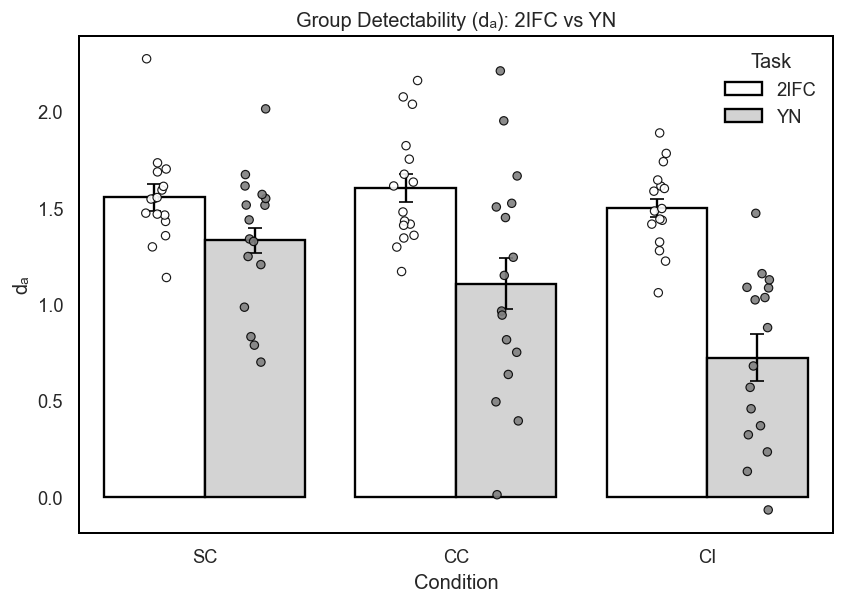

🖼 saved → /Users/w/Desktop/NO NAME/participant_data/new_exp_GROUP_summary/GROUP_YN_HR_FAR.png


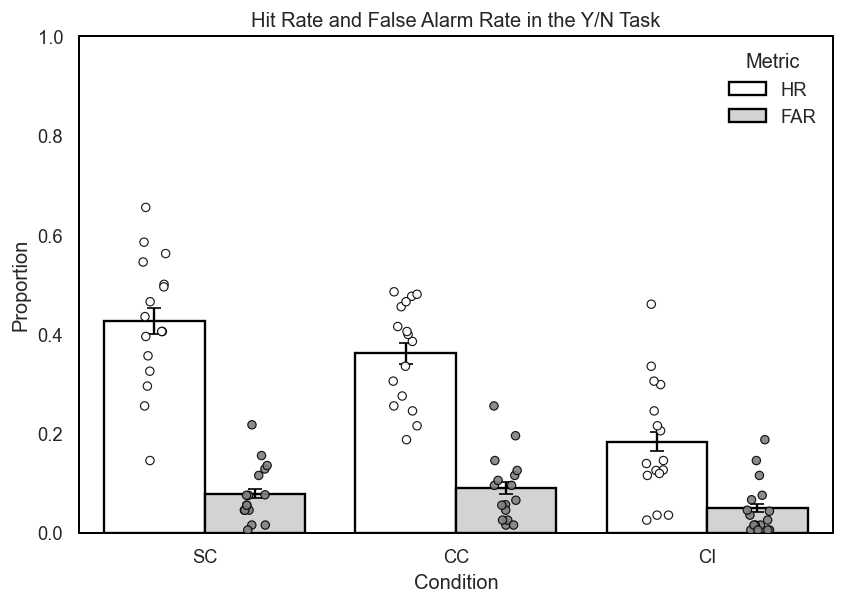

                 HR       FAR
Condition                    
CC         0.361375  0.089438
CI         0.182938  0.050063
SC         0.426438  0.078500
📦 Done. Group outputs saved in: /Users/w/Desktop/NO NAME/participant_data/new_exp_GROUP_summary


In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/new_exp'

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228', '00217', '00210', 
                '00223'
                ]
GROUP_OUT = '/Users/w/Desktop/NO NAME/participant_data/new_exp_GROUP_summary'
os.makedirs(GROUP_OUT, exist_ok=True)

order = ['SC', 'CC', 'CI']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']


def save_fig(fig, fpath, dpi=300):
    fig.savefig(fpath, dpi=dpi, bbox_inches='tight')
    print(f'🖼 saved → {fpath}')


def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def read_csv_with_condition(path, pid):
    if not os.path.exists(path):
        print(f'⚠️ Missing: {path}')
        return None

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_meta(pid, task):
    return read_csv_with_condition(
        os.path.join(summary_dir(pid), f'{pid}_{task}_meta.csv'),
        pid
    )


def load_hrfar(pid):
    return read_csv_with_condition(
        os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv'),
        pid
    )


def within_subject_sem(df, dv, subject_col, within_cols):
    df = df.copy()

    subj_mean = df.groupby(subject_col)[dv].transform('mean')
    grand_mean = df[dv].mean()

    df['_adj'] = df[dv] - subj_mean + grand_mean

    k = df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
    factor = np.sqrt(k / (k - 1)) if k > 1 else 1.0

    out = (
        pd.concat(
            [
                df.groupby(within_cols)[dv].mean(),
                df.groupby(within_cols)['_adj'].sem() * factor
            ],
            axis=1
        )
        .reset_index()
        .rename(columns={dv: 'mean', '_adj': 'wsem'})
    )

    return out


# ============================================================
# 1. dₐ summary 읽기
# ============================================================

da_rows = []

for pid in PARTICIPANTS:
    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in order:
        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            da_rows.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            da_rows.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_det_all = pd.DataFrame(da_rows)

if df_det_all.empty:
    raise RuntimeError('No dₐ data found. Check *_2ifc_meta.csv and *_yn_meta.csv.')

df_det_all['Condition'] = pd.Categorical(df_det_all['Condition'], order, ordered=True)
df_det_all['Task'] = pd.Categorical(df_det_all['Task'], task_order, ordered=True)

det_ws = within_subject_sem(
    df_det_all,
    dv='da',
    subject_col='Subject',
    within_cols=['Condition', 'Task']
)

det_ws['Condition'] = pd.Categorical(det_ws['Condition'], order, ordered=True)
det_ws['Task'] = pd.Categorical(det_ws['Task'], task_order, ordered=True)
det_ws = det_ws.sort_values(['Task', 'Condition'])


# ============================================================
# 2. HR/FAR summary 읽기
# ============================================================

hr_list = []

for pid in PARTICIPANTS:
    df = load_hrfar(pid)
    if df is not None:
        hr_list.append(df)

df_hrfar_all = pd.concat(hr_list, ignore_index=True)

hr_long = pd.melt(
    df_hrfar_all[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='val'
)

hr_long['Condition'] = pd.Categorical(hr_long['Condition'], order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], metric_order, ordered=True)

hr_ws = within_subject_sem(
    hr_long,
    dv='val',
    subject_col='Subject',
    within_cols=['Condition', 'Metric']
)

hr_ws['Condition'] = pd.Categorical(hr_ws['Condition'], order, ordered=True)
hr_ws['Metric'] = pd.Categorical(hr_ws['Metric'], metric_order, ordered=True)
hr_ws = hr_ws.sort_values(['Metric', 'Condition'])


# ============================================================
# 3. dₐ figure
# ============================================================

plt.figure(figsize=(7.2, 5.2))

ax = sns.barplot(
    data=det_ws,
    x='Condition',
    y='mean',
    hue='Task',
    order=order,
    hue_order=task_order,
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.4,
    errorbar=None,
    dodge=True
)

idx = np.arange(len(order))
total_w = 0.8
bar_w = total_w / len(task_order)

for j, task in enumerate(task_order):
    sub = det_ws[det_ws['Task'] == task].set_index('Condition').reindex(order)
    x = idx + (-total_w / 2 + bar_w / 2 + j * bar_w)

    ax.errorbar(
        x,
        sub['mean'].values,
        yerr=sub['wsem'].values,
        fmt='none',
        ecolor='black',
        elinewidth=1.4,
        capsize=4,
        zorder=3
    )

sns.stripplot(
    data=df_det_all,
    x='Condition',
    y='da',
    hue='Task',
    order=order,
    hue_order=task_order,
    dodge=True,
    jitter=True,
    marker='o',
    size=5,
    palette=['white', 'gray'],
    edgecolor='black',
    linewidth=0.7,
    alpha=0.9,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Task', frameon=False)

ax.set(
    title='Group Detectability (dₐ): 2IFC vs YN',
    xlabel='Condition',
    ylabel='dₐ'
)

ax.grid(False)

for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)
    ax.spines[side].set_color('black')

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_detectability_da.png'))
plt.show()


# ============================================================
# 4. HR/FAR figure
# ============================================================

plt.figure(figsize=(7.2, 5.2))

ax = sns.barplot(
    data=hr_ws,
    x='Condition',
    y='mean',
    hue='Metric',
    order=order,
    hue_order=metric_order,
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.4,
    errorbar=None,
    dodge=True
)

idx = np.arange(len(order))
total_w = 0.8
bar_w = total_w / len(metric_order)

for j, metric in enumerate(metric_order):
    sub = hr_ws[hr_ws['Metric'] == metric].set_index('Condition').reindex(order)
    x = idx + (-total_w / 2 + bar_w / 2 + j * bar_w)

    ax.errorbar(
        x,
        sub['mean'].values,
        yerr=sub['wsem'].values,
        fmt='none',
        ecolor='black',
        elinewidth=1.4,
        capsize=4
    )

sns.stripplot(
    data=hr_long,
    x='Condition',
    y='val',
    hue='Metric',
    order=order,
    hue_order=metric_order,
    dodge=True,
    jitter=True,
    marker='o',
    size=5,
    palette=['white', 'gray'],
    edgecolor='black',
    linewidth=0.7,
    alpha=0.9,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Metric', frameon=False)

ax.set(
    title='Hit Rate and False Alarm Rate in the Y/N Task',
    xlabel='Condition',
    ylabel='Proportion'
)

ax.set_ylim(0, 1)
ax.grid(False)

for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)
    ax.spines[side].set_color('black')

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR.png'))
plt.show()


# ============================================================
# 5. CSV 저장
# ============================================================

df_det_all.to_csv(
    os.path.join(GROUP_OUT, 'GROUP_detectability_da_raw_from_summary.csv'),
    index=False
)

det_ws.to_csv(
    os.path.join(GROUP_OUT, 'GROUP_detectability_da_wssem.csv'),
    index=False
)

df_hrfar_all.to_csv(
    os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_raw_from_summary.csv'),
    index=False
)

hr_ws.to_csv(
    os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_wssem.csv'),
    index=False
)

print(df_hrfar_all.groupby('Condition')[['HR', 'FAR']].mean())
print(f'📦 Done. Group outputs saved in: {GROUP_OUT}')

Saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/combined_figure_da_hrfar2.png


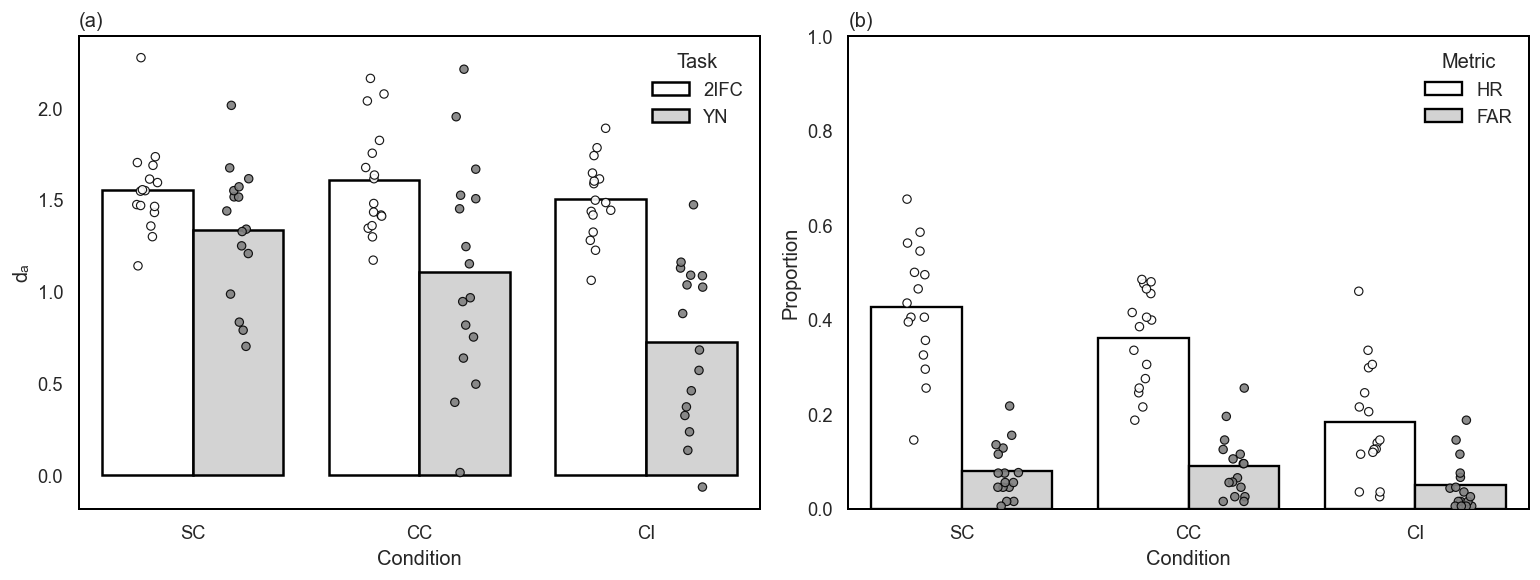

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 경로
# --------------------------------------------------

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228',  '00217', '00210',
                '00223'
                ]
cond_order = ['SC', 'CC', 'CI']

# --------------------------------------------------
# helper
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def load_meta(pid, which):
    f = os.path.join(
        summary_dir(pid),
        f'{pid}_{which}_meta.csv'
    )

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(
        summary_dir(pid),
        f'{pid}_yn_hr_far.csv'
    )

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


# ==================================================
# (a) dₐ 데이터 만들기
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No dₐ data found. Check *_2ifc_meta.csv and *_yn_meta.csv files.')

df_da['Condition'] = pd.Categorical(
    df_da['Condition'],
    categories=cond_order,
    ordered=True
)

summary_da = (
    df_da
    .groupby(['Condition', 'Task'], observed=False)['da']
    .mean()
    .reset_index()
    .rename(columns={'da': 'mean'})
)


# ==================================================
# (b) HR/FAR 데이터 만들기
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:

    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

df_hr = pd.concat(rows_hr, ignore_index=True)

metric_order = ['HR', 'FAR']

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Condition'] = pd.Categorical(
    hr_long['Condition'],
    categories=cond_order,
    ordered=True
)

hr_long['Metric'] = pd.Categorical(
    hr_long['Metric'],
    categories=metric_order,
    ordered=True
)

hr_summary = (
    hr_long
    .groupby(['Condition', 'Metric'], observed=False)['Rate']
    .mean()
    .reset_index()
    .rename(columns={'Rate': 'mean'})
)


# ==================================================
# Figure
# ==================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    dpi=120
)

# ==================================================
# (a)
# ==================================================

ax = axes[0]

sns.barplot(
    data=summary_da,
    x='Condition',
    y='mean',
    hue='Task',
    order=cond_order,
    hue_order=['2IFC', 'YN'],
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.5,
    errorbar=None,
    ax=ax
)

sns.stripplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=['2IFC', 'YN'],
    dodge=True,
    jitter=True,
    marker='o',
    size=5,
    palette=['white', 'gray'],
    edgecolor='black',
    linewidth=0.7,
    alpha=0.9,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Task',
    frameon=False
)

ax.set_title('(a)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.grid(False)


# ==================================================
# (b)
# ==================================================

ax = axes[1]

sns.barplot(
    data=hr_summary,
    x='Condition',
    y='mean',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.4,
    errorbar=None,
    ax=ax
)

sns.stripplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    dodge=True,
    jitter=True,
    marker='o',
    size=5,
    palette=['white', 'gray'],
    edgecolor='black',
    linewidth=0.7,
    alpha=0.9,
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Metric',
    frameon=False
)

ax.set_title('(b)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.grid(False)


# --------------------------------------------------
# 사각형 테두리
# --------------------------------------------------

for ax in axes:
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.2)
        ax.spines[side].set_color('black')


# ==================================================
# 저장
# ==================================================

plt.tight_layout()

out_path = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/combined_figure_da_hrfar2.png'
plt.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

print(f'Saved → {out_path}')

plt.show()

Saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/fig4.png


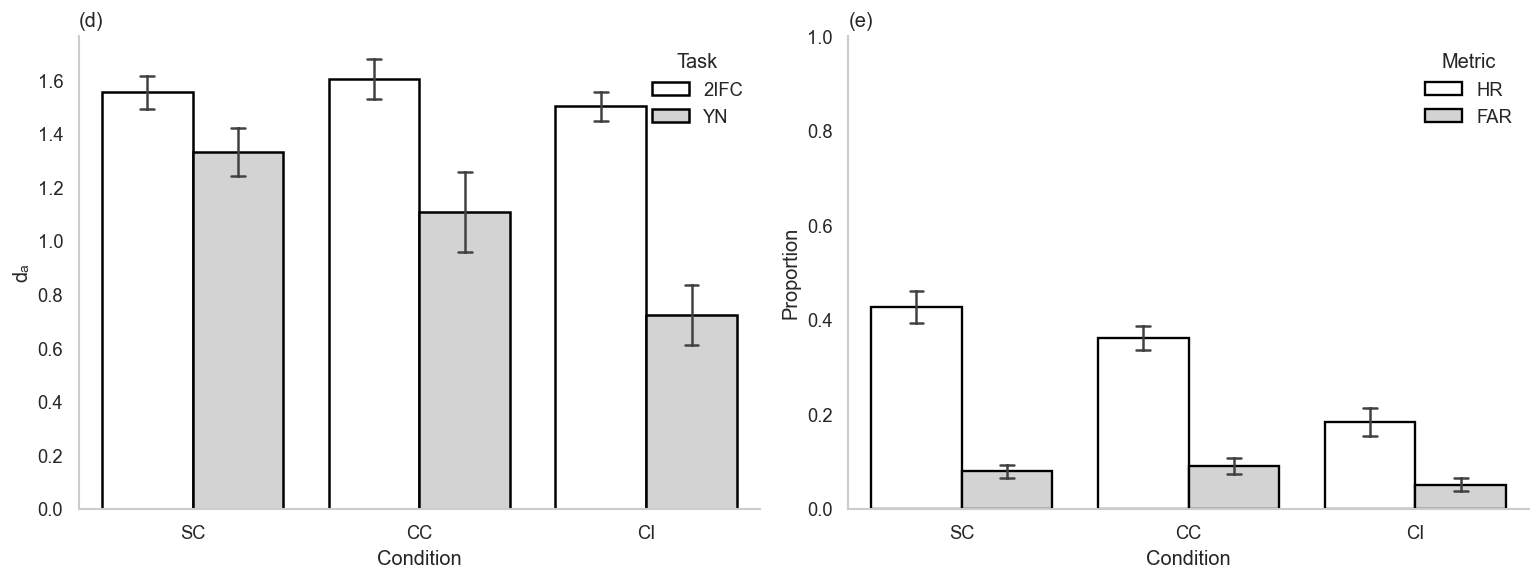

In [81]:
# --------------------------------------------------
# Figure 4. exp 4 (d), (e)
# --------------------------------------------------


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 경로
# --------------------------------------------------

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228',  '00217', '00210',
                '00223'
                ]
cond_order = ['SC', 'CC', 'CI']

# --------------------------------------------------
# helper
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def load_meta(pid, which):
    f = os.path.join(
        summary_dir(pid),
        f'{pid}_{which}_meta.csv'
    )

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(
        summary_dir(pid),
        f'{pid}_yn_hr_far.csv'
    )

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


# ==================================================
# (a) dₐ 데이터 만들기
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No dₐ data found. Check *_2ifc_meta.csv and *_yn_meta.csv files.')

df_da['Condition'] = pd.Categorical(
    df_da['Condition'],
    categories=cond_order,
    ordered=True
)

summary_da = (
    df_da
    .groupby(['Condition', 'Task'], observed=False)['da']
    .mean()
    .reset_index()
    .rename(columns={'da': 'mean'})
)


# ==================================================
# (b) HR/FAR 데이터 만들기
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:

    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

df_hr = pd.concat(rows_hr, ignore_index=True)

metric_order = ['HR', 'FAR']

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Condition'] = pd.Categorical(
    hr_long['Condition'],
    categories=cond_order,
    ordered=True
)

hr_long['Metric'] = pd.Categorical(
    hr_long['Metric'],
    categories=metric_order,
    ordered=True
)

hr_summary = (
    hr_long
    .groupby(['Condition', 'Metric'], observed=False)['Rate']
    .mean()
    .reset_index()
    .rename(columns={'Rate': 'mean'})
)


# ==================================================
# Figure
# ==================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    dpi=120
)

# ==================================================
# (d)
# ==================================================

ax = axes[0]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=['2IFC', 'YN'],
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.5,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth':1.5},
    ax=ax
)


handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Task',
    frameon=False
)

ax.set_title('(d)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.grid(False)


# ==================================================
# (e)
# ==================================================

ax = axes[1]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=['white', 'lightgray'],
    edgecolor='black',
    linewidth=1.4,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth':1.5},
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    labels[:2],
    title='Metric',
    frameon=False
)

ax.set_title('(e)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.grid(False)


# --------------------------------------------------
# 사각형 테두리
# --------------------------------------------------

for ax in axes:
    sns.despine(ax=ax)


# ==================================================
# 저장
# ==================================================

plt.tight_layout()

out_path = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/fig4.png'
plt.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

print(f'Saved → {out_path}')
plt.show()

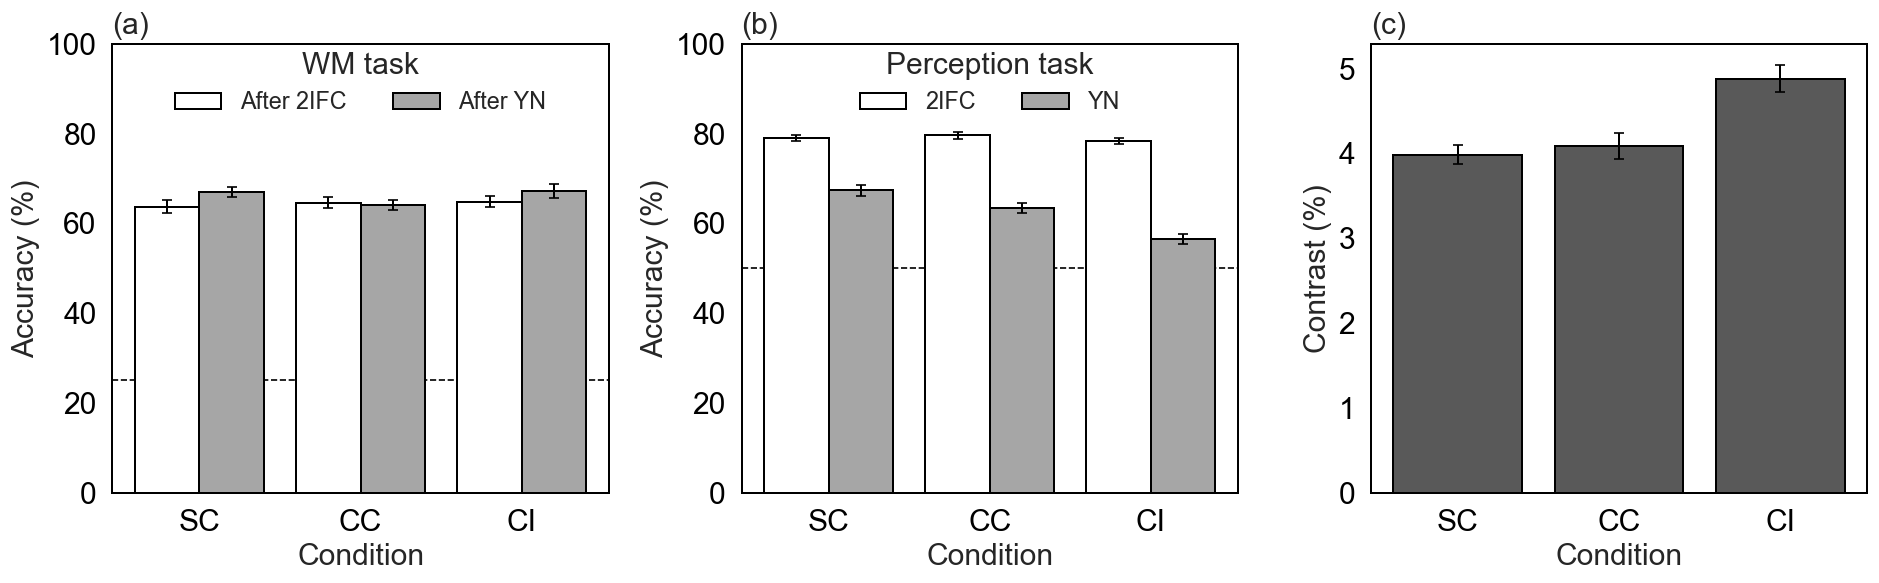

✅ Saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/Figure4.png


(a) WM_probe accuracy
Category       Type   mean  wsem
      SC After 2IFC 63.731 1.392
      SC   After YN 66.957 1.135
      CC After 2IFC 64.609 1.163
      CC   After YN 64.160 1.138
      CI After 2IFC 64.811 1.288
      CI   After YN 67.197 1.586


(b) 2IFC vs YN accuracy
Category Task   mean  wsem
      SC 2IFC 78.965 0.639
      SC   YN 67.342 1.290
      CC 2IFC 79.602 0.756
      CC   YN 63.447 1.172
      CI 2IFC 78.384 0.727
      CI   YN 56.458 1.115


(c) 2IFC staircase contrast
Condition  mean  wsem
       SC 3.982 0.111
       CC 4.083 0.157
       CI 4.879 0.158

✅ Tables saved to: /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary


In [92]:
# ============================================================
# ONE FIGURE (grayscale, no horizontal gridlines)
# (a) WM_probe accuracy (After 2IFC / After YN) + chance line 25%
# (b) 2IFC vs YN accuracy + chance line 50%
# (c) 2IFC staircase contrast
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 경로
# --------------------------------------------------

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228',  '00217', '00210',
                '00223'
                ]
cond_order = ['SC', 'CC', 'CI']

GROUP_OUT = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary'
os.makedirs(GROUP_OUT, exist_ok=True)

# --------------------------------------------------
# style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'legend.title_fontsize': 18
})

sns.set_style("white")
plt.rcParams['figure.dpi'] = 120

# --------------------------------------------------
# helper functions
# --------------------------------------------------

def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def raw_sem_summary(df, dv, group_cols):
    return (
        df.groupby(group_cols)[dv]
        .agg(mean='mean', sem='sem', sd='std', n='count')
        .reset_index()
    )


def within_subject_sem(df, dv, subject_col, within_cols):
    df = df.copy()
    df[dv] = pd.to_numeric(df[dv], errors='coerce')
    df = df.dropna(subset=[dv])

    grand_mean = df[dv].mean()

    subj_means = (
        df.groupby(subject_col)[dv]
        .mean()
        .reset_index()
        .rename(columns={dv: 'subj_mean'})
    )

    df = df.merge(subj_means, on=subject_col)
    df['_adj'] = df[dv] - df['subj_mean'] + grand_mean

    k = df[within_cols].drop_duplicates().shape[0]
    morey_factor = np.sqrt(k / (k - 1)) if k > 1 else 1.0

    out = (
        pd.concat(
            [
                df.groupby(within_cols)[dv].mean(),
                df.groupby(within_cols)['_adj'].sem() * morey_factor
            ],
            axis=1
        )
        .reset_index()
        .rename(columns={dv: 'mean', '_adj': 'wsem'})
    )

    out['mean'] = pd.to_numeric(out['mean'], errors='coerce')
    out['wsem'] = pd.to_numeric(out['wsem'], errors='coerce')

    return out


def _black_axes(ax, xtick_labels=None):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.2)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')

    if xtick_labels is not None:
        ax.set_xticklabels(xtick_labels, rotation=0, ha='center')


# ==================================================
# (A) WM_probe accuracy
# ==================================================

wm_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        print(f'Missing raw files for {pid}')
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for WM in {pid}')
        continue

    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
        else:
            followed_by.append(None)

    df_raw['FollowedBy'] = followed_by

    wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

    if wm.empty:
        print(f'No WM_probe data for {pid}')
        continue

    tmp = (
        wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = tmp['Combined_Correct'] * 100
    tmp['Type'] = tmp['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })
    tmp['Subject'] = pid

    wm_list.append(tmp[['Subject', 'Category', 'Type', 'acc']])


if len(wm_list) == 0:
    raise RuntimeError("WM_probe accuracy를 만들 데이터가 없습니다.")

df_wm_all = pd.concat(wm_list, ignore_index=True)

phase_order = ['After 2IFC', 'After YN']

df_wm_all['Category'] = pd.Categorical(
    df_wm_all['Category'],
    categories=cond_order,
    ordered=True
)

df_wm_all['Type'] = pd.Categorical(
    df_wm_all['Type'],
    categories=phase_order,
    ordered=True
)

wm_ws = within_subject_sem(
    df_wm_all,
    dv='acc',
    subject_col='Subject',
    within_cols=['Category', 'Type']
).sort_values(['Type', 'Category'])


# ==================================================
# (B) 2IFC vs YN accuracy
# ==================================================

acc_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for task accuracy in {pid}')
        continue

    sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby(['Task', 'Category'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = tmp['Combined_Correct'] * 100
    tmp['Subject'] = pid

    acc_list.append(tmp[['Subject', 'Task', 'Category', 'acc']])


if len(acc_list) == 0:
    raise RuntimeError("Task accuracy를 만들 데이터가 없습니다.")

df_task_acc = pd.concat(acc_list, ignore_index=True)

task_order = ['2IFC', 'YN']

df_task_acc['Category'] = pd.Categorical(
    df_task_acc['Category'],
    categories=cond_order,
    ordered=True
)

df_task_acc['Task'] = pd.Categorical(
    df_task_acc['Task'],
    categories=task_order,
    ordered=True
)

task_ws = within_subject_sem(
    df_task_acc,
    dv='acc',
    subject_col='Subject',
    within_cols=['Category', 'Task']
).sort_values(['Task', 'Category'])


# ==================================================
# (C) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={
            'Category': 'Condition',
            'Contrast': 'val'
        })
    )

    tmp['Subject'] = pid
    stair_list.append(tmp)


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)

df_stair['Condition'] = pd.Categorical(
    df_stair['Condition'],
    categories=cond_order,
    ordered=True
)

stair_ws = within_subject_sem(
    df_stair,
    dv='val',
    subject_col='Subject',
    within_cols=['Condition']
).sort_values('Condition')


# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5.2),
    dpi=120
)

phase_palette = ['white', '0.65']
task_palette = ['white', '0.65']
bar_gray = '0.35'

# --------------------------------------------------
# (a) WM_probe accuracy
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=wm_ws,
    x='Category',
    y='mean',
    hue='Type',
    order=cond_order,
    hue_order=phase_order,
    palette=phase_palette,
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    dodge=True,
    ax=ax
)

idx = np.arange(len(cond_order))
total_w = 0.8
bar_w = total_w / len(phase_order)

for j, h in enumerate(phase_order):

    sub = (
        wm_ws[wm_ws['Type'] == h]
        .set_index('Category')
        .reindex(cond_order)
    )

    x = idx + (-total_w / 2 + bar_w / 2 + j * bar_w)

    ax.errorbar(
        x,
        sub['mean'].values,
        yerr=sub['wsem'].values,
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=3,
        zorder=3
    )

ax.axhline(
    25,
    linestyle='--',
    color='black',
    linewidth=1.0,
    zorder=0
)

ax.set_title('(a)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)

_black_axes(ax, xtick_labels=cond_order)

leg = ax.legend(
    title='WM task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    frameon=False,
    ncol=len(phase_order)
)

leg._legend_box.align = "center"
leg.get_title().set_ha('center')


# --------------------------------------------------
# (b) 2IFC vs YN accuracy
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=task_ws,
    x='Category',
    y='mean',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=task_palette,
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    dodge=True,
    ax=ax
)

idx = np.arange(len(cond_order))
total_w = 0.8
bar_w = total_w / len(task_order)

for j, t in enumerate(task_order):

    sub = (
        task_ws[task_ws['Task'] == t]
        .set_index('Category')
        .reindex(cond_order)
    )

    x = idx + (-total_w / 2 + bar_w / 2 + j * bar_w)

    ax.errorbar(
        x,
        sub['mean'].values,
        yerr=sub['wsem'].values,
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=3,
        zorder=3
    )

ax.axhline(
    50,
    linestyle='--',
    color='black',
    linewidth=1.0,
    zorder=0
)

ax.set_title('(b)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)

_black_axes(ax, xtick_labels=cond_order)

leg = ax.legend(
    title='Perception task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    frameon=False,
    ncol=len(task_order)
)

leg._legend_box.align = "center"
leg.get_title().set_ha('center')


# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

stair_ws_pct = stair_ws.copy()
stair_ws_pct['mean'] = stair_ws_pct['mean'] * 100
stair_ws_pct['wsem'] = stair_ws_pct['wsem'] * 100

sns.barplot(
    data=stair_ws_pct,
    x='Condition',
    y='mean',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    ax=ax
)

x = np.arange(len(cond_order))

sub = (
    stair_ws_pct
    .set_index('Condition')
    .reindex(cond_order)
)

ax.errorbar(
    x,
    sub['mean'].values,
    yerr=sub['wsem'].values,
    fmt='none',
    ecolor='black',
    elinewidth=1.2,
    capsize=3,
    zorder=3
)

ax.set_title('(c)', loc='left')
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')

_black_axes(ax, xtick_labels=cond_order)


# ==================================================
# save
# ==================================================

plt.tight_layout()

out_path = os.path.join(
    GROUP_OUT,
    'Figure4.png'
)

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('✅ Saved →', out_path)

# ==================================================
# Final output tables
# ==================================================
print("\n\n==============================")
print("(a) WM_probe accuracy")
print("==============================")

table_a = (
    wm_ws
    .copy()
    .sort_values(['Category', 'Type'])
)
table_a['mean'] = pd.to_numeric(table_a['mean'], errors='coerce').round(3)
table_a['wsem'] = pd.to_numeric(table_a['wsem'], errors='coerce').round(3)

print(table_a.to_string(index=False))

print("\n\n==============================")
print("(b) 2IFC vs YN accuracy")
print("==============================")

table_b = (
    task_ws
    .copy()
    .sort_values(['Category', 'Task'])
)

table_b['mean'] = pd.to_numeric(table_b['mean'], errors='coerce').round(3)
table_b['wsem'] = pd.to_numeric(table_b['wsem'], errors='coerce').round(3)

print(table_b.to_string(index=False))


print("\n\n==============================")
print("(c) 2IFC staircase contrast")
print("==============================")

table_c = (
    stair_ws_pct
    .copy()
    .sort_values('Condition')
)

table_c['mean'] = pd.to_numeric(table_c['mean'], errors='coerce').round(3)
table_c['wsem'] = pd.to_numeric(table_c['wsem'], errors='coerce').round(3)

print(table_c.to_string(index=False))
table_a.to_csv(os.path.join(GROUP_OUT, 'Figure4a_WM_accuracy_table.csv'), index=False)
table_b.to_csv(os.path.join(GROUP_OUT, 'Figure4b_task_accuracy_table.csv'), index=False)
table_c.to_csv(os.path.join(GROUP_OUT, 'Figure4c_staircase_contrast_table.csv'), index=False)

print("\n✅ Tables saved to:", GROUP_OUT)

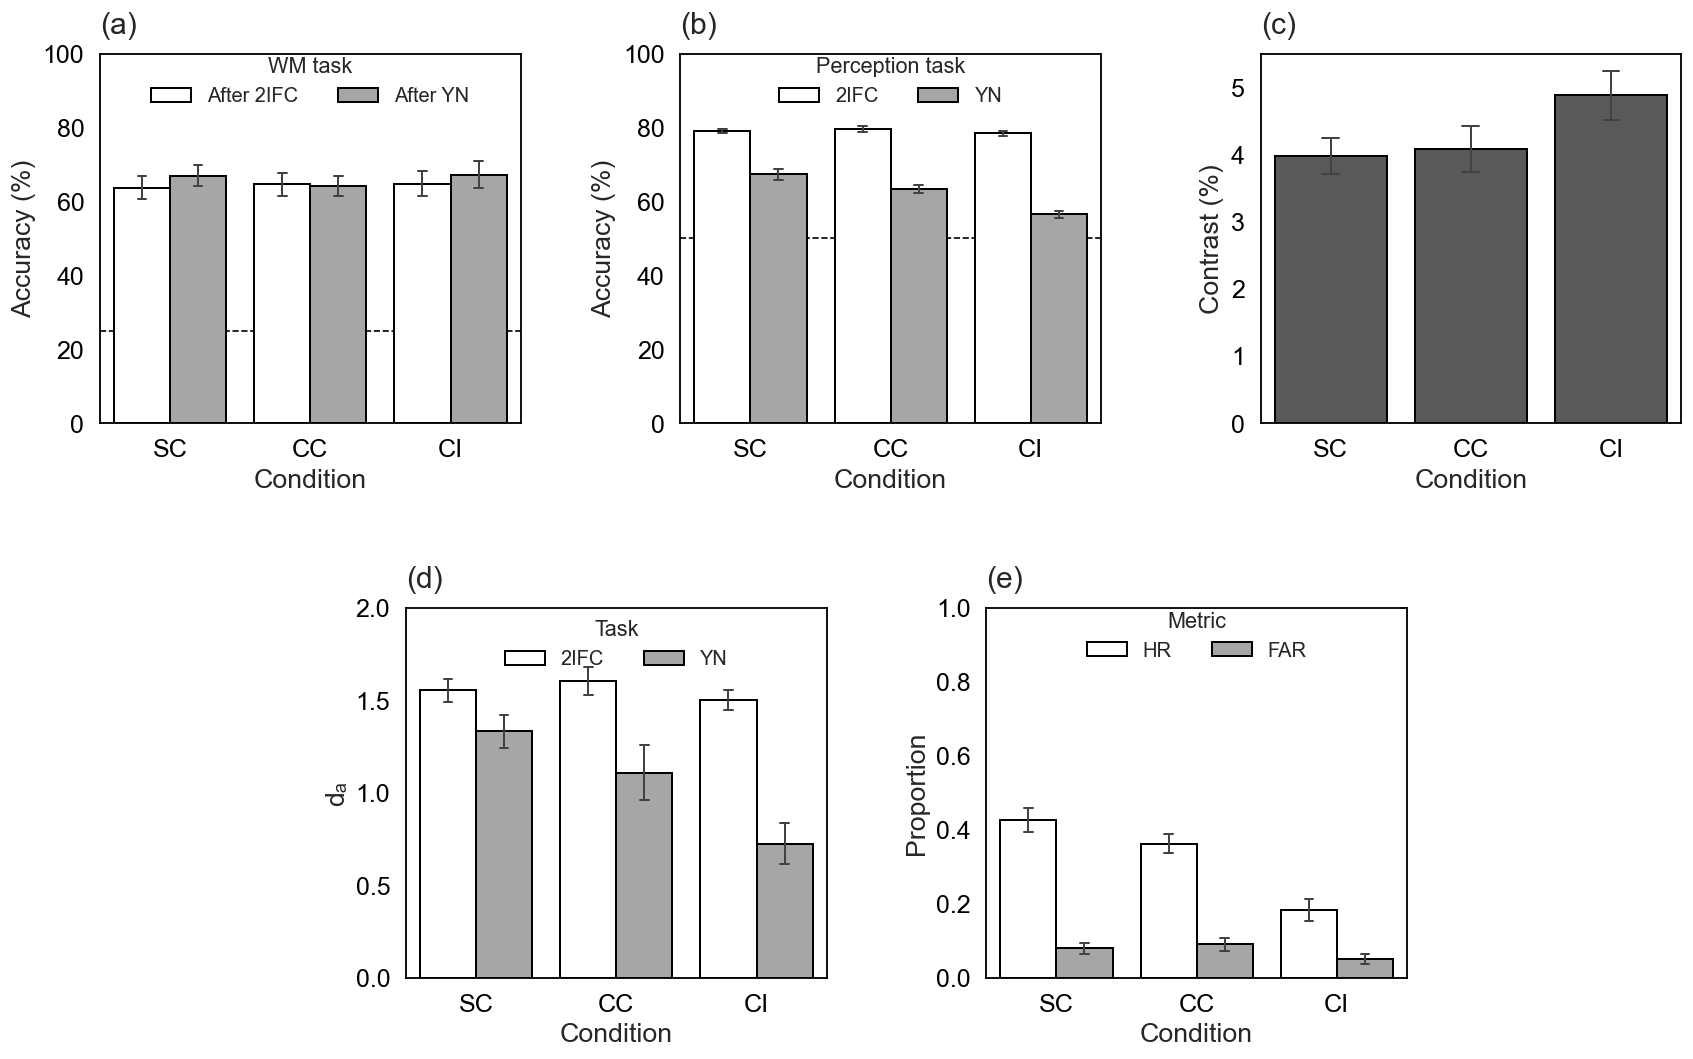

Saved → /Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)/new_exp_GROUP_summary/Figure4_abcde_ordinarySEM.png


In [140]:
# ============================================================
# Figure 4. Exp 4 group summary: panels (a)–(e)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp4 (n=16)'
GROUP_OUT = os.path.join(BASE_DIR, 'new_exp_GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228', '00217', '00210',
                '00223']

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) WM probe accuracy
# ==================================================

wm_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        print(f'Missing raw files for {pid}')
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw = df_raw.reset_index(drop=True)

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for WM in {pid}')
        continue

    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
        else:
            followed_by.append(None)

    df_raw['FollowedBy'] = followed_by

    wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

    if wm.empty:
        print(f'No WM_probe data for {pid}')
        continue

    tmp = (
        wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Type'] = tmp['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })
    tmp['Subject'] = pid

    wm_list.append(tmp[['Subject', 'Category', 'Type', 'acc']])


if len(wm_list) == 0:
    raise RuntimeError("WM_probe accuracy를 만들 데이터가 없습니다.")

df_wm_all = pd.concat(wm_list, ignore_index=True)

df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], categories=cond_order, ordered=True)
df_wm_all['Type'] = pd.Categorical(df_wm_all['Type'], categories=phase_order, ordered=True)


# ==================================================
# (b) 2IFC vs YN accuracy
# ==================================================

acc_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for task accuracy in {pid}')
        continue

    sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby(['Task', 'Category'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Subject'] = pid

    acc_list.append(tmp[['Subject', 'Task', 'Category', 'acc']])


if len(acc_list) == 0:
    raise RuntimeError("Task accuracy를 만들 데이터가 없습니다.")

df_task_acc = pd.concat(acc_list, ignore_index=True)

df_task_acc['Category'] = pd.Categorical(df_task_acc['Category'], categories=cond_order, ordered=True)
df_task_acc['Task'] = pd.Categorical(df_task_acc['Task'], categories=task_order, ordered=True)


# ==================================================
# (c) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={'Category': 'Condition', 'Contrast': 'contrast'})
    )

    tmp['contrast'] = pd.to_numeric(tmp['contrast'], errors='coerce') * 100
    tmp['Subject'] = pid

    stair_list.append(tmp[['Subject', 'Condition', 'contrast']])


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)
df_stair['Condition'] = pd.Categorical(df_stair['Condition'], categories=cond_order, ordered=True)


# ==================================================
# (d) d_a
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No d_a data found.')

df_da['da'] = pd.to_numeric(df_da['da'], errors='coerce')
df_da['Condition'] = pd.Categorical(df_da['Condition'], categories=cond_order, ordered=True)
df_da['Task'] = pd.Categorical(df_da['Task'], categories=task_order, ordered=True)


# ==================================================
# (e) HR / FAR
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:
    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

if len(rows_hr) == 0:
    raise RuntimeError('No HR/FAR data found.')

df_hr = pd.concat(rows_hr, ignore_index=True)

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Rate'] = pd.to_numeric(hr_long['Rate'], errors='coerce')
hr_long['Condition'] = pd.Categorical(hr_long['Condition'], categories=cond_order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], categories=metric_order, ordered=True)


# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
    fig.add_subplot(gs[0, 2]),  # c
    fig.add_subplot(gs[1, 0]),  # d
    fig.add_subplot(gs[1, 1])   # e
]

palette_two = ['white', '0.65']
bar_gray = '0.35'

# --------------------------------------------------
# (a) WM probe accuracy
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_wm_all,
    x='Category',
    y='acc',
    hue='Type',
    order=cond_order,
    hue_order=phase_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(a)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='WM task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (b) 2IFC vs YN accuracy
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=df_task_acc,
    x='Category',
    y='acc',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(b)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='Perception task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_stair,
    x='Condition',
    y='contrast',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(c)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')
format_axes(ax)

# --------------------------------------------------
# (d) d_a
# --------------------------------------------------

ax = axes[3]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(d)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.set_ylim(0, 2.0)
format_axes(ax)

ax.legend(
    title='Task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    frameon=False,
    ncol=2,
    borderaxespad=0.2
)

# --------------------------------------------------
# (e) HR / FAR
# --------------------------------------------------

ax = axes[4]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(e)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
format_axes(ax)

ax.legend(
    title='Metric',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# d/e panel 중앙 정렬용 이동
# --------------------------------------------------
shift = 0.15
for ax in [axes[3], axes[4]]:
    pos = ax.get_position()

    ax.set_position([
        pos.x0 + shift,
        pos.y0,
        pos.width,
        pos.height
    ])

# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'Figure4_abcde_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')

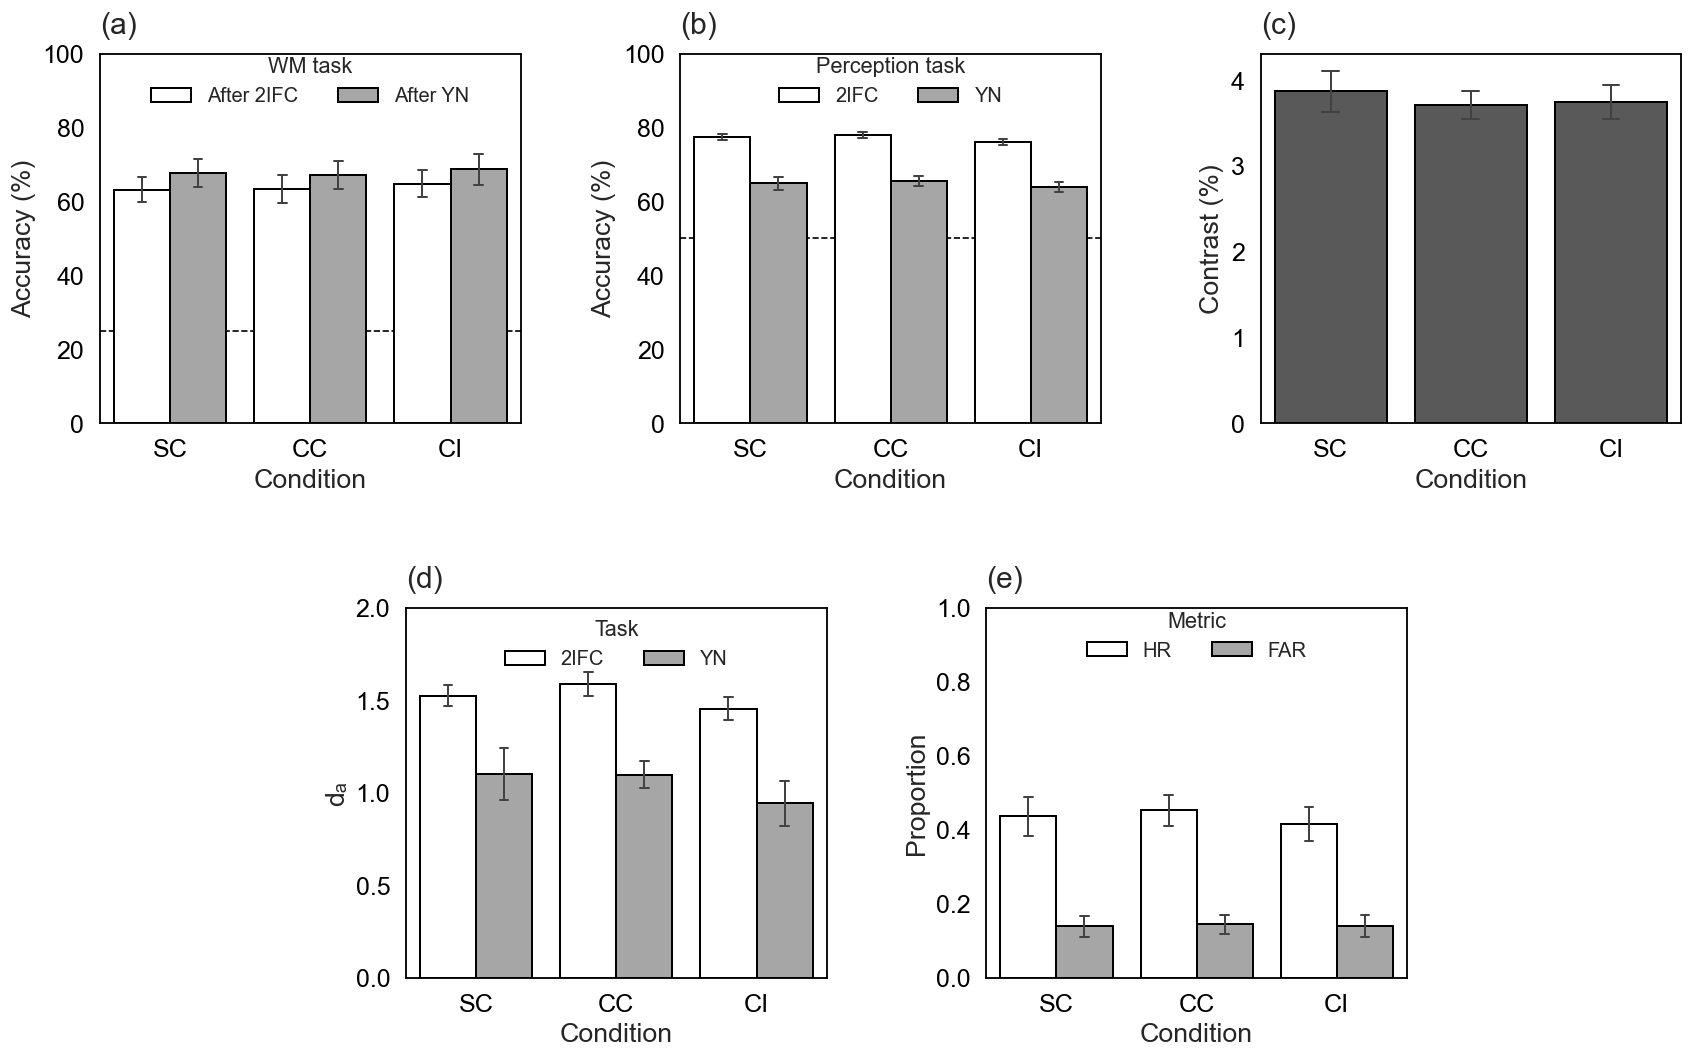

Saved → /Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)/GROUP_summary/Figure3_abcde_ordinarySEM.png


In [147]:
# ============================================================
# Figure 3. Exp 2 group summary: panels (a)–(e)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00024', '00030', '00074', '00081', 
                '000087', '00089', '00091', '00093', 
                '00094', '00096', '00097', '00098',
                '00099', '00100', '00102', '00105']


cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) WM probe accuracy
# ==================================================

wm_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        print(f'Missing raw files for {pid}')
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw = df_raw.reset_index(drop=True)

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for WM in {pid}')
        continue

    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
        else:
            followed_by.append(None)

    df_raw['FollowedBy'] = followed_by

    wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

    if wm.empty:
        print(f'No WM_probe data for {pid}')
        continue

    tmp = (
        wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Type'] = tmp['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })
    tmp['Subject'] = pid

    wm_list.append(tmp[['Subject', 'Category', 'Type', 'acc']])


if len(wm_list) == 0:
    raise RuntimeError("WM_probe accuracy를 만들 데이터가 없습니다.")

df_wm_all = pd.concat(wm_list, ignore_index=True)

df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], categories=cond_order, ordered=True)
df_wm_all['Type'] = pd.Categorical(df_wm_all['Type'], categories=phase_order, ordered=True)


# ==================================================
# (b) 2IFC vs YN accuracy
# ==================================================

acc_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for task accuracy in {pid}')
        continue

    sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby(['Task', 'Category'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Subject'] = pid

    acc_list.append(tmp[['Subject', 'Task', 'Category', 'acc']])


if len(acc_list) == 0:
    raise RuntimeError("Task accuracy를 만들 데이터가 없습니다.")

df_task_acc = pd.concat(acc_list, ignore_index=True)

df_task_acc['Category'] = pd.Categorical(df_task_acc['Category'], categories=cond_order, ordered=True)
df_task_acc['Task'] = pd.Categorical(df_task_acc['Task'], categories=task_order, ordered=True)


# ==================================================
# (c) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={'Category': 'Condition', 'Contrast': 'contrast'})
    )

    tmp['contrast'] = pd.to_numeric(tmp['contrast'], errors='coerce') * 100
    tmp['Subject'] = pid

    stair_list.append(tmp[['Subject', 'Condition', 'contrast']])


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)
df_stair['Condition'] = pd.Categorical(df_stair['Condition'], categories=cond_order, ordered=True)


# ==================================================
# (d) d_a
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No d_a data found.')

df_da['da'] = pd.to_numeric(df_da['da'], errors='coerce')
df_da['Condition'] = pd.Categorical(df_da['Condition'], categories=cond_order, ordered=True)
df_da['Task'] = pd.Categorical(df_da['Task'], categories=task_order, ordered=True)


# ==================================================
# (e) HR / FAR
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:
    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

if len(rows_hr) == 0:
    raise RuntimeError('No HR/FAR data found.')

df_hr = pd.concat(rows_hr, ignore_index=True)

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Rate'] = pd.to_numeric(hr_long['Rate'], errors='coerce')
hr_long['Condition'] = pd.Categorical(hr_long['Condition'], categories=cond_order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], categories=metric_order, ordered=True)


# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
    fig.add_subplot(gs[0, 2]),  # c
    fig.add_subplot(gs[1, 0]),  # d
    fig.add_subplot(gs[1, 1])   # e
]

palette_two = ['white', '0.65']
bar_gray = '0.35'

# --------------------------------------------------
# (a) WM probe accuracy
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_wm_all,
    x='Category',
    y='acc',
    hue='Type',
    order=cond_order,
    hue_order=phase_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(a)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='WM task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (b) 2IFC vs YN accuracy
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=df_task_acc,
    x='Category',
    y='acc',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(b)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='Perception task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_stair,
    x='Condition',
    y='contrast',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(c)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')
format_axes(ax)

# --------------------------------------------------
# (d) d_a
# --------------------------------------------------

ax = axes[3]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(d)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.set_ylim(0, 2.0)
format_axes(ax)

ax.legend(
    title='Task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    frameon=False,
    ncol=2,
    borderaxespad=0.2
)

# --------------------------------------------------
# (e) HR / FAR
# --------------------------------------------------

ax = axes[4]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(e)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
format_axes(ax)

ax.legend(
    title='Metric',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# d/e panel 중앙 정렬용 이동
# --------------------------------------------------
shift = 0.15
for ax in [axes[3], axes[4]]:
    pos = ax.get_position()

    ax.set_position([
        pos.x0 + shift,
        pos.y0,
        pos.width,
        pos.height
    ])

# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'Figure3_abcde_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')


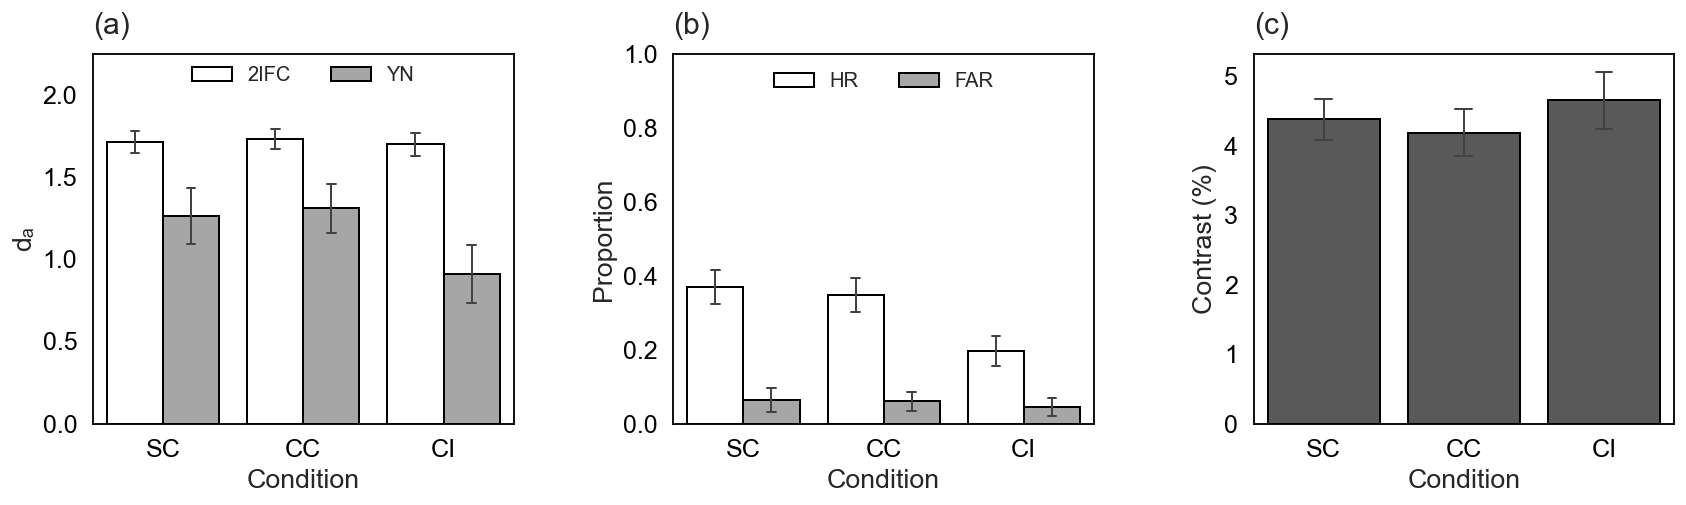

Saved → /Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)/GROUP_summary/Figure2_abcde_ordinarySEM.png


In [344]:
# ============================================================
# Figure 2. Exp 1 group summary: panels (a)–(e)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00003', '00038', '00051', '00052', 
                '00054', '00060', '00061', '00068', 
                '00071', '00130', '00161', '00162',
                '00193', '00200', '00201', '00202',
                ]


cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) d_a
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No d_a data found.')

df_da['da'] = pd.to_numeric(df_da['da'], errors='coerce')
df_da['Condition'] = pd.Categorical(df_da['Condition'], categories=cond_order, ordered=True)
df_da['Task'] = pd.Categorical(df_da['Task'], categories=task_order, ordered=True)

# ==================================================
# (b) HR / FAR
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:
    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

if len(rows_hr) == 0:
    raise RuntimeError('No HR/FAR data found.')

df_hr = pd.concat(rows_hr, ignore_index=True)

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Rate'] = pd.to_numeric(hr_long['Rate'], errors='coerce')
hr_long['Condition'] = pd.Categorical(hr_long['Condition'], categories=cond_order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], categories=metric_order, ordered=True)

# ==================================================
# (c) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={'Category': 'Condition', 'Contrast': 'contrast'})
    )

    tmp['contrast'] = pd.to_numeric(tmp['contrast'], errors='coerce') * 100
    tmp['Subject'] = pid

    stair_list.append(tmp[['Subject', 'Condition', 'contrast']])


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)
df_stair['Condition'] = pd.Categorical(df_stair['Condition'], categories=cond_order, ordered=True)


# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
    fig.add_subplot(gs[0, 2]),  # c
]

palette_two = ['white', '0.65']
bar_gray = '0.35'


# --------------------------------------------------
# (a) d_a
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(a)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.set_ylim(0, 2.25)   # 위쪽 공간 추가
format_axes(ax)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),   # 다시 안쪽으로
    frameon=False,
    ncol=2,
    borderaxespad=0.2
)

plt.tight_layout(rect=[0, 0, 1, 0.95]),
# --------------------------------------------------
# (b) HR / FAR
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(b)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
format_axes(ax)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_stair,
    x='Condition',
    y='contrast',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(c)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')
format_axes(ax)


# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'Figure2_abcde_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')


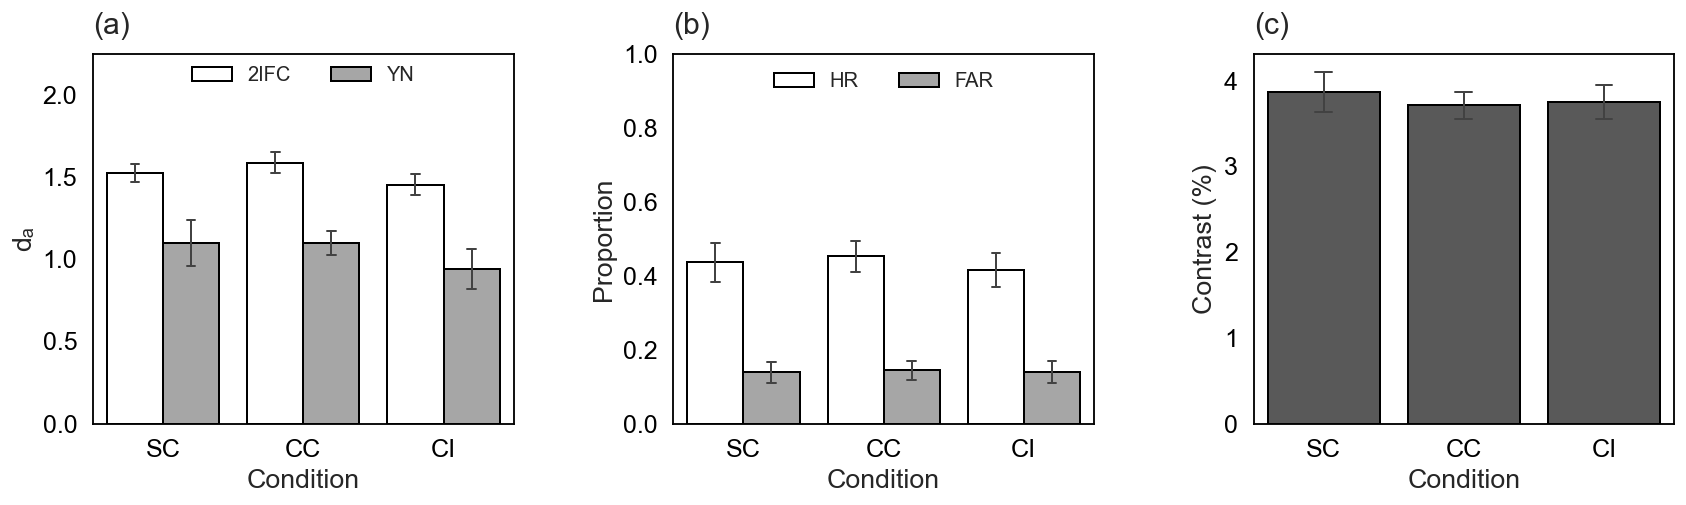

Saved → /Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)/GROUP_summary/Figure3_abc_ordinarySEM.png


In [342]:
# ============================================================
# Figure 3. Exp 2 group summary: panels (a)–(c)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00024', '00030', '00074', '00081', 
                '000087', '00089', '00091', '00093', 
                '00094', '00096', '00097', '00098',
                '00099', '00100', '00102', '00105']

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) d_a
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No d_a data found.')

df_da['da'] = pd.to_numeric(df_da['da'], errors='coerce')
df_da['Condition'] = pd.Categorical(df_da['Condition'], categories=cond_order, ordered=True)
df_da['Task'] = pd.Categorical(df_da['Task'], categories=task_order, ordered=True)

# ==================================================
# (b) HR / FAR
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:
    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

if len(rows_hr) == 0:
    raise RuntimeError('No HR/FAR data found.')

df_hr = pd.concat(rows_hr, ignore_index=True)

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Rate'] = pd.to_numeric(hr_long['Rate'], errors='coerce')
hr_long['Condition'] = pd.Categorical(hr_long['Condition'], categories=cond_order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], categories=metric_order, ordered=True)

# ==================================================
# (c) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={'Category': 'Condition', 'Contrast': 'contrast'})
    )

    tmp['contrast'] = pd.to_numeric(tmp['contrast'], errors='coerce') * 100
    tmp['Subject'] = pid

    stair_list.append(tmp[['Subject', 'Condition', 'contrast']])


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)
df_stair['Condition'] = pd.Categorical(df_stair['Condition'], categories=cond_order, ordered=True)


# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
    fig.add_subplot(gs[0, 2]),  # c
]

palette_two = ['white', '0.65']
bar_gray = '0.35'


# --------------------------------------------------
# (a) d_a
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(a)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.set_ylim(0, 2.25)   # 위쪽 공간 추가
format_axes(ax)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),   # 다시 안쪽으로
    frameon=False,
    ncol=2,
    borderaxespad=0.2
)

plt.tight_layout(rect=[0, 0, 1, 0.95]),
# --------------------------------------------------
# (b) HR / FAR
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(b)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
format_axes(ax)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_stair,
    x='Condition',
    y='contrast',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(c)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')
format_axes(ax)


# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'Figure3_abc_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')


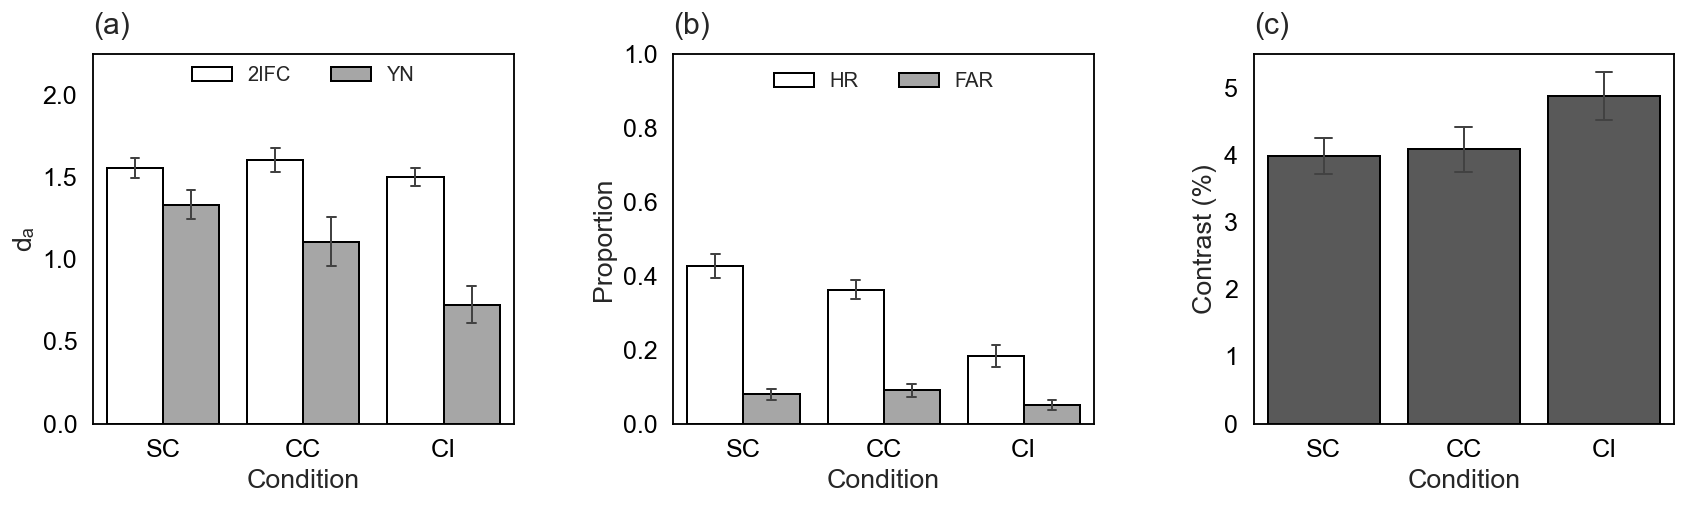

Saved → /Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/GROUP_summary/Figure4_abc_ordinarySEM.png


In [340]:
# ============================================================
# Figure 4. Exp 3 group summary: panels (a)–(c)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)


PARTICIPANTS = ['00139', '00173', '00212', '00216', '00218',
                '00219', '00220', '00222', '00224', '00225',
                '00226', '00227', '00228', '00217', '00210',
                '00223']
cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) d_a
# ==================================================

rows_da = []

for pid in PARTICIPANTS:

    df2 = load_meta(pid, '2ifc')
    dfy = load_meta(pid, 'yn')

    if df2 is None or dfy is None:
        continue

    for cond in cond_order:

        da2 = df2.loc[df2['Condition'] == cond, 'da'].values
        day = dfy.loc[dfy['Condition'] == cond, 'da'].values

        if len(da2) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': '2IFC',
                'da': float(da2[0])
            })

        if len(day) > 0:
            rows_da.append({
                'Subject': pid,
                'Condition': cond,
                'Task': 'YN',
                'da': float(day[0])
            })

df_da = pd.DataFrame(rows_da)

if df_da.empty:
    raise RuntimeError('No d_a data found.')

df_da['da'] = pd.to_numeric(df_da['da'], errors='coerce')
df_da['Condition'] = pd.Categorical(df_da['Condition'], categories=cond_order, ordered=True)
df_da['Task'] = pd.Categorical(df_da['Task'], categories=task_order, ordered=True)

# ==================================================
# (b) HR / FAR
# ==================================================

rows_hr = []

for pid in PARTICIPANTS:
    df_tmp = load_hrfar(pid)

    if df_tmp is not None:
        rows_hr.append(df_tmp)

if len(rows_hr) == 0:
    raise RuntimeError('No HR/FAR data found.')

df_hr = pd.concat(rows_hr, ignore_index=True)

hr_long = pd.melt(
    df_hr[['Subject', 'Condition', 'HR', 'FAR']],
    id_vars=['Subject', 'Condition'],
    value_vars=['HR', 'FAR'],
    var_name='Metric',
    value_name='Rate'
)

hr_long['Rate'] = pd.to_numeric(hr_long['Rate'], errors='coerce')
hr_long['Condition'] = pd.Categorical(hr_long['Condition'], categories=cond_order, ordered=True)
hr_long['Metric'] = pd.Categorical(hr_long['Metric'], categories=metric_order, ordered=True)

# ==================================================
# (c) 2IFC staircase contrast
# ==================================================

stair_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Contrast'}.issubset(df_raw.columns):
        print(f'Missing required columns for staircase in {pid}')
        continue

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby('Category')['Contrast']
        .mean()
        .reset_index()
        .rename(columns={'Category': 'Condition', 'Contrast': 'contrast'})
    )

    tmp['contrast'] = pd.to_numeric(tmp['contrast'], errors='coerce') * 100
    tmp['Subject'] = pid

    stair_list.append(tmp[['Subject', 'Condition', 'contrast']])


if len(stair_list) == 0:
    raise RuntimeError("Staircase contrast를 만들 데이터가 없습니다.")

df_stair = pd.concat(stair_list, ignore_index=True)
df_stair['Condition'] = pd.Categorical(df_stair['Condition'], categories=cond_order, ordered=True)


# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
    fig.add_subplot(gs[0, 2]),  # c
]

palette_two = ['white', '0.65']
bar_gray = '0.35'


# --------------------------------------------------
# (a) d_a
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_da,
    x='Condition',
    y='da',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(a)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('dₐ')
ax.set_ylim(0, 2.25)   # 위쪽 공간 추가
format_axes(ax)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),   # 다시 안쪽으로
    frameon=False,
    ncol=2,
    borderaxespad=0.2
)

plt.tight_layout(rect=[0, 0, 1, 0.95]),
# --------------------------------------------------
# (b) HR / FAR
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=hr_long,
    x='Condition',
    y='Rate',
    hue='Metric',
    order=cond_order,
    hue_order=metric_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(b)', loc='left', pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
format_axes(ax)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.00),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# (c) Staircase contrast
# --------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_stair,
    x='Condition',
    y='contrast',
    order=cond_order,
    color=bar_gray,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.set_title('(c)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Contrast (%)')
format_axes(ax)


# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'Figure4_abc_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')


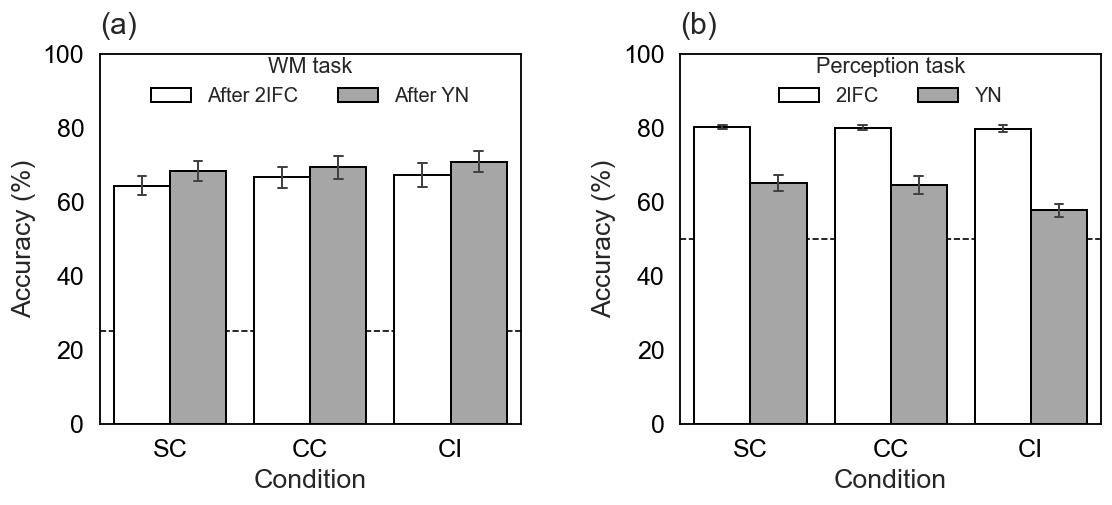

Saved → /Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)/GROUP_summary/SuppFigure1_ab_ordinarySEM.png


In [198]:
# ============================================================
# Supplementary Figure1. 따로 만든 Exp 1 group summary: panels (a)–(b)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00003', '00038', '00051', '00052', 
                '00054', '00060', '00061', '00068', 
                '00071', '00130', '00161', '00162',
                '00193', '00200', '00201', '00202',
                ]


cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) WM probe accuracy
# ==================================================

wm_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        print(f'Missing raw files for {pid}')
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw = df_raw.reset_index(drop=True)

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for WM in {pid}')
        continue

    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
        else:
            followed_by.append(None)

    df_raw['FollowedBy'] = followed_by

    wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

    if wm.empty:
        print(f'No WM_probe data for {pid}')
        continue

    tmp = (
        wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Type'] = tmp['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })
    tmp['Subject'] = pid

    wm_list.append(tmp[['Subject', 'Category', 'Type', 'acc']])


if len(wm_list) == 0:
    raise RuntimeError("WM_probe accuracy를 만들 데이터가 없습니다.")

df_wm_all = pd.concat(wm_list, ignore_index=True)

df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], categories=cond_order, ordered=True)
df_wm_all['Type'] = pd.Categorical(df_wm_all['Type'], categories=phase_order, ordered=True)


# ==================================================
# (b) 2IFC vs YN accuracy
# ==================================================

acc_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for task accuracy in {pid}')
        continue

    sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby(['Task', 'Category'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Subject'] = pid

    acc_list.append(tmp[['Subject', 'Task', 'Category', 'acc']])


if len(acc_list) == 0:
    raise RuntimeError("Task accuracy를 만들 데이터가 없습니다.")

df_task_acc = pd.concat(acc_list, ignore_index=True)

df_task_acc['Category'] = pd.Categorical(df_task_acc['Category'], categories=cond_order, ordered=True)
df_task_acc['Task'] = pd.Categorical(df_task_acc['Task'], categories=task_order, ordered=True)

# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
]

palette_two = ['white', '0.65']
bar_gray = '0.35'


# --------------------------------------------------
# (a) WM probe accuracy
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_wm_all,
    x='Category',
    y='acc',
    hue='Type',
    order=cond_order,
    hue_order=phase_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(a)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='WM task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# Supplementary (b) 2IFC vs YN accuracy
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=df_task_acc,
    x='Category',
    y='acc',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(b)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='Perception task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'SuppFigure1_ab_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')

# ============================================================
# Supplementary Figure1. Exp 2 group summary: panels (a)–(b)
# ordinary SEM, no participant markers, outer figure border
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Path
# --------------------------------------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)'
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = ['00003', '00038', '00051', '00052', 
                '00054', '00060', '00061', '00068', 
                '00071', '00130', '00161', '00162',
                '00193', '00200', '00201', '00202',
                ]

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']
metric_order = ['HR', 'FAR']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

sns.set_style("white")

# --------------------------------------------------
# Helpers
# --------------------------------------------------

def summary_dir(pid):
    return os.path.join(BASE_DIR, pid, 'summary')


def find_raw_files(pid):
    pattern = os.path.join(
        BASE_DIR,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_meta(pid, which):
    f = os.path.join(summary_dir(pid), f'{pid}_{which}_meta.csv')

    if not os.path.exists(f):
        print(f'Missing meta file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def load_hrfar(pid):
    f = os.path.join(summary_dir(pid), f'{pid}_yn_hr_far.csv')

    if not os.path.exists(f):
        print(f'Missing HR/FAR file: {f}')
        return None

    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    if 'Condition' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Condition'})

    df['Subject'] = pid
    return df


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


# ==================================================
# (a) WM probe accuracy
# ==================================================

wm_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        print(f'Missing raw files for {pid}')
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    df_raw = df_raw.reset_index(drop=True)

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for WM in {pid}')
        continue

    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
        else:
            followed_by.append(None)

    df_raw['FollowedBy'] = followed_by

    wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

    if wm.empty:
        print(f'No WM_probe data for {pid}')
        continue

    tmp = (
        wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Type'] = tmp['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })
    tmp['Subject'] = pid

    wm_list.append(tmp[['Subject', 'Category', 'Type', 'acc']])


if len(wm_list) == 0:
    raise RuntimeError("WM_probe accuracy를 만들 데이터가 없습니다.")

df_wm_all = pd.concat(wm_list, ignore_index=True)

df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], categories=cond_order, ordered=True)
df_wm_all['Type'] = pd.Categorical(df_wm_all['Type'], categories=phase_order, ordered=True)


# ==================================================
# (b) 2IFC vs YN accuracy
# ==================================================

acc_list = []

for pid in PARTICIPANTS:

    paths = find_raw_files(pid)

    if not paths:
        continue

    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()

    if not {'Task', 'Category', 'Combined_Correct'}.issubset(df_raw.columns):
        print(f'Missing required columns for task accuracy in {pid}')
        continue

    sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

    if sub.empty:
        continue

    tmp = (
        sub.groupby(['Task', 'Category'])['Combined_Correct']
        .mean()
        .reset_index()
    )

    tmp['acc'] = pd.to_numeric(tmp['Combined_Correct'], errors='coerce') * 100
    tmp['Subject'] = pid

    acc_list.append(tmp[['Subject', 'Task', 'Category', 'acc']])


if len(acc_list) == 0:
    raise RuntimeError("Task accuracy를 만들 데이터가 없습니다.")

df_task_acc = pd.concat(acc_list, ignore_index=True)

df_task_acc['Category'] = pd.Categorical(df_task_acc['Category'], categories=cond_order, ordered=True)
df_task_acc['Task'] = pd.Categorical(df_task_acc['Task'], categories=task_order, ordered=True)

# ==================================================
# Plot
# ==================================================

fig = plt.figure(figsize=(17, 10), dpi=120)

gs = fig.add_gridspec(
    2, 3,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1],
    wspace=0.38,
    hspace=0.50
)

axes = [
    fig.add_subplot(gs[0, 0]),  # a
    fig.add_subplot(gs[0, 1]),  # b
]

palette_two = ['white', '0.65']
bar_gray = '0.35'


# --------------------------------------------------
# (a) WM probe accuracy
# --------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_wm_all,
    x='Category',
    y='acc',
    hue='Type',
    order=cond_order,
    hue_order=phase_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(a)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='WM task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# Supplementary (b) 2IFC vs YN accuracy
# --------------------------------------------------

ax = axes[1]

sns.barplot(
    data=df_task_acc,
    x='Category',
    y='acc',
    hue='Task',
    order=cond_order,
    hue_order=task_order,
    palette=palette_two,
    edgecolor='black',
    linewidth=1.2,
    errorbar='se',
    capsize=0.12,
    err_kws={'linewidth': 1.2},
    ax=ax
)

ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

ax.set_title('(b)', loc='left',pad=12)
ax.set_xlabel('Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
format_axes(ax)

ax.legend(
    title='Perception task',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
    ncol=2
)

# --------------------------------------------------
# Save
# --------------------------------------------------
out_path = os.path.join(GROUP_OUT, 'SuppFigure1_ab_ordinarySEM.png')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')

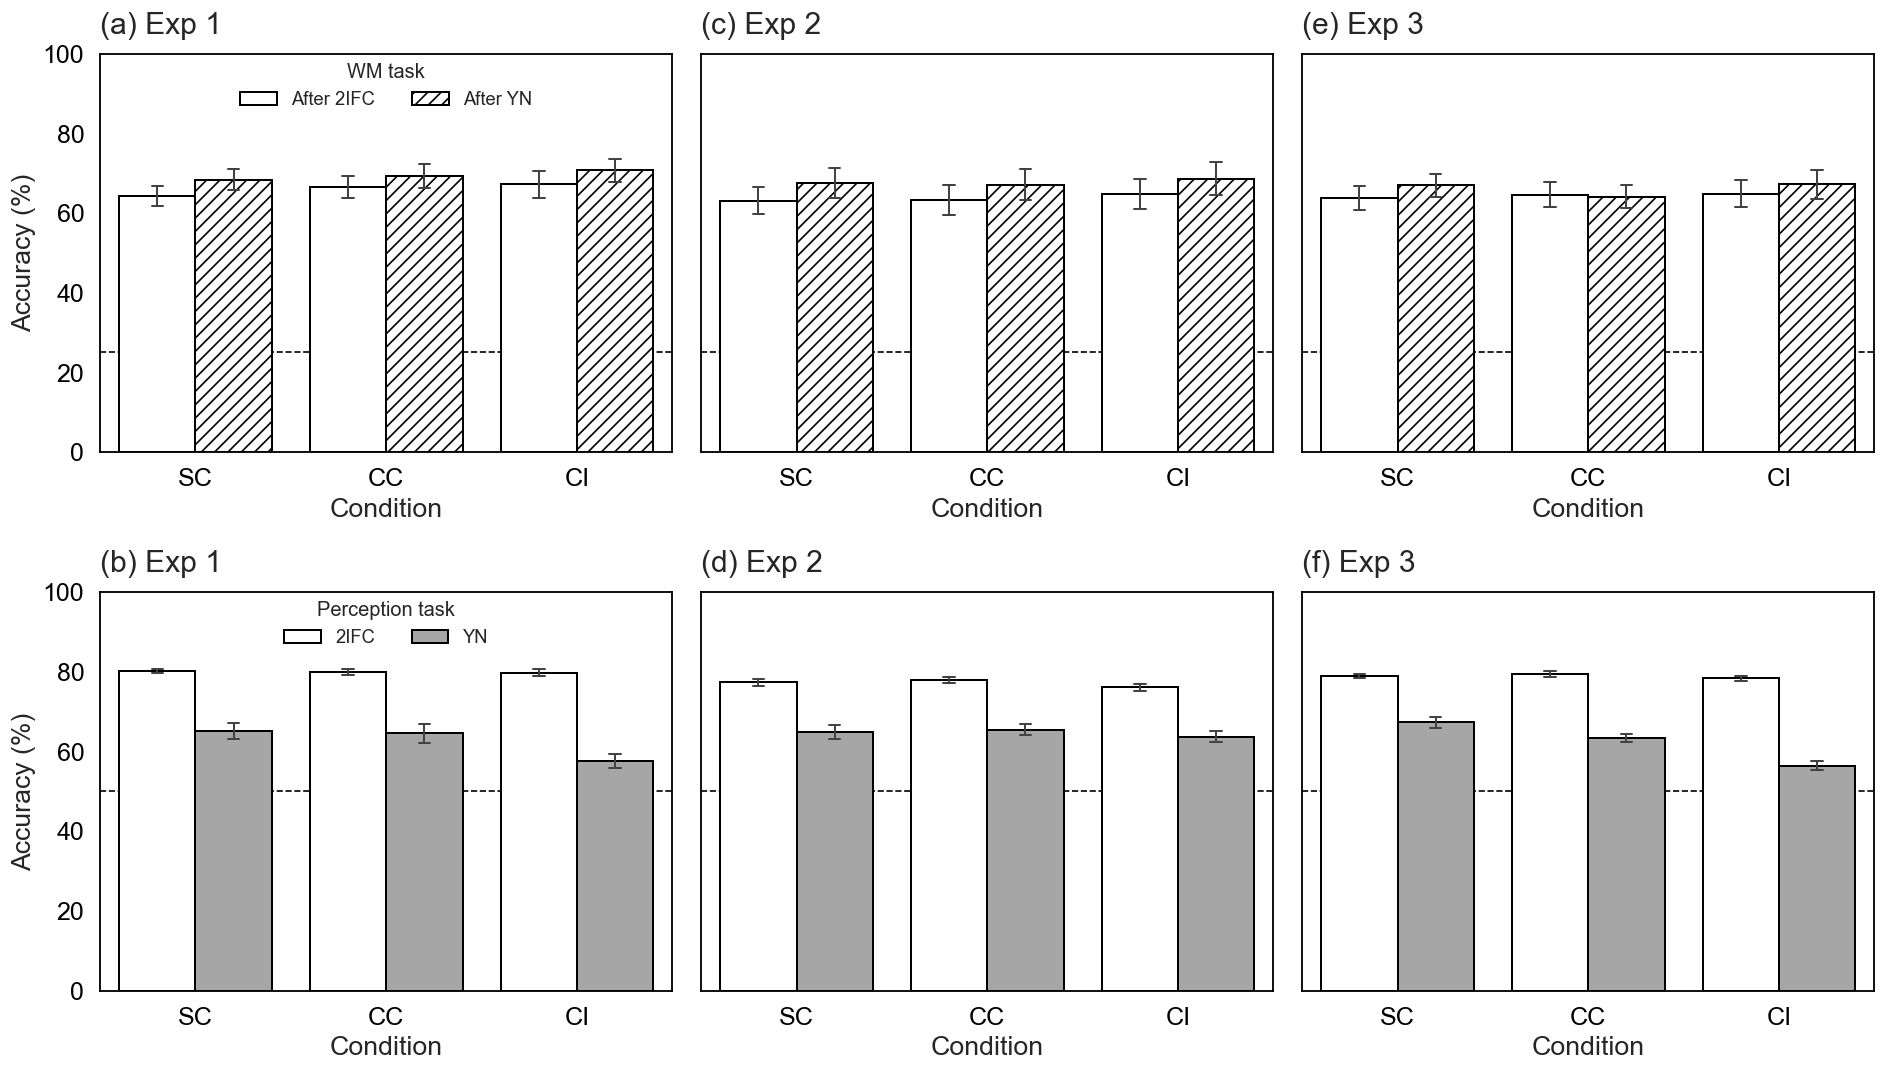

Saved → /Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)/GROUP_summary/SuppFigure1_exp1-3_accuracy_abcdef_ordinarySEM.png


In [346]:
# ============================================================
# Supplementary Figure 1. Exp1–Exp3 group summary: panels (a)–(f)
# ordinary SEM, no participant markers
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Experiment info
# --------------------------------------------------

EXPERIMENTS = [
    {
        'name': 'Exp 1',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)',
        'group_out': 'GROUP_summary',
        'participants': ['00003', '00038', '00051', '00052', 
                         '00054', '00060', '00061', '00068', 
                         '00071', '00130', '00161', '00162',
                         '00193', '00200', '00201', '00202']
    },
    {
        'name': 'Exp 2',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)',
        'group_out': 'GROUP_summary',
        'participants': ['00024', '00030', '00074', '00081', 
                         '000087', '00089', '00091', '00093', 
                         '00094', '00096', '00097', '00098',
                         '00099', '00100', '00102', '00105']
    },
    {
        'name': 'Exp 3',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)',
        'group_out': 'new_exp_GROUP_summary',
        'participants': ['00139', '00173', '00212', '00216', '00218',
                         '00219', '00220', '00222', '00224', '00225',
                         '00226', '00227', '00228', '00217', '00210',
                         '00223']
    }
]

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12
})

sns.set_style("white")

palette_two = ['white', '0.65']

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def find_raw_files(base_dir, pid):
    pattern = os.path.join(
        base_dir,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


def load_experiment_data(base_dir, participants):
    wm_list = []
    acc_list = []

    for pid in participants:

        paths = find_raw_files(base_dir, pid)

        if not paths:
            print(f'Missing raw files for {pid}')
            continue

        df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
        df_raw.columns = df_raw.columns.str.strip()
        df_raw = df_raw.reset_index(drop=True)

        required_cols = {'Task', 'Category', 'Combined_Correct'}

        if not required_cols.issubset(df_raw.columns):
            print(f'Missing required columns in {pid}')
            continue

        # ------------------------------
        # WM probe accuracy
        # ------------------------------
        followed_by = []

        for i, row in df_raw.iterrows():
            if row['Task'] == 'WM_probe':
                followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
            else:
                followed_by.append(None)

        df_raw['FollowedBy'] = followed_by

        wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
        wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

        if not wm.empty:
            tmp_wm = (
                wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_wm['acc'] = pd.to_numeric(
                tmp_wm['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_wm['Type'] = tmp_wm['FollowedBy'].map({
                '2IFC': 'After 2IFC',
                'YN': 'After YN'
            })

            tmp_wm['Subject'] = pid

            wm_list.append(tmp_wm[['Subject', 'Category', 'Type', 'acc']])

        # ------------------------------
        # 2IFC vs YN accuracy
        # ------------------------------
        sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

        if not sub.empty:
            tmp_acc = (
                sub.groupby(['Task', 'Category'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_acc['acc'] = pd.to_numeric(
                tmp_acc['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_acc['Subject'] = pid

            acc_list.append(tmp_acc[['Subject', 'Task', 'Category', 'acc']])

    if len(wm_list) == 0:
        raise RuntimeError(f'No WM probe data found in {base_dir}')

    if len(acc_list) == 0:
        raise RuntimeError(f'No task accuracy data found in {base_dir}')

    df_wm = pd.concat(wm_list, ignore_index=True)
    df_acc = pd.concat(acc_list, ignore_index=True)

    df_wm['Category'] = pd.Categorical(
        df_wm['Category'],
        categories=cond_order,
        ordered=True
    )

    df_wm['Type'] = pd.Categorical(
        df_wm['Type'],
        categories=phase_order,
        ordered=True
    )

    df_acc['Category'] = pd.Categorical(
        df_acc['Category'],
        categories=cond_order,
        ordered=True
    )

    df_acc['Task'] = pd.Categorical(
        df_acc['Task'],
        categories=task_order,
        ordered=True
    )

    return df_wm, df_acc


def plot_wm_accuracy(ax, df_wm, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_wm,
        x='Category',
        y='acc',
        hue='Type',
        order=cond_order,
        hue_order=phase_order,
        palette=['white', 'white'],
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )
    bars = ax.patches
    n_cond = len(cond_order)

    for i, bar in enumerate(bars):
        hue_idx = i // n_cond

        if hue_idx == 1:   # After YN
            bar.set_hatch('///')
        else:
            bar.set_hatch('')
            
    ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        leg = ax.legend(
            title='WM task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )

        handles = leg.legend_handles
        handles[0].set_hatch('')
        handles[1].set_hatch('///')

    else:
        ax.get_legend().remove()


def plot_task_accuracy(ax, df_acc, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_acc,
        x='Category',
        y='acc',
        hue='Task',
        order=cond_order,
        hue_order=task_order,
        palette=palette_two,
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )

    ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        ax.legend(
            title='Perception task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )
    else:
        ax.get_legend().remove()


# ==================================================
# Load data
# ==================================================

all_data = []

for exp in EXPERIMENTS:
    df_wm, df_acc = load_experiment_data(
        exp['base_dir'],
        exp['participants']
    )

    all_data.append({
        'name': exp['name'],
        'df_wm': df_wm,
        'df_acc': df_acc
    })


# ==================================================
# Plot 2 × 3 figure
# ==================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9.5),
    dpi=120,
    sharey='row'
)
axes = axes.flatten()
wm_axes = [0, 1, 2]
acc_axes = [3, 4, 5]

wm_labels = ['(a)', '(c)', '(e)']
acc_labels = ['(b)', '(d)', '(f)']

for i, exp_data in enumerate(all_data):

    # Top row: WM probe accuracy
    plot_wm_accuracy(
        axes[wm_axes[i]],
        exp_data['df_wm'],
        wm_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

    # Bottom row: 2IFC vs YN accuracy
    plot_task_accuracy(
        axes[acc_axes[i]],
        exp_data['df_acc'],
        acc_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.97])

# --------------------------------------------------
# Save
# --------------------------------------------------

OUT_DIR = os.path.join(
    EXPERIMENTS[0]['base_dir'],
    EXPERIMENTS[0]['group_out']
)

os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(
    OUT_DIR,
    'SuppFigure1_exp1-3_accuracy_abcdef_ordinarySEM.png'
)

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')

In [350]:
# ==================================================
# SEM 검토- Participant-level WM accuracy
# ==================================================

df_wm_raw_all = pd.concat(
    [d['df_wm'].assign(Experiment=d['name'])
     for d in all_data],
    ignore_index=True
)

df_wm_raw_all = df_wm_raw_all[
    ['Experiment', 'Subject', 'Category', 'Type', 'acc']
].sort_values(
    ['Experiment', 'Subject', 'Category', 'Type']
)

print('\n=== Participant-level WM accuracy ===')
print(df_wm_raw_all)

# save raw values
raw_out = os.path.join(
    OUT_DIR,
    'participant_level_WM_accuracy_raw.csv'
)

df_wm_raw_all.to_csv(raw_out, index=False)

# ==================================================
# Mean / SD / SEM summary
# ==================================================

wm_summary = (
    df_wm_raw_all
    .groupby(['Experiment', 'Category', 'Type'])['acc']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

wm_summary['SEM'] = (
    wm_summary['std']
    / np.sqrt(wm_summary['count'])
)

print('\n=== WM Accuracy Mean ± SEM ===')
print(wm_summary)

summary_out = os.path.join(
    OUT_DIR,
    'WM_accuracy_mean_SD_SEM.csv'
)

wm_summary.to_csv(summary_out, index=False)

print(f'Saved raw data -> {raw_out}')
print(f'Saved summary  -> {summary_out}')


=== Participant-level WM accuracy ===
    Experiment Subject Category        Type        acc
4        Exp 1   00003       SC  After 2IFC  75.252525
5        Exp 1   00003       SC    After YN  79.797980
0        Exp 1   00003       CC  After 2IFC  73.232323
1        Exp 1   00003       CC    After YN  81.313131
2        Exp 1   00003       CI  After 2IFC  76.767677
..         ...     ...      ...         ...        ...
269      Exp 3   00228       SC    After YN  86.363636
264      Exp 3   00228       CC  After 2IFC  82.323232
265      Exp 3   00228       CC    After YN  81.313131
266      Exp 3   00228       CI  After 2IFC  75.757576
267      Exp 3   00228       CI    After YN  81.313131

[288 rows x 5 columns]

=== WM Accuracy Mean ± SEM ===
   Experiment Category        Type       mean        std  count       SEM
0       Exp 1       SC  After 2IFC  64.353072  10.116855     16  2.529214
1       Exp 1       SC    After YN  68.389906  10.693668     16  2.673417
2       Exp 1       CC 


=== Participant-level WM accuracy used for plotting ===
          Experiment Subject Category        Type        acc
4              Exp 1   00139       SC  After 2IFC  72.727273
5              Exp 1   00139       SC    After YN  67.272727
0              Exp 1   00139       CC  After 2IFC  66.060606
1              Exp 1   00139       CC    After YN  56.363636
2              Exp 1   00139       CI  After 2IFC  61.212121
..               ...     ...      ...         ...        ...
287  Preliminary Exp   00202       SC    After YN  67.553191
282  Preliminary Exp   00202       CC  After 2IFC  66.486486
283  Preliminary Exp   00202       CC    After YN  68.720379
284  Preliminary Exp   00202       CI  After 2IFC  64.676617
285  Preliminary Exp   00202       CI    After YN  64.615385

[288 rows x 5 columns]

=== WM mean / SD / SEM used in barplot ===
         Experiment Category        Type       mean         SD   N       SEM
0             Exp 1       SC  After 2IFC  63.731061  11.964786  16

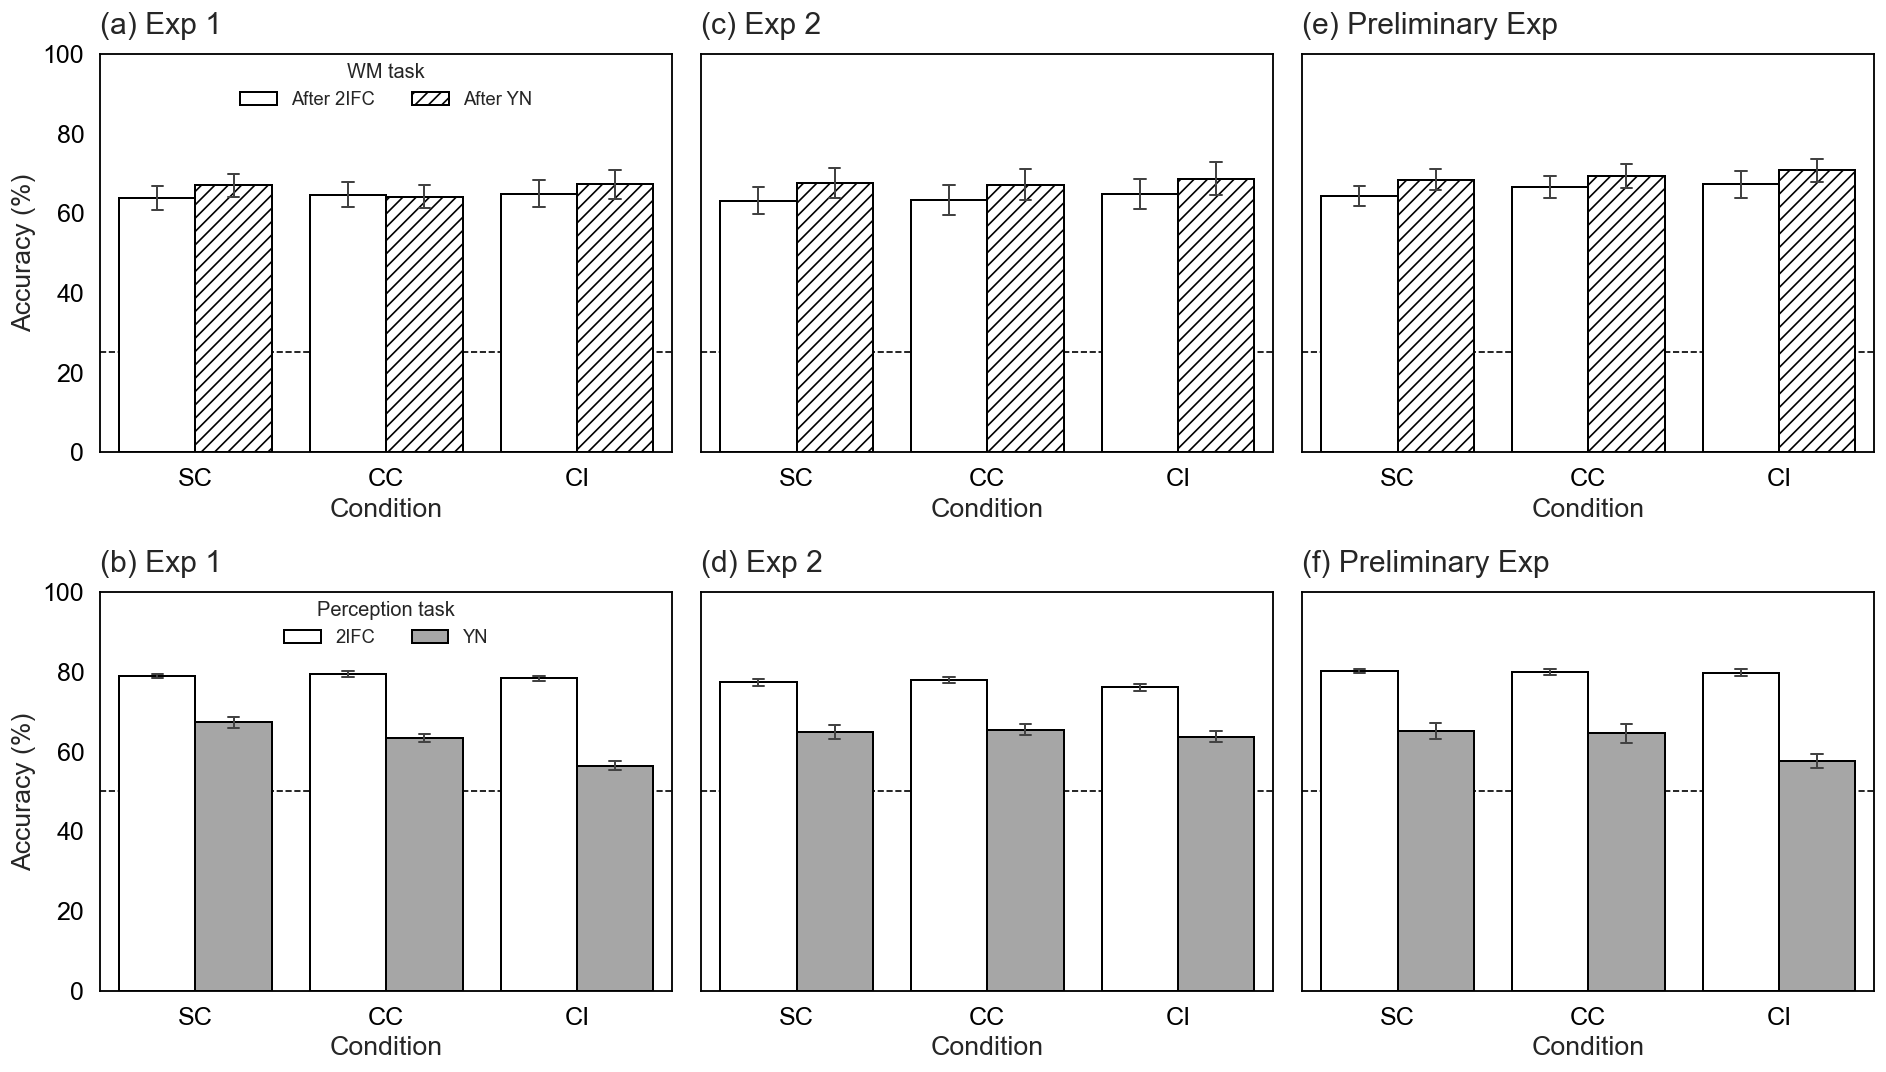

Saved → /Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/new_exp_GROUP_summary/SuppFigure1_exp1-3_accuracy_abcdef_ordinarySEM.png


In [495]:
# ============================================================
# Supplementary Figure 1. Exp1–Exp3 group summary: panels (a)–(f)
# ordinary SEM, no participant markers
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Experiment info
# --------------------------------------------------

EXPERIMENTS = [
     {
        'name': 'Exp 1',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)',
        'group_out': 'new_exp_GROUP_summary',
        'participants': ['00139', '00173', '00212', '00216', '00218',
                         '00219', '00220', '00222', '00224', '00225',
                         '00226', '00227', '00228', '00217', '00210',
                         '00223']
    },
    
    {
        'name': 'Exp 2',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)',
        'group_out': 'GROUP_summary',
        'participants': ['00024', '00030', '00074', '00081', 
                         '000087', '00089', '00091', '00093', 
                         '00094', '00096', '00097', '00098',
                         '00099', '00100', '00102', '00105']
    },
    
    {
        'name': 'Preliminary Exp',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)',
        'group_out': 'GROUP_summary',
        'participants': ['00003', '00038', '00051', '00052', 
                         '00054', '00060', '00061', '00068', 
                         '00071', '00130', '00161', '00162',
                         '00193', '00200', '00201', '00202']
    }
]

cond_order = ['SC', 'CC', 'CI']
phase_order = ['After 2IFC', 'After YN']
task_order = ['2IFC', 'YN']

# --------------------------------------------------
# Style
# --------------------------------------------------

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12
})

sns.set_style("white")

palette_two = ['white', '0.65']

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def find_raw_files(base_dir, pid):
    pattern = os.path.join(
        base_dir,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def format_axes(ax):
    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(axis='both', colors='black')


def load_experiment_data(base_dir, participants):
    wm_list = []
    acc_list = []

    for pid in participants:

        paths = find_raw_files(base_dir, pid)

        if not paths:
            print(f'Missing raw files for {pid}')
            continue

        df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
        df_raw.columns = df_raw.columns.str.strip()
        df_raw = df_raw.reset_index(drop=True)

        required_cols = {'Task', 'Category', 'Combined_Correct'}

        if not required_cols.issubset(df_raw.columns):
            print(f'Missing required columns in {pid}')
            continue

        # ------------------------------
        # WM probe accuracy
        # ------------------------------
        followed_by = []

        for i, row in df_raw.iterrows():
            if row['Task'] == 'WM_probe':
                followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else 'Unknown')
            else:
                followed_by.append(None)

        df_raw['FollowedBy'] = followed_by

        wm = df_raw[df_raw['Task'] == 'WM_probe'].copy()
        wm = wm[wm['FollowedBy'].isin(['2IFC', 'YN'])].copy()

        if not wm.empty:
            tmp_wm = (
                wm.groupby(['Category', 'FollowedBy'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_wm['acc'] = pd.to_numeric(
                tmp_wm['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_wm['Type'] = tmp_wm['FollowedBy'].map({
                '2IFC': 'After 2IFC',
                'YN': 'After YN'
            })

            tmp_wm['Subject'] = pid

            wm_list.append(tmp_wm[['Subject', 'Category', 'Type', 'acc']])

        # ------------------------------
        # 2IFC vs YN accuracy
        # ------------------------------
        sub = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()

        if not sub.empty:
            tmp_acc = (
                sub.groupby(['Task', 'Category'])['Combined_Correct']
                .mean()
                .reset_index()
            )

            tmp_acc['acc'] = pd.to_numeric(
                tmp_acc['Combined_Correct'],
                errors='coerce'
            ) * 100

            tmp_acc['Subject'] = pid

            acc_list.append(tmp_acc[['Subject', 'Task', 'Category', 'acc']])

    if len(wm_list) == 0:
        raise RuntimeError(f'No WM probe data found in {base_dir}')

    if len(acc_list) == 0:
        raise RuntimeError(f'No task accuracy data found in {base_dir}')

    df_wm = pd.concat(wm_list, ignore_index=True)
    df_acc = pd.concat(acc_list, ignore_index=True)

    df_wm['Category'] = pd.Categorical(
        df_wm['Category'],
        categories=cond_order,
        ordered=True
    )

    df_wm['Type'] = pd.Categorical(
        df_wm['Type'],
        categories=phase_order,
        ordered=True
    )

    df_acc['Category'] = pd.Categorical(
        df_acc['Category'],
        categories=cond_order,
        ordered=True
    )

    df_acc['Task'] = pd.Categorical(
        df_acc['Task'],
        categories=task_order,
        ordered=True
    )

    return df_wm, df_acc


def plot_wm_accuracy(ax, df_wm, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_wm,
        x='Category',
        y='acc',
        hue='Type',
        order=cond_order,
        hue_order=phase_order,
        palette=['white', 'white'],
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )
    bars = ax.patches
    n_cond = len(cond_order)

    for i, bar in enumerate(bars):
        hue_idx = i // n_cond

        if hue_idx == 1:   # After YN
            bar.set_hatch('///')
        else:
            bar.set_hatch('')
            
    ax.axhline(25, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        leg = ax.legend(
            title='WM task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )

        handles = leg.legend_handles
        handles[0].set_hatch('')
        handles[1].set_hatch('///')

    else:
        ax.get_legend().remove()


def plot_task_accuracy(ax, df_acc, panel_label, exp_name, show_legend=False):
    sns.barplot(
        data=df_acc,
        x='Category',
        y='acc',
        hue='Task',
        order=cond_order,
        hue_order=task_order,
        palette=palette_two,
        edgecolor='black',
        linewidth=1.2,
        errorbar='se',
        capsize=0.12,
        err_kws={'linewidth': 1.2},
        ax=ax
    )

    ax.axhline(50, linestyle='--', color='black', linewidth=1.0, zorder=0)

    ax.set_title(f'{panel_label} {exp_name}', loc='left', pad=12)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    format_axes(ax)

    if show_legend:
        ax.legend(
            title='Perception task',
            loc='upper center',
            bbox_to_anchor=(0.5, 1.00),
            frameon=False,
            ncol=2
        )
    else:
        ax.get_legend().remove()


# ==================================================
# Load data
# ==================================================

all_data = []

for exp in EXPERIMENTS:
    df_wm, df_acc = load_experiment_data(
        exp['base_dir'],
        exp['participants']
    )

    all_data.append({
        'name': exp['name'],
        'df_wm': df_wm,
        'df_acc': df_acc
    })


# ==================================================
# Plot 2 × 3 figure
# ==================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9.5),
    dpi=120,
    sharey='row'
)
axes = axes.flatten()
wm_axes = [0, 1, 2]
acc_axes = [3, 4, 5]

wm_labels = ['(a)', '(c)', '(e)']
acc_labels = ['(b)', '(d)', '(f)']

for i, exp_data in enumerate(all_data):

    # Top row: WM probe accuracy
    plot_wm_accuracy(
        axes[wm_axes[i]],
        exp_data['df_wm'],
        wm_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

    # Bottom row: 2IFC vs YN accuracy
    plot_task_accuracy(
        axes[acc_axes[i]],
        exp_data['df_acc'],
        acc_labels[i],
        exp_data['name'],
        show_legend=(i == 0)
    )

for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.97])

# --------------------------------------------------
# Save
# --------------------------------------------------

OUT_DIR = os.path.join(
    EXPERIMENTS[0]['base_dir'],
    EXPERIMENTS[0]['group_out']
)

os.makedirs(OUT_DIR, exist_ok=True)

out_path = os.path.join(
    OUT_DIR,
    'SuppFigure1_exp1-3_accuracy_abcdef_ordinarySEM.png'
)

# ==================================================
# Check WM accuracy values used for SEM
# ==================================================

df_wm_raw_all = pd.concat(
    [
        exp_data['df_wm'].assign(Experiment=exp_data['name'])
        for exp_data in all_data
    ],
    ignore_index=True
)

df_wm_raw_all = df_wm_raw_all[
    ['Experiment', 'Subject', 'Category', 'Type', 'acc']
].sort_values(
    ['Experiment', 'Subject', 'Category', 'Type']
)

wm_sem_check = (
    df_wm_raw_all
    .groupby(['Experiment', 'Category', 'Type'], observed=False)['acc']
    .agg(
        mean='mean',
        SD='std',
        N='count'
    )
    .reset_index()
)

wm_sem_check['SEM'] = wm_sem_check['SD'] / np.sqrt(wm_sem_check['N'])

print('\n=== Participant-level WM accuracy used for plotting ===')
print(df_wm_raw_all)

print('\n=== WM mean / SD / SEM used in barplot ===')
print(wm_sem_check)

raw_csv_path = os.path.join(
    OUT_DIR,
    'WM_accuracy_participant_level_used_for_plot.csv'
)

sem_csv_path = os.path.join(
    OUT_DIR,
    'WM_accuracy_mean_SD_SEM_used_for_plot.csv'
)

df_wm_raw_all.to_csv(raw_csv_path, index=False)
wm_sem_check.to_csv(sem_csv_path, index=False)

print(f'Saved participant-level WM accuracy → {raw_csv_path}')
print(f'Saved WM SEM summary → {sem_csv_path}')

fig.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f'Saved → {out_path}')

In [412]:
# ============================================================
# EXPERIMENT 1 rmANOVA script (Pingouin)
# ============================================================
# 1) WM accuracy (after 2IFC, after YN)
# 2) 2IFC, YN accuracy
# 3) 2IFC, YN d_a ~ Condition
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# 6) YN HR, FAR
# 7) 2IFC staircase contrast
# ------------------------------------------------------------
# 8) 2IFC, YN meta-d_a ~ Condition
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import pingouin as pg

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIRS = [
    '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)'
]
PARTICIPANTS = ['00003', '00038', '00051', '00052', 
                '00054', '00060', '00061', '00068', 
                '00071', '00130', '00161', '00162',
                '00193', '00200', '00201', '00202'
                ]
cond_order = ['SC', 'CC', 'CI']

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def print_pw(post):
    want = [
        'A', 'B', 'T', 'dof',
        'p_unc', 'p_corr', 'p_adjust',
        'p-unc', 'p-corr', 'p-adjust',
        'hedges'
    ]
    cols = [c for c in want if c in post.columns]
    print(post[cols])

def find_raw_files(base_dir, pid):
    pattern = os.path.join(
        base_dir,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_raw_subject(pid):
    paths = []

    for base_dir in BASE_DIRS:
        paths.extend(find_raw_files(base_dir, pid))

    if len(paths) == 0:
        print(f"No raw files found for {pid}")
        return None

    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()
    df = df.reset_index(drop=True)
    df['Subject'] = pid

    return df


def load_subject_file(pid, which='yn'):
    for base_dir in BASE_DIRS:
        f = os.path.join(base_dir, pid, 'summary', f'{pid}_{which}_meta.csv')

        if os.path.exists(f):
            df = pd.read_csv(f)

            if 'Condition' not in df.columns:
                first_col = df.columns[0]
                df = df.rename(columns={first_col: 'Condition'})

            df.columns = df.columns.str.strip()
            df['Subject'] = pid
            df['SourceDir'] = base_dir

            return df

    return None


def check_loaded_files(participants):
    print("=== File availability check ===")

    found_any = False

    for pid in participants:
        yn_df = load_subject_file(pid, 'yn')
        ifc_df = load_subject_file(pid, '2ifc')

        yn_status = 'OK' if yn_df is not None else 'Missing'
        ifc_status = 'OK' if ifc_df is not None else 'Missing'

        print(f"{pid}  |  YN: {yn_status}  |  2IFC: {ifc_status}")

        if yn_df is not None or ifc_df is not None:
            found_any = True

    if not found_any:
        raise ValueError("No files were loaded at all. Check BASE_DIRS and participant IDs.")

    print()


# ------------------------------------------------------------
# Initial file check
# ------------------------------------------------------------
check_loaded_files(PARTICIPANTS)


# ============================================================
# Load raw accuracy data
# ============================================================
dfs_task_acc = []
dfs_wm_acc = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Combined_Correct']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    df_raw['Combined_Correct'] = pd.to_numeric(
        df_raw['Combined_Correct'],
        errors='coerce'
    )

    # ------------------------------
    # Perceptual task accuracy
    # ------------------------------
    task_df = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()
    task_df = task_df[task_df['Category'].isin(cond_order)].copy()

    tmp_task = (
        task_df
        .groupby(['Subject', 'Task', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_task['Accuracy'] = tmp_task['Accuracy'] * 100
    dfs_task_acc.append(tmp_task)

    # ------------------------------
    # WM accuracy: After 2IFC vs After YN
    # ------------------------------
    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else np.nan)
        else:
            followed_by.append(np.nan)

    df_raw['FollowedBy'] = followed_by

    wm_df = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm_df = wm_df[wm_df['FollowedBy'].isin(['2IFC', 'YN'])].copy()
    wm_df = wm_df[wm_df['Category'].isin(cond_order)].copy()

    tmp_wm = (
        wm_df
        .groupby(['Subject', 'FollowedBy', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_wm['Accuracy'] = tmp_wm['Accuracy'] * 100
    tmp_wm['Phase'] = tmp_wm['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })

    dfs_wm_acc.append(tmp_wm[['Subject', 'Phase', 'Category', 'Accuracy']])


df_task_acc = pd.concat(dfs_task_acc, ignore_index=True)
df_wm_acc = pd.concat(dfs_wm_acc, ignore_index=True)

df_task_acc['Task'] = pd.Categorical(
    df_task_acc['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_task_acc['Category'] = pd.Categorical(
    df_task_acc['Category'],
    categories=cond_order,
    ordered=True
)

df_wm_acc['Phase'] = pd.Categorical(
    df_wm_acc['Phase'],
    categories=['After 2IFC', 'After YN'],
    ordered=True
)

df_wm_acc['Category'] = pd.Categorical(
    df_wm_acc['Category'],
    categories=cond_order,
    ordered=True
)


# ============================================================
# Load d_a / meta-d_a data
# ============================================================
dfs_2ifc = []
dfs_yn = []

for pid in PARTICIPANTS:

    # ------------------------------
    # 2IFC
    # ------------------------------
    df = load_subject_file(pid, which='2ifc')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] 2IFC file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_2ifc.append(tmp)

    # ------------------------------
    # YN
    # ------------------------------
    df = load_subject_file(pid, which='yn')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] YN file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_yn.append(tmp)


if len(dfs_2ifc) == 0:
    raise ValueError("No 2IFC meta files were loaded.")

if len(dfs_yn) == 0:
    raise ValueError("No YN meta files were loaded.")


df_2ifc_all = pd.concat(dfs_2ifc, ignore_index=True)
df_yn_all = pd.concat(dfs_yn, ignore_index=True)

df_2ifc_all = df_2ifc_all[df_2ifc_all['Condition'].isin(cond_order)].copy()
df_yn_all = df_yn_all[df_yn_all['Condition'].isin(cond_order)].copy()

df_2ifc_all['Condition'] = pd.Categorical(
    df_2ifc_all['Condition'],
    categories=cond_order,
    ordered=True
)

df_yn_all['Condition'] = pd.Categorical(
    df_yn_all['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Loaded 2IFC data ===")
print(df_2ifc_all.groupby(['Subject', 'Condition'], observed=False).size())

print("\n=== Loaded YN data ===")
print(df_yn_all.groupby(['Subject', 'Condition'], observed=False).size())


# ============================================================
# 1) WM accuracy: Phase × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 1) WM accuracy: Phase × Condition")
print("# ============================================================")

print("\n=== WM accuracy means ===")
print(
    df_wm_acc
    .groupby(['Phase', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_wm_acc = pg.rm_anova(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: WM accuracy ~ Phase × Condition ===")
print(aov_wm_acc)

post_wm_acc = pg.pairwise_tests(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: WM accuracy ---")
print_pw(post_wm_acc)


# ============================================================
# 2) 2IFC, YN accuracy: Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 2) 2IFC, YN accuracy: Task × Condition")
print("# ============================================================")

print("\n=== Perceptual accuracy means ===")
print(
    df_task_acc
    .groupby(['Task', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_task_acc = pg.rm_anova(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Perceptual accuracy ~ Task × Condition ===")
print(aov_task_acc)

post_task_acc = pg.pairwise_tests(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: Perceptual accuracy ---")
print_pw(post_task_acc)

# ------------------------------------------------------------
# YN accuracy above chance test: one-sample t-test vs 50%
# ------------------------------------------------------------
from scipy.stats import ttest_1samp

print("\n--- YN accuracy above chance (50%) ---")

df_yn_acc = df_task_acc[df_task_acc['Task'] == 'YN'].copy()

for cond in cond_order:

    tmp = (
        df_yn_acc[df_yn_acc['Category'] == cond]['Accuracy']
        .dropna()
        .values
    )

    t, p_two = ttest_1samp(tmp, popmean=50)

    # one-tailed (greater than chance)
    p_one = p_two / 2 if t > 0 else 1 - p_two / 2

    print(f"\n=== {cond} ===")
    print(f"Mean = {tmp.mean():.2f}%")
    print(f"t({len(tmp)-1}) = {t:.3f}")
    print(f"one-tailed p = {p_one:.6f}")
    
# ============================================================
# 3) 2IFC, YN d_a ~ Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 3) 2IFC, YN d_a ~ Task × Condition")
print("# ============================================================")

df_2ifc_da_long = df_2ifc_all[['Subject', 'Condition', 'da']].copy()
df_2ifc_da_long['Task'] = '2IFC'

df_yn_da_long = df_yn_all[['Subject', 'Condition', 'da']].copy()
df_yn_da_long['Task'] = 'YN'

df_da_2x3 = pd.concat(
    [df_2ifc_da_long, df_yn_da_long],
    ignore_index=True
)

df_da_2x3 = df_da_2x3.dropna(subset=['Subject', 'Condition', 'Task', 'da']).copy()

df_da_2x3['Task'] = pd.Categorical(
    df_da_2x3['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_da_2x3['Condition'] = pd.Categorical(
    df_da_2x3['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Mean d_a by Task × Condition ===")
print(
    df_da_2x3
    .groupby(['Task', 'Condition'], observed=False)['da']
    .agg(['mean', 'std', 'count'])
)

aov_da_2x3 = pg.rm_anova(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: d_a ~ Task × Condition ===")
print(aov_da_2x3)

post_task_da = pg.pairwise_tests(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: d_a ---")
print_pw(post_task_da)


# Optional separate one-way d_a analyses
aov_2ifc_da = pg.rm_anova(
    data=df_2ifc_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC d_a ~ Condition ===")
print(aov_2ifc_da)

aov_yn_da = pg.rm_anova(
    data=df_yn_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN d_a ~ Condition ===")
print(aov_yn_da)


# ============================================================
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 4) Ratio: YN d_a / 2IFC d_a ~ Condition")
print("# ============================================================")

df_ratio = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_ratio = df_ratio.dropna(subset=['da_yn', 'da_2ifc']).copy()
df_ratio = df_ratio[df_ratio['da_2ifc'] != 0].copy()

df_ratio['da_ratio'] = df_ratio['da_yn'] / df_ratio['da_2ifc']

df_ratio['Condition'] = pd.Categorical(
    df_ratio['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Ratio means by Condition ===")
print(
    df_ratio
    .groupby('Condition', observed=False)['da_ratio']
    .agg(['mean', 'std', 'count'])
)

aov_ratio = pg.rm_anova(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN/2IFC d_a ratio ~ Condition ===")
print(aov_ratio)

post_ratio = pg.pairwise_tests(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: ratio ---")
print_pw(post_ratio)


# ============================================================
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# ============================================================
print("\n\n# ============================================================")
print("# 5) 2IFC d_a / sqrt(2) ~ YN d_a")
print("# ============================================================")

df_scaled = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_scaled['da_2ifc_scaled'] = df_scaled['da_2ifc'] / np.sqrt(2)

print("\n=== 2IFC/sqrt(2) vs YN means ===")
print(
    df_scaled
    .groupby('Condition', observed=False)[['da_yn', 'da_2ifc_scaled']]
    .mean()
)

df_scaled_long = pd.concat([
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'YN',
        'da': df_scaled['da_yn']
    }),
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'Scaled_2IFC',
        'da': df_scaled['da_2ifc_scaled']
    })
], ignore_index=True)

df_scaled_long['Task'] = pd.Categorical(
    df_scaled_long['Task'],
    categories=['Scaled_2IFC', 'YN'],
    ordered=True
)

df_scaled_long['Condition'] = pd.Categorical(
    df_scaled_long['Condition'],
    categories=cond_order,
    ordered=True
)

aov_scaled = pg.rm_anova(
    data=df_scaled_long,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Scaled 2IFC vs YN d_a ===")
print(aov_scaled)

print("\n--- Bonferroni-corrected paired t-tests: YN vs 2IFC/sqrt(2) ---")

results = []

for cond in cond_order:

    tmp = df_scaled[df_scaled['Condition'] == cond]

    res = pg.ttest(
        tmp['da_yn'],
        tmp['da_2ifc_scaled'],
        paired=True
    )

    res = res.iloc[0]

    p_unc = res['p_val']
    p_corr = min(p_unc * len(cond_order), 1.0)

    results.append({
        'Condition': cond,
        'T': res['T'],
        'dof': res['dof'],
        'p_unc': p_unc,
        'p_corr': p_corr,
        'cohen_d': res['cohen_d']
    })

print(pd.DataFrame(results))

# ------------------------------------------------------------
# Condition differences within each task:
# SC vs CC vs CI separately for Scaled_2IFC and YN
# ------------------------------------------------------------
print("\n--- Condition differences within Scaled_2IFC and within YN ---")

for task in ['Scaled_2IFC', 'YN']:

    tmp = df_scaled_long[df_scaled_long['Task'] == task].copy()

    print(f"\n=== {task}: Condition effect ===")

    aov_task_condition = pg.rm_anova(
        data=tmp,
        dv='da',
        within='Condition',
        subject='Subject',
        correction=True,
        detailed=True
    )

    print(aov_task_condition)

    post_task_condition = pg.pairwise_tests(
        data=tmp,
        dv='da',
        within='Condition',
        subject='Subject',
        padjust='bonf',
        effsize='hedges'
    )

    print(f"\n--- Post-hoc: {task}, SC vs CC vs CI ---")
    print_pw(post_task_condition)
# ============================================================
# 6) YN HR, FAR
# ============================================================
print("\n\n# ============================================================")
print("# 6) YN HR, FAR")
print("# ============================================================")

hrfar_path = os.path.join(
    BASE_DIRS[0],
    'GROUP_summary',
    'GROUP_YN_HR_FAR_raw_from_summary.csv'
)

if not os.path.exists(hrfar_path):
    raise FileNotFoundError(f"HR/FAR file not found: {hrfar_path}")

df_yn_hrfar = pd.read_csv(hrfar_path)
df_yn_hrfar.columns = df_yn_hrfar.columns.str.strip()

df_yn_hrfar = df_yn_hrfar.rename(columns={
    'HitRate': 'HR',
    'hit_rate': 'HR',
    'FalseAlarmRate': 'FAR',
    'false_alarm_rate': 'FAR',
    'FA': 'FAR'
})

required_cols = ['Subject', 'Condition', 'HR', 'FAR']

for col in required_cols:
    if col not in df_yn_hrfar.columns:
        raise ValueError(
            f"{col} not found in HR/FAR dataframe. "
            f"Available columns: {df_yn_hrfar.columns.tolist()}"
        )

df_yn_hrfar = df_yn_hrfar[df_yn_hrfar['Condition'].isin(cond_order)].copy()

df_yn_hrfar['Condition'] = pd.Categorical(
    df_yn_hrfar['Condition'],
    categories=cond_order,
    ordered=True
)

df_hrfar_long = pd.concat([
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'HR',
        'Value': df_yn_hrfar['HR']
    }),
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'FAR',
        'Value': df_yn_hrfar['FAR']
    })
], ignore_index=True)

df_hrfar_long['Measure'] = pd.Categorical(
    df_hrfar_long['Measure'],
    categories=['HR', 'FAR'],
    ordered=True
)

print("\n=== YN HR/FAR means ===")
print(
    df_hrfar_long
    .groupby(['Condition', 'Measure'], observed=False)['Value']
    .agg(['mean', 'std', 'count'])
)

aov_hrfar = pg.rm_anova(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: YN HR/FAR ~ Measure × Condition ===")
print(aov_hrfar)

post_hrfar = pg.pairwise_tests(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN HR/FAR ---")
print_pw(post_hrfar)

# ============================================================
# One-way rmANOVA: HR
# ============================================================

print("\n=== One-way rmANOVA: HR ~ Condition ===")

df_hr = df_yn_hrfar[['Subject', 'Condition', 'HR']].copy()

aov_hr = pg.rm_anova(
    data=df_hr,
    dv='HR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_hr)


# ============================================================
# One-way rmANOVA: FAR
# ============================================================

print("\n=== One-way rmANOVA: FAR ~ Condition ===")

df_far = df_yn_hrfar[['Subject', 'Condition', 'FAR']].copy()

aov_far = pg.rm_anova(
    data=df_far,
    dv='FAR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_far)

# ============================================================
# 7) 2IFC staircase contrast
# ============================================================
print("\n\n# ============================================================")
print("# 7) 2IFC staircase contrast")
print("# ============================================================")

dfs_contrast = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Contrast']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()
    sub = sub[sub['Category'].isin(cond_order)].copy()

    sub['Contrast'] = pd.to_numeric(sub['Contrast'], errors='coerce')

    tmp = (
        sub
        .groupby(['Subject', 'Category'], observed=False)['Contrast']
        .mean()
        .reset_index()
    )

    dfs_contrast.append(tmp)

df_contrast = pd.concat(dfs_contrast, ignore_index=True)

df_contrast['Category'] = pd.Categorical(
    df_contrast['Category'],
    categories=cond_order,
    ordered=True
)

print("\n=== 2IFC staircase contrast means ===")
print(
    df_contrast
    .groupby('Category', observed=False)['Contrast']
    .agg(['mean', 'std', 'count'])
)

aov_contrast = pg.rm_anova(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC staircase contrast ~ Condition ===")
print(aov_contrast)

post_contrast = pg.pairwise_tests(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    padjust='bonf',
    effsize='hedges',
    return_desc=True
)

print(post_contrast)
print("\n--- Post-hoc: 2IFC staircase contrast ---")
print_pw(post_contrast)

# ============================================================
# 8) 2IFC, YN meta-d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 8) 2IFC, YN meta-d_a ~ Condition")
print("# ============================================================")

aov_2ifc_meta = pg.rm_anova(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC meta-d_a ~ Condition ===")
print(aov_2ifc_meta)

post_2ifc_meta = pg.pairwise_tests(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: 2IFC meta-d_a ---")
print_pw(post_2ifc_meta)

aov_yn_meta = pg.rm_anova(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN meta-d_a ~ Condition ===")
print(aov_yn_meta)

post_yn_meta = pg.pairwise_tests(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN meta-d_a ---")
print_pw(post_yn_meta)


# ============================================================
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================
print("\n\n# ============================================================")
print("# 9) Optional: Mauchly sphericity checks")
print("# ============================================================")

print("2IFC d_a       :", pg.sphericity(df_2ifc_all, dv='da', subject='Subject', within='Condition'))
print("YN d_a         :", pg.sphericity(df_yn_all, dv='da', subject='Subject', within='Condition'))
print("Ratio d_a      :", pg.sphericity(df_ratio, dv='da_ratio', subject='Subject', within='Condition'))
print("2IFC meta-d_a  :", pg.sphericity(df_2ifc_all, dv='meta_da', subject='Subject', within='Condition'))
print("YN meta-d_a    :", pg.sphericity(df_yn_all, dv='meta_da', subject='Subject', within='Condition'))
print("Contrast       :", pg.sphericity(df_contrast, dv='Contrast', subject='Subject', within='Category'))

print("\nDone.")

=== File availability check ===
00003  |  YN: OK  |  2IFC: OK
00038  |  YN: OK  |  2IFC: OK
00051  |  YN: OK  |  2IFC: OK
00052  |  YN: OK  |  2IFC: OK
00054  |  YN: OK  |  2IFC: OK
00060  |  YN: OK  |  2IFC: OK
00061  |  YN: OK  |  2IFC: OK
00068  |  YN: OK  |  2IFC: OK
00071  |  YN: OK  |  2IFC: OK
00130  |  YN: OK  |  2IFC: OK
00161  |  YN: OK  |  2IFC: OK
00162  |  YN: OK  |  2IFC: OK
00193  |  YN: OK  |  2IFC: OK
00200  |  YN: OK  |  2IFC: OK
00201  |  YN: OK  |  2IFC: OK
00202  |  YN: OK  |  2IFC: OK


=== Loaded 2IFC data ===
Subject  Condition
00003    SC           1
         CC           1
         CI           1
00038    SC           1
         CC           1
         CI           1
00051    SC           1
         CC           1
         CI           1
00052    SC           1
         CC           1
         CI           1
00054    SC           1
         CC           1
         CI           1
00060    SC           1
         CC           1
         CI           1
00061    S

In [261]:
for pid in PARTICIPANTS:
    df = load_subject_file(pid, which='yn')
    if df is not None:
        print(pid)
        print(df.columns.tolist())
        break

00003
['Condition', 'slope', 'd1', 'da', 'meta_d', 'meta_da', 'M_ratio (da)', 'Subject', 'SourceDir']


In [406]:
# ============================================================
# Experiment 3 rmANOVA (Pingouin)
# ------------------------------------------------------------
# 1) WM accuracy (after 2IFC, after YN)
# 2) 2IFC, YN accuracy
# 3) 2IFC, YN d_a ~ Condition
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# 6) YN HR, FAR
# 7) 2IFC staircase contrast
# ------------------------------------------------------------
# 8) 2IFC, YN meta-d_a ~ Condition
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import pingouin as pg

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIRS = [
    '/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)'
]
PARTICIPANTS = ['00139', '00173', '00210', '00212', '00216',
                '00217', '00218', '00219', '00220', '00222', 
                '00223', '00224', '00225', '00226', '00227', 
                '00228'
                ]

cond_order = ['SC', 'CC', 'CI']

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------


def print_pw(post):
    want = [
        'A', 'B', 'T', 'dof',
        'p-val', 'p_val',
        'p-unc', 'p_unc',
        'p-corr', 'p_corr',
        'p-adjust', 'p_adjust',
        'hedges'
    ]
    cols = [c for c in want if c in post.columns]
    print(post[cols])
    
def find_raw_files(base_dir, pid):
    pattern = os.path.join(
        base_dir,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_raw_subject(pid):
    paths = []

    for base_dir in BASE_DIRS:
        paths.extend(find_raw_files(base_dir, pid))

    if len(paths) == 0:
        print(f"No raw files found for {pid}")
        return None

    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()
    df = df.reset_index(drop=True)
    df['Subject'] = pid

    return df


def load_subject_file(pid, which='yn'):
    for base_dir in BASE_DIRS:
        f = os.path.join(base_dir, pid, 'summary', f'{pid}_{which}_meta.csv')

        if os.path.exists(f):
            df = pd.read_csv(f)

            if 'Condition' not in df.columns:
                first_col = df.columns[0]
                df = df.rename(columns={first_col: 'Condition'})

            df.columns = df.columns.str.strip()
            df['Subject'] = pid
            df['SourceDir'] = base_dir

            return df

    return None


def check_loaded_files(participants):
    print("=== File availability check ===")

    found_any = False

    for pid in participants:
        yn_df = load_subject_file(pid, 'yn')
        ifc_df = load_subject_file(pid, '2ifc')

        yn_status = 'OK' if yn_df is not None else 'Missing'
        ifc_status = 'OK' if ifc_df is not None else 'Missing'

        print(f"{pid}  |  YN: {yn_status}  |  2IFC: {ifc_status}")

        if yn_df is not None or ifc_df is not None:
            found_any = True

    if not found_any:
        raise ValueError("No files were loaded at all. Check BASE_DIRS and participant IDs.")

    print()


# ------------------------------------------------------------
# Initial file check
# ------------------------------------------------------------
check_loaded_files(PARTICIPANTS)


# ============================================================
# Load raw accuracy data
# ============================================================
dfs_task_acc = []
dfs_wm_acc = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Combined_Correct']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    df_raw['Combined_Correct'] = pd.to_numeric(
        df_raw['Combined_Correct'],
        errors='coerce'
    )

    # ------------------------------
    # Perceptual task accuracy
    # ------------------------------
    task_df = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()
    task_df = task_df[task_df['Category'].isin(cond_order)].copy()

    tmp_task = (
        task_df
        .groupby(['Subject', 'Task', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_task['Accuracy'] = tmp_task['Accuracy'] * 100
    dfs_task_acc.append(tmp_task)

    # ------------------------------
    # WM accuracy: After 2IFC vs After YN
    # ------------------------------
    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else np.nan)
        else:
            followed_by.append(np.nan)

    df_raw['FollowedBy'] = followed_by

    wm_df = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm_df = wm_df[wm_df['FollowedBy'].isin(['2IFC', 'YN'])].copy()
    wm_df = wm_df[wm_df['Category'].isin(cond_order)].copy()

    tmp_wm = (
        wm_df
        .groupby(['Subject', 'FollowedBy', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_wm['Accuracy'] = tmp_wm['Accuracy'] * 100
    tmp_wm['Phase'] = tmp_wm['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })

    dfs_wm_acc.append(tmp_wm[['Subject', 'Phase', 'Category', 'Accuracy']])


df_task_acc = pd.concat(dfs_task_acc, ignore_index=True)
df_wm_acc = pd.concat(dfs_wm_acc, ignore_index=True)

df_task_acc['Task'] = pd.Categorical(
    df_task_acc['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_task_acc['Category'] = pd.Categorical(
    df_task_acc['Category'],
    categories=cond_order,
    ordered=True
)

df_wm_acc['Phase'] = pd.Categorical(
    df_wm_acc['Phase'],
    categories=['After 2IFC', 'After YN'],
    ordered=True
)

df_wm_acc['Category'] = pd.Categorical(
    df_wm_acc['Category'],
    categories=cond_order,
    ordered=True
)


# ============================================================
# Load d_a / meta-d_a data
# ============================================================
dfs_2ifc = []
dfs_yn = []

for pid in PARTICIPANTS:

    # ------------------------------
    # 2IFC
    # ------------------------------
    df = load_subject_file(pid, which='2ifc')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] 2IFC file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_2ifc.append(tmp)

    # ------------------------------
    # YN
    # ------------------------------
    df = load_subject_file(pid, which='yn')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] YN file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_yn.append(tmp)


if len(dfs_2ifc) == 0:
    raise ValueError("No 2IFC meta files were loaded.")

if len(dfs_yn) == 0:
    raise ValueError("No YN meta files were loaded.")


df_2ifc_all = pd.concat(dfs_2ifc, ignore_index=True)
df_yn_all = pd.concat(dfs_yn, ignore_index=True)

df_2ifc_all = df_2ifc_all[df_2ifc_all['Condition'].isin(cond_order)].copy()
df_yn_all = df_yn_all[df_yn_all['Condition'].isin(cond_order)].copy()

df_2ifc_all['Condition'] = pd.Categorical(
    df_2ifc_all['Condition'],
    categories=cond_order,
    ordered=True
)

df_yn_all['Condition'] = pd.Categorical(
    df_yn_all['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Loaded 2IFC data ===")
print(df_2ifc_all.groupby(['Subject', 'Condition'], observed=False).size())

print("\n=== Loaded YN data ===")
print(df_yn_all.groupby(['Subject', 'Condition'], observed=False).size())


# ============================================================
# 1) WM accuracy: Phase × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 1) WM accuracy: Phase × Condition")
print("# ============================================================")

print("\n=== WM accuracy means ===")
print(
    df_wm_acc
    .groupby(['Phase', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_wm_acc = pg.rm_anova(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: WM accuracy ~ Phase × Condition ===")
print(aov_wm_acc)

post_wm_acc = pg.pairwise_tests(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: WM accuracy ---")
print_pw(post_wm_acc)


# ============================================================
# 2) 2IFC, YN accuracy: Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 2) 2IFC, YN accuracy: Task × Condition")
print("# ============================================================")

print("\n=== Perceptual accuracy means ===")
print(
    df_task_acc
    .groupby(['Task', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_task_acc = pg.rm_anova(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Perceptual accuracy ~ Task × Condition ===")
print(aov_task_acc)

post_task_acc = pg.pairwise_tests(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: Perceptual accuracy ---")
print_pw(post_task_acc)

from scipy.stats import ttest_rel

for cond in ['SC','CC','CI']:

    tmp = df_task_acc[df_task_acc['Category']==cond]

    wide = tmp.pivot(index='Subject',
                     columns='Task',
                     values='Accuracy')

    t, p = ttest_rel(wide['2IFC'], wide['YN'])

    print(cond, t, p)
# ============================================================
# 3) 2IFC, YN d_a ~ Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 3) 2IFC, YN d_a ~ Task × Condition")
print("# ============================================================")

df_2ifc_da_long = df_2ifc_all[['Subject', 'Condition', 'da']].copy()
df_2ifc_da_long['Task'] = '2IFC'

df_yn_da_long = df_yn_all[['Subject', 'Condition', 'da']].copy()
df_yn_da_long['Task'] = 'YN'

df_da_2x3 = pd.concat(
    [df_2ifc_da_long, df_yn_da_long],
    ignore_index=True
)

df_da_2x3 = df_da_2x3.dropna(subset=['Subject', 'Condition', 'Task', 'da']).copy()

df_da_2x3['Task'] = pd.Categorical(
    df_da_2x3['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_da_2x3['Condition'] = pd.Categorical(
    df_da_2x3['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Mean d_a by Task × Condition ===")
print(
    df_da_2x3
    .groupby(['Task', 'Condition'], observed=False)['da']
    .agg(['mean', 'std', 'count'])
)

aov_da_2x3 = pg.rm_anova(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: d_a ~ Task × Condition ===")
print(aov_da_2x3)

post_task_da = pg.pairwise_tests(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: d_a ---")
print_pw(post_task_da)


# Optional separate one-way d_a analyses
aov_2ifc_da = pg.rm_anova(
    data=df_2ifc_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC d_a ~ Condition ===")
print(aov_2ifc_da)

aov_yn_da = pg.rm_anova(
    data=df_yn_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN d_a ~ Condition ===")
print(aov_yn_da)


# ============================================================
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 4) Ratio: YN d_a / 2IFC d_a ~ Condition")
print("# ============================================================")

df_ratio = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_ratio = df_ratio.dropna(subset=['da_yn', 'da_2ifc']).copy()
df_ratio = df_ratio[df_ratio['da_2ifc'] != 0].copy()

df_ratio['da_ratio'] = df_ratio['da_yn'] / df_ratio['da_2ifc']

df_ratio['Condition'] = pd.Categorical(
    df_ratio['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Ratio means by Condition ===")
print(
    df_ratio
    .groupby('Condition', observed=False)['da_ratio']
    .agg(['mean', 'std', 'count'])
)

aov_ratio = pg.rm_anova(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN/2IFC d_a ratio ~ Condition ===")
print(aov_ratio)

# ------------------------------------------------------------
# Pairwise comparisons
# ------------------------------------------------------------
post_ratio = pg.pairwise_tests(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n=== Post-hoc: ratio ===")

# 먼저 컬럼 확인
print(post_ratio.columns)

# 원하는 컬럼만 출력
cols = [c for c in [
    'A','B',
    'T','dof',
    'p-unc','p_unc',
    'p-corr','p_corr',
    'p-adjust','p_adjust',
    'hedges'
] if c in post_ratio.columns]

print(post_ratio[cols])


# ============================================================
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# ============================================================
print("\n\n# ============================================================")
print("# 5) 2IFC d_a / sqrt(2) ~ YN d_a")
print("# ============================================================")

df_scaled = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_scaled['da_2ifc_scaled'] = df_scaled['da_2ifc'] / np.sqrt(2)

print("\n=== 2IFC/sqrt(2) vs YN means ===")
print(
    df_scaled
    .groupby('Condition', observed=False)[['da_yn', 'da_2ifc_scaled']]
    .mean()
)

df_scaled_long = pd.concat([
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'YN',
        'da': df_scaled['da_yn']
    }),
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'Scaled_2IFC',
        'da': df_scaled['da_2ifc_scaled']
    })
], ignore_index=True)

df_scaled_long['Task'] = pd.Categorical(
    df_scaled_long['Task'],
    categories=['Scaled_2IFC', 'YN'],
    ordered=True
)

df_scaled_long['Condition'] = pd.Categorical(
    df_scaled_long['Condition'],
    categories=cond_order,
    ordered=True
)

aov_scaled = pg.rm_anova(
    data=df_scaled_long,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Scaled 2IFC vs YN d_a ===")
print(aov_scaled)

print("\n--- Condition-wise paired t-tests: YN vs 2IFC/sqrt(2) ---")

for cond in cond_order:
    tmp = df_scaled[df_scaled['Condition'] == cond].copy()

    res = pg.ttest(
        tmp['da_yn'],
        tmp['da_2ifc_scaled'],
        paired=True
    )

    # Hedges' g
    hedges_g = pg.compute_effsize(
        tmp['da_yn'],
        tmp['da_2ifc_scaled'],
        paired=True,
        eftype='hedges'
    )

    res['hedges'] = hedges_g

    cols = [c for c in ['T', 'dof', 'p-val', 'p_val',
                        'hedges', 'CI95%', 'CI95']
            if c in res.columns]

    print(f"\n=== {cond}: YN vs 2IFC/sqrt(2) ===")
    print(res[cols])

# ============================================================
# 6) YN HR, FAR
# ============================================================
print("\n\n# ============================================================")
print("# 6) YN HR, FAR")
print("# ============================================================")

hrfar_path = os.path.join(
    BASE_DIRS[0],
    'GROUP_summary',
    'GROUP_YN_HR_FAR_raw_from_summary.csv'
)

if not os.path.exists(hrfar_path):
    raise FileNotFoundError(f"HR/FAR file not found: {hrfar_path}")

df_yn_hrfar = pd.read_csv(hrfar_path)
df_yn_hrfar.columns = df_yn_hrfar.columns.str.strip()

df_yn_hrfar = df_yn_hrfar.rename(columns={
    'HitRate': 'HR',
    'hit_rate': 'HR',
    'FalseAlarmRate': 'FAR',
    'false_alarm_rate': 'FAR',
    'FA': 'FAR'
})

required_cols = ['Subject', 'Condition', 'HR', 'FAR']

for col in required_cols:
    if col not in df_yn_hrfar.columns:
        raise ValueError(
            f"{col} not found in HR/FAR dataframe. "
            f"Available columns: {df_yn_hrfar.columns.tolist()}"
        )

df_yn_hrfar = df_yn_hrfar[df_yn_hrfar['Condition'].isin(cond_order)].copy()

df_yn_hrfar['Condition'] = pd.Categorical(
    df_yn_hrfar['Condition'],
    categories=cond_order,
    ordered=True
)

# ------------------------------------------------------------
# Long-format dataframe: HR and FAR
# ------------------------------------------------------------
df_hrfar_long = pd.concat([
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'HR',
        'Value': df_yn_hrfar['HR']
    }),
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'FAR',
        'Value': df_yn_hrfar['FAR']
    })
], ignore_index=True)

df_hrfar_long['Measure'] = pd.Categorical(
    df_hrfar_long['Measure'],
    categories=['HR', 'FAR'],
    ordered=True
)
# ============================================================
# One-way rmANOVA: HR
# ============================================================

print("\n=== One-way rmANOVA: HR ~ Condition ===")

aov_hr = pg.rm_anova(
    data=df_hr,
    dv='HR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_hr)


# ============================================================
# One-way rmANOVA: FAR
# ============================================================

print("\n=== One-way rmANOVA: FAR ~ Condition ===")

aov_far = pg.rm_anova(
    data=df_far,
    dv='FAR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_far)
# ------------------------------------------------------------
# Means
# ------------------------------------------------------------
print("\n=== YN HR/FAR means ===")
print(
    df_hrfar_long
    .groupby(['Condition', 'Measure'], observed=False)['Value']
    .agg(['mean', 'std', 'count'])
)

# ============================================================
# 6-1) 2 × 3 rmANOVA: Measure × Condition
# ============================================================
aov_hrfar = pg.rm_anova(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: YN HR/FAR ~ Measure × Condition ===")
print(aov_hrfar)

post_hrfar = pg.pairwise_tests(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN HR/FAR ---")
print_pw(post_hrfar)


# ============================================================
# 6-2) Follow-up: HR across conditions
# ============================================================
print("\n=== Follow-up: HR across conditions ===")

df_hr = df_yn_hrfar[['Subject', 'Condition', 'HR']].copy()

post_hr = pg.pairwise_tests(
    data=df_hr,
    dv='HR',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print_pw(post_hr)


# ============================================================
# 6-3) Follow-up: FAR across conditions
# ============================================================
print("\n=== Follow-up: FAR across conditions ===")

df_far = df_yn_hrfar[['Subject', 'Condition', 'FAR']].copy()

post_far = pg.pairwise_tests(
    data=df_far,
    dv='FAR',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print_pw(post_far)

# ============================================================
# 7) 2IFC staircase contrast
# ============================================================
print("\n\n# ============================================================")
print("# 7) 2IFC staircase contrast")
print("# ============================================================")

dfs_contrast = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Contrast']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()
    sub = sub[sub['Category'].isin(cond_order)].copy()

    sub['Contrast'] = pd.to_numeric(sub['Contrast'], errors='coerce')

    tmp = (
        sub
        .groupby(['Subject', 'Category'], observed=False)['Contrast']
        .mean()
        .reset_index()
    )

    dfs_contrast.append(tmp)

df_contrast = pd.concat(dfs_contrast, ignore_index=True)

df_contrast['Category'] = pd.Categorical(
    df_contrast['Category'],
    categories=cond_order,
    ordered=True
)

print("\n=== 2IFC staircase contrast means ===")
print(
    df_contrast
    .groupby('Category', observed=False)['Contrast']
    .agg(['mean', 'std', 'count'])
)

aov_contrast = pg.rm_anova(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC staircase contrast ~ Condition ===")
print(aov_contrast)

post_contrast = pg.pairwise_tests(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: 2IFC staircase contrast ---")
print_pw(post_contrast)


# ============================================================
# 8) 2IFC, YN meta-d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 8) 2IFC, YN meta-d_a ~ Condition")
print("# ============================================================")

aov_2ifc_meta = pg.rm_anova(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC meta-d_a ~ Condition ===")
print(aov_2ifc_meta)

post_2ifc_meta = pg.pairwise_tests(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: 2IFC meta-d_a ---")
print_pw(post_2ifc_meta)

aov_yn_meta = pg.rm_anova(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN meta-d_a ~ Condition ===")
print(aov_yn_meta)

post_yn_meta = pg.pairwise_tests(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN meta-d_a ---")
print_pw(post_yn_meta)


# ============================================================
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================
print("\n\n# ============================================================")
print("# 9) Optional: Mauchly sphericity checks")
print("# ============================================================")

print("2IFC d_a       :", pg.sphericity(df_2ifc_all, dv='da', subject='Subject', within='Condition'))
print("YN d_a         :", pg.sphericity(df_yn_all, dv='da', subject='Subject', within='Condition'))
print("Ratio d_a      :", pg.sphericity(df_ratio, dv='da_ratio', subject='Subject', within='Condition'))
print("2IFC meta-d_a  :", pg.sphericity(df_2ifc_all, dv='meta_da', subject='Subject', within='Condition'))
print("YN meta-d_a    :", pg.sphericity(df_yn_all, dv='meta_da', subject='Subject', within='Condition'))
print("Contrast       :", pg.sphericity(df_contrast, dv='Contrast', subject='Subject', within='Category'))

print("\nDone.")

=== File availability check ===
00139  |  YN: OK  |  2IFC: OK
00173  |  YN: OK  |  2IFC: OK
00210  |  YN: OK  |  2IFC: OK
00212  |  YN: OK  |  2IFC: OK
00216  |  YN: OK  |  2IFC: OK
00217  |  YN: OK  |  2IFC: OK
00218  |  YN: OK  |  2IFC: OK
00219  |  YN: OK  |  2IFC: OK
00220  |  YN: OK  |  2IFC: OK
00222  |  YN: OK  |  2IFC: OK
00223  |  YN: OK  |  2IFC: OK
00224  |  YN: OK  |  2IFC: OK
00225  |  YN: OK  |  2IFC: OK
00226  |  YN: OK  |  2IFC: OK
00227  |  YN: OK  |  2IFC: OK
00228  |  YN: OK  |  2IFC: OK


=== Loaded 2IFC data ===
Subject  Condition
00139    SC           1
         CC           1
         CI           1
00173    SC           1
         CC           1
         CI           1
00210    SC           1
         CC           1
         CI           1
00212    SC           1
         CC           1
         CI           1
00216    SC           1
         CC           1
         CI           1
00217    SC           1
         CC           1
         CI           1
00218    S

In [410]:
# ============================================================
# EXPERIMENT 2 rmANOVA script (Pingouin)
# ============================================================
# 1) WM accuracy (after 2IFC, after YN)
# 2) 2IFC, YN accuracy
# 3) 2IFC, YN d_a ~ Condition
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# 6) YN HR, FAR
# 7) 2IFC staircase contrast
# ------------------------------------------------------------
# 8) 2IFC, YN meta-d_a ~ Condition
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import pingouin as pg

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIRS = [
    '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)'
]

PARTICIPANTS = [
    '00024', '00030', '00074', '00081',
    '000087', '00089', '00091', '00093',
    '00094', '00096', '00097', '00098',
    '00099', '00100', '00102', '00105'
]

cond_order = ['SC', 'CC', 'CI']


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def print_pw(post):
    want = ['A', 'B', 'T', 'dof', 'p-unc', 'p-corr',
            'p-adjust', 'hedges']
    cols = [c for c in want if c in post.columns]
    print(post[cols])


def find_raw_files(base_dir, pid):
    pattern = os.path.join(
        base_dir,
        pid,
        f'participant_{pid}_day*_block*.csv'
    )
    return sorted(glob.glob(pattern))


def load_raw_subject(pid):
    paths = []

    for base_dir in BASE_DIRS:
        paths.extend(find_raw_files(base_dir, pid))

    if len(paths) == 0:
        print(f"No raw files found for {pid}")
        return None

    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()
    df = df.reset_index(drop=True)
    df['Subject'] = pid

    return df


def load_subject_file(pid, which='yn'):
    for base_dir in BASE_DIRS:
        f = os.path.join(base_dir, pid, 'summary', f'{pid}_{which}_meta.csv')

        if os.path.exists(f):
            df = pd.read_csv(f)

            if 'Condition' not in df.columns:
                first_col = df.columns[0]
                df = df.rename(columns={first_col: 'Condition'})

            df.columns = df.columns.str.strip()
            df['Subject'] = pid
            df['SourceDir'] = base_dir

            return df

    return None


def check_loaded_files(participants):
    print("=== File availability check ===")

    found_any = False

    for pid in participants:
        yn_df = load_subject_file(pid, 'yn')
        ifc_df = load_subject_file(pid, '2ifc')

        yn_status = 'OK' if yn_df is not None else 'Missing'
        ifc_status = 'OK' if ifc_df is not None else 'Missing'

        print(f"{pid}  |  YN: {yn_status}  |  2IFC: {ifc_status}")

        if yn_df is not None or ifc_df is not None:
            found_any = True

    if not found_any:
        raise ValueError("No files were loaded at all. Check BASE_DIRS and participant IDs.")

    print()


# ------------------------------------------------------------
# Initial file check
# ------------------------------------------------------------
check_loaded_files(PARTICIPANTS)


# ============================================================
# Load raw accuracy data
# ============================================================
dfs_task_acc = []
dfs_wm_acc = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Combined_Correct']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    df_raw['Combined_Correct'] = pd.to_numeric(
        df_raw['Combined_Correct'],
        errors='coerce'
    )

    # ------------------------------
    # Perceptual task accuracy
    # ------------------------------
    task_df = df_raw[df_raw['Task'].isin(['2IFC', 'YN'])].copy()
    task_df = task_df[task_df['Category'].isin(cond_order)].copy()

    tmp_task = (
        task_df
        .groupby(['Subject', 'Task', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_task['Accuracy'] = tmp_task['Accuracy'] * 100
    dfs_task_acc.append(tmp_task)

    # ------------------------------
    # WM accuracy: After 2IFC vs After YN
    # ------------------------------
    followed_by = []

    for i, row in df_raw.iterrows():
        if row['Task'] == 'WM_probe':
            followed_by.append(df_raw.loc[i - 1, 'Task'] if i > 0 else np.nan)
        else:
            followed_by.append(np.nan)

    df_raw['FollowedBy'] = followed_by

    wm_df = df_raw[df_raw['Task'] == 'WM_probe'].copy()
    wm_df = wm_df[wm_df['FollowedBy'].isin(['2IFC', 'YN'])].copy()
    wm_df = wm_df[wm_df['Category'].isin(cond_order)].copy()

    tmp_wm = (
        wm_df
        .groupby(['Subject', 'FollowedBy', 'Category'], observed=False)['Combined_Correct']
        .mean()
        .reset_index()
        .rename(columns={'Combined_Correct': 'Accuracy'})
    )

    tmp_wm['Accuracy'] = tmp_wm['Accuracy'] * 100
    tmp_wm['Phase'] = tmp_wm['FollowedBy'].map({
        '2IFC': 'After 2IFC',
        'YN': 'After YN'
    })

    dfs_wm_acc.append(tmp_wm[['Subject', 'Phase', 'Category', 'Accuracy']])


df_task_acc = pd.concat(dfs_task_acc, ignore_index=True)
df_wm_acc = pd.concat(dfs_wm_acc, ignore_index=True)

df_task_acc['Task'] = pd.Categorical(
    df_task_acc['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_task_acc['Category'] = pd.Categorical(
    df_task_acc['Category'],
    categories=cond_order,
    ordered=True
)

df_wm_acc['Phase'] = pd.Categorical(
    df_wm_acc['Phase'],
    categories=['After 2IFC', 'After YN'],
    ordered=True
)

df_wm_acc['Category'] = pd.Categorical(
    df_wm_acc['Category'],
    categories=cond_order,
    ordered=True
)


# ============================================================
# Load d_a / meta-d_a data
# ============================================================
dfs_2ifc = []
dfs_yn = []

for pid in PARTICIPANTS:

    # ------------------------------
    # 2IFC
    # ------------------------------
    df = load_subject_file(pid, which='2ifc')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] 2IFC file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_2ifc.append(tmp)

    # ------------------------------
    # YN
    # ------------------------------
    df = load_subject_file(pid, which='yn')

    if df is not None:
        if 'meta_da' not in df.columns or 'da' not in df.columns:
            raise ValueError(
                f"[{pid}] YN file missing meta_da or da. "
                f"Columns: {df.columns.tolist()}"
            )

        tmp = df[['Subject', 'Condition', 'meta_da', 'da', 'SourceDir']].copy()
        dfs_yn.append(tmp)


if len(dfs_2ifc) == 0:
    raise ValueError("No 2IFC meta files were loaded.")

if len(dfs_yn) == 0:
    raise ValueError("No YN meta files were loaded.")


df_2ifc_all = pd.concat(dfs_2ifc, ignore_index=True)
df_yn_all = pd.concat(dfs_yn, ignore_index=True)

df_2ifc_all = df_2ifc_all[df_2ifc_all['Condition'].isin(cond_order)].copy()
df_yn_all = df_yn_all[df_yn_all['Condition'].isin(cond_order)].copy()

df_2ifc_all['Condition'] = pd.Categorical(
    df_2ifc_all['Condition'],
    categories=cond_order,
    ordered=True
)

df_yn_all['Condition'] = pd.Categorical(
    df_yn_all['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Loaded 2IFC data ===")
print(df_2ifc_all.groupby(['Subject', 'Condition'], observed=False).size())

print("\n=== Loaded YN data ===")
print(df_yn_all.groupby(['Subject', 'Condition'], observed=False).size())


# ============================================================
# 1) WM accuracy: Phase × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 1) WM accuracy: Phase × Condition")
print("# ============================================================")

print("\n=== WM accuracy means ===")
print(
    df_wm_acc
    .groupby(['Phase', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_wm_acc = pg.rm_anova(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: WM accuracy ~ Phase × Condition ===")
print(aov_wm_acc)

post_wm_acc = pg.pairwise_tests(
    data=df_wm_acc,
    dv='Accuracy',
    within=['Phase', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: WM accuracy ---")
print_pw(post_wm_acc)


# ============================================================
# 2) 2IFC, YN accuracy: Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 2) 2IFC, YN accuracy: Task × Condition")
print("# ============================================================")

print("\n=== Perceptual accuracy means ===")
print(
    df_task_acc
    .groupby(['Task', 'Category'], observed=False)['Accuracy']
    .agg(['mean', 'std', 'count'])
)

aov_task_acc = pg.rm_anova(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Perceptual accuracy ~ Task × Condition ===")
print(aov_task_acc)

post_task_acc = pg.pairwise_tests(
    data=df_task_acc,
    dv='Accuracy',
    within=['Task', 'Category'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: Perceptual accuracy ---")
print_pw(post_task_acc)


# ============================================================
# 3) 2IFC, YN d_a ~ Task × Condition
# ============================================================
print("\n\n# ============================================================")
print("# 3) 2IFC, YN d_a ~ Task × Condition")
print("# ============================================================")

df_2ifc_da_long = df_2ifc_all[['Subject', 'Condition', 'da']].copy()
df_2ifc_da_long['Task'] = '2IFC'

df_yn_da_long = df_yn_all[['Subject', 'Condition', 'da']].copy()
df_yn_da_long['Task'] = 'YN'

df_da_2x3 = pd.concat(
    [df_2ifc_da_long, df_yn_da_long],
    ignore_index=True
)

df_da_2x3 = df_da_2x3.dropna(subset=['Subject', 'Condition', 'Task', 'da']).copy()

df_da_2x3['Task'] = pd.Categorical(
    df_da_2x3['Task'],
    categories=['2IFC', 'YN'],
    ordered=True
)

df_da_2x3['Condition'] = pd.Categorical(
    df_da_2x3['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Mean d_a by Task × Condition ===")
print(
    df_da_2x3
    .groupby(['Task', 'Condition'], observed=False)['da']
    .agg(['mean', 'std', 'count'])
)

aov_da_2x3 = pg.rm_anova(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: d_a ~ Task × Condition ===")
print(aov_da_2x3)

post_task_da = pg.pairwise_tests(
    data=df_da_2x3,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: d_a ---")
print_pw(post_task_da)


# Optional separate one-way d_a analyses
aov_2ifc_da = pg.rm_anova(
    data=df_2ifc_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC d_a ~ Condition ===")
print(aov_2ifc_da)

aov_yn_da = pg.rm_anova(
    data=df_yn_all,
    dv='da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN d_a ~ Condition ===")
print(aov_yn_da)


# ============================================================
# 4) Ratio: YN d_a / 2IFC d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 4) Ratio: YN d_a / 2IFC d_a ~ Condition")
print("# ============================================================")

df_ratio = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_ratio = df_ratio.dropna(subset=['da_yn', 'da_2ifc']).copy()
df_ratio = df_ratio[df_ratio['da_2ifc'] != 0].copy()

df_ratio['da_ratio'] = df_ratio['da_yn'] / df_ratio['da_2ifc']

df_ratio['Condition'] = pd.Categorical(
    df_ratio['Condition'],
    categories=cond_order,
    ordered=True
)

print("\n=== Ratio means by Condition ===")
print(
    df_ratio
    .groupby('Condition', observed=False)['da_ratio']
    .agg(['mean', 'std', 'count'])
)

aov_ratio = pg.rm_anova(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN/2IFC d_a ratio ~ Condition ===")
print(aov_ratio)

post_ratio = pg.pairwise_tests(
    data=df_ratio,
    dv='da_ratio',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: ratio ---")
print_pw(post_ratio)


# ============================================================
# 5) 2IFC d_a / sqrt(2) ~ YN d_a
# ============================================================
print("\n\n# ============================================================")
print("# 5) 2IFC d_a / sqrt(2) ~ YN d_a")
print("# ============================================================")

df_scaled = pd.merge(
    df_yn_all[['Subject', 'Condition', 'da']],
    df_2ifc_all[['Subject', 'Condition', 'da']],
    on=['Subject', 'Condition'],
    suffixes=('_yn', '_2ifc')
)

df_scaled['da_2ifc_scaled'] = df_scaled['da_2ifc'] / np.sqrt(2)

print("\n=== 2IFC/sqrt(2) vs YN means ===")
print(
    df_scaled
    .groupby('Condition', observed=False)[['da_yn', 'da_2ifc_scaled']]
    .mean()
)

df_scaled_long = pd.concat([
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'YN',
        'da': df_scaled['da_yn']
    }),
    pd.DataFrame({
        'Subject': df_scaled['Subject'],
        'Condition': df_scaled['Condition'],
        'Task': 'Scaled_2IFC',
        'da': df_scaled['da_2ifc_scaled']
    })
], ignore_index=True)

df_scaled_long['Task'] = pd.Categorical(
    df_scaled_long['Task'],
    categories=['Scaled_2IFC', 'YN'],
    ordered=True
)

df_scaled_long['Condition'] = pd.Categorical(
    df_scaled_long['Condition'],
    categories=cond_order,
    ordered=True
)

aov_scaled = pg.rm_anova(
    data=df_scaled_long,
    dv='da',
    within=['Task', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: Scaled 2IFC vs YN d_a ===")
print(aov_scaled)

print("\n--- Condition-wise paired t-tests: YN vs 2IFC/sqrt(2) ---")

for cond in cond_order:
    tmp = df_scaled[df_scaled['Condition'] == cond]

    res = pg.ttest(
        tmp['da_yn'],
        tmp['da_2ifc_scaled'],
        paired=True
    )

    cols = [c for c in ['T', 'dof', 'p-val', 'p_val',
                        'cohen-d', 'cohen_d', 'CI95%', 'CI95']
            if c in res.columns]

    print(f"\n=== {cond}: YN vs 2IFC/sqrt(2) ===")
    print(res[cols])


# ============================================================
# 6) YN HR, FAR
# ============================================================
print("\n\n# ============================================================")
print("# 6) YN HR, FAR")
print("# ============================================================")

hrfar_path = os.path.join(
    BASE_DIRS[0],
    'GROUP_summary',
    'GROUP_YN_HR_FAR_raw_from_summary.csv'
)

if not os.path.exists(hrfar_path):
    raise FileNotFoundError(f"HR/FAR file not found: {hrfar_path}")

df_yn_hrfar = pd.read_csv(hrfar_path)
df_yn_hrfar.columns = df_yn_hrfar.columns.str.strip()

df_yn_hrfar = df_yn_hrfar.rename(columns={
    'HitRate': 'HR',
    'hit_rate': 'HR',
    'FalseAlarmRate': 'FAR',
    'false_alarm_rate': 'FAR',
    'FA': 'FAR'
})

required_cols = ['Subject', 'Condition', 'HR', 'FAR']

for col in required_cols:
    if col not in df_yn_hrfar.columns:
        raise ValueError(
            f"{col} not found in HR/FAR dataframe. "
            f"Available columns: {df_yn_hrfar.columns.tolist()}"
        )

df_yn_hrfar = df_yn_hrfar[df_yn_hrfar['Condition'].isin(cond_order)].copy()

df_yn_hrfar['Condition'] = pd.Categorical(
    df_yn_hrfar['Condition'],
    categories=cond_order,
    ordered=True
)

df_hrfar_long = pd.concat([
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'HR',
        'Value': df_yn_hrfar['HR']
    }),
    pd.DataFrame({
        'Subject': df_yn_hrfar['Subject'],
        'Condition': df_yn_hrfar['Condition'],
        'Measure': 'FAR',
        'Value': df_yn_hrfar['FAR']
    })
], ignore_index=True)

df_hrfar_long['Measure'] = pd.Categorical(
    df_hrfar_long['Measure'],
    categories=['HR', 'FAR'],
    ordered=True
)

print("\n=== YN HR/FAR means ===")
print(
    df_hrfar_long
    .groupby(['Condition', 'Measure'], observed=False)['Value']
    .agg(['mean', 'std', 'count'])
)

aov_hrfar = pg.rm_anova(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== 2 × 3 rmANOVA: YN HR/FAR ~ Measure × Condition ===")
print(aov_hrfar)

post_hrfar = pg.pairwise_tests(
    data=df_hrfar_long,
    dv='Value',
    within=['Measure', 'Condition'],
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN HR/FAR ---")
print_pw(post_hrfar)

# ============================================================
# One-way rmANOVA: HR
# ============================================================

print("\n=== One-way rmANOVA: HR ~ Condition ===")

aov_hr = pg.rm_anova(
    data=df_hr,
    dv='HR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_hr)


# ============================================================
# One-way rmANOVA: FAR
# ============================================================

print("\n=== One-way rmANOVA: FAR ~ Condition ===")

aov_far = pg.rm_anova(
    data=df_far,
    dv='FAR',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print(aov_far)
# ============================================================
# 7) 2IFC staircase contrast
# ============================================================
print("\n\n# ============================================================")
print("# 7) 2IFC staircase contrast")
print("# ============================================================")

dfs_contrast = []

for pid in PARTICIPANTS:

    df_raw = load_raw_subject(pid)

    if df_raw is None:
        continue

    required_cols = ['Task', 'Category', 'Contrast']
    missing = [c for c in required_cols if c not in df_raw.columns]

    if missing:
        raise ValueError(
            f"[{pid}] Missing columns {missing}. "
            f"Available columns: {df_raw.columns.tolist()}"
        )

    sub = df_raw[df_raw['Task'] == '2IFC'].copy()
    sub = sub[sub['Category'].isin(cond_order)].copy()

    sub['Contrast'] = pd.to_numeric(sub['Contrast'], errors='coerce')

    tmp = (
        sub
        .groupby(['Subject', 'Category'], observed=False)['Contrast']
        .mean()
        .reset_index()
    )

    dfs_contrast.append(tmp)

df_contrast = pd.concat(dfs_contrast, ignore_index=True)

df_contrast['Category'] = pd.Categorical(
    df_contrast['Category'],
    categories=cond_order,
    ordered=True
)

print("\n=== 2IFC staircase contrast means ===")
print(
    df_contrast
    .groupby('Category', observed=False)['Contrast']
    .agg(['mean', 'std', 'count'])
)

aov_contrast = pg.rm_anova(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC staircase contrast ~ Condition ===")
print(aov_contrast)

post_contrast = pg.pairwise_tests(
    data=df_contrast,
    dv='Contrast',
    within='Category',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: 2IFC staircase contrast ---")
print_pw(post_contrast)


# ============================================================
# 8) 2IFC, YN meta-d_a ~ Condition
# ============================================================
print("\n\n# ============================================================")
print("# 8) 2IFC, YN meta-d_a ~ Condition")
print("# ============================================================")

aov_2ifc_meta = pg.rm_anova(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: 2IFC meta-d_a ~ Condition ===")
print(aov_2ifc_meta)

post_2ifc_meta = pg.pairwise_tests(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: 2IFC meta-d_a ---")
print_pw(post_2ifc_meta)

aov_yn_meta = pg.rm_anova(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    correction=True,
    detailed=True
)

print("\n=== rmANOVA: YN meta-d_a ~ Condition ===")
print(aov_yn_meta)

post_yn_meta = pg.pairwise_tests(
    data=df_yn_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print("\n--- Post-hoc: YN meta-d_a ---")
print_pw(post_yn_meta)


# ============================================================
# 9) Optional: 1-factor Mauchly sphericity checks
# ============================================================
print("\n\n# ============================================================")
print("# 9) Optional: Mauchly sphericity checks")
print("# ============================================================")

print("2IFC d_a       :", pg.sphericity(df_2ifc_all, dv='da', subject='Subject', within='Condition'))
print("YN d_a         :", pg.sphericity(df_yn_all, dv='da', subject='Subject', within='Condition'))
print("Ratio d_a      :", pg.sphericity(df_ratio, dv='da_ratio', subject='Subject', within='Condition'))
print("2IFC meta-d_a  :", pg.sphericity(df_2ifc_all, dv='meta_da', subject='Subject', within='Condition'))
print("YN meta-d_a    :", pg.sphericity(df_yn_all, dv='meta_da', subject='Subject', within='Condition'))
print("Contrast       :", pg.sphericity(df_contrast, dv='Contrast', subject='Subject', within='Category'))

print("\nDone.")

=== File availability check ===
00024  |  YN: OK  |  2IFC: OK
00030  |  YN: OK  |  2IFC: OK
00074  |  YN: OK  |  2IFC: OK
00081  |  YN: OK  |  2IFC: OK
000087  |  YN: OK  |  2IFC: OK
00089  |  YN: OK  |  2IFC: OK
00091  |  YN: OK  |  2IFC: OK
00093  |  YN: OK  |  2IFC: OK
00094  |  YN: OK  |  2IFC: OK
00096  |  YN: OK  |  2IFC: OK
00097  |  YN: OK  |  2IFC: OK
00098  |  YN: OK  |  2IFC: OK
00099  |  YN: OK  |  2IFC: OK
00100  |  YN: OK  |  2IFC: OK
00102  |  YN: OK  |  2IFC: OK
00105  |  YN: OK  |  2IFC: OK


=== Loaded 2IFC data ===
Subject  Condition
000087   SC           1
         CC           1
         CI           1
00024    SC           1
         CC           1
         CI           1
00030    SC           1
         CC           1
         CI           1
00074    SC           1
         CC           1
         CI           1
00081    SC           1
         CC           1
         CI           1
00089    SC           1
         CC           1
         CI           1
00091    

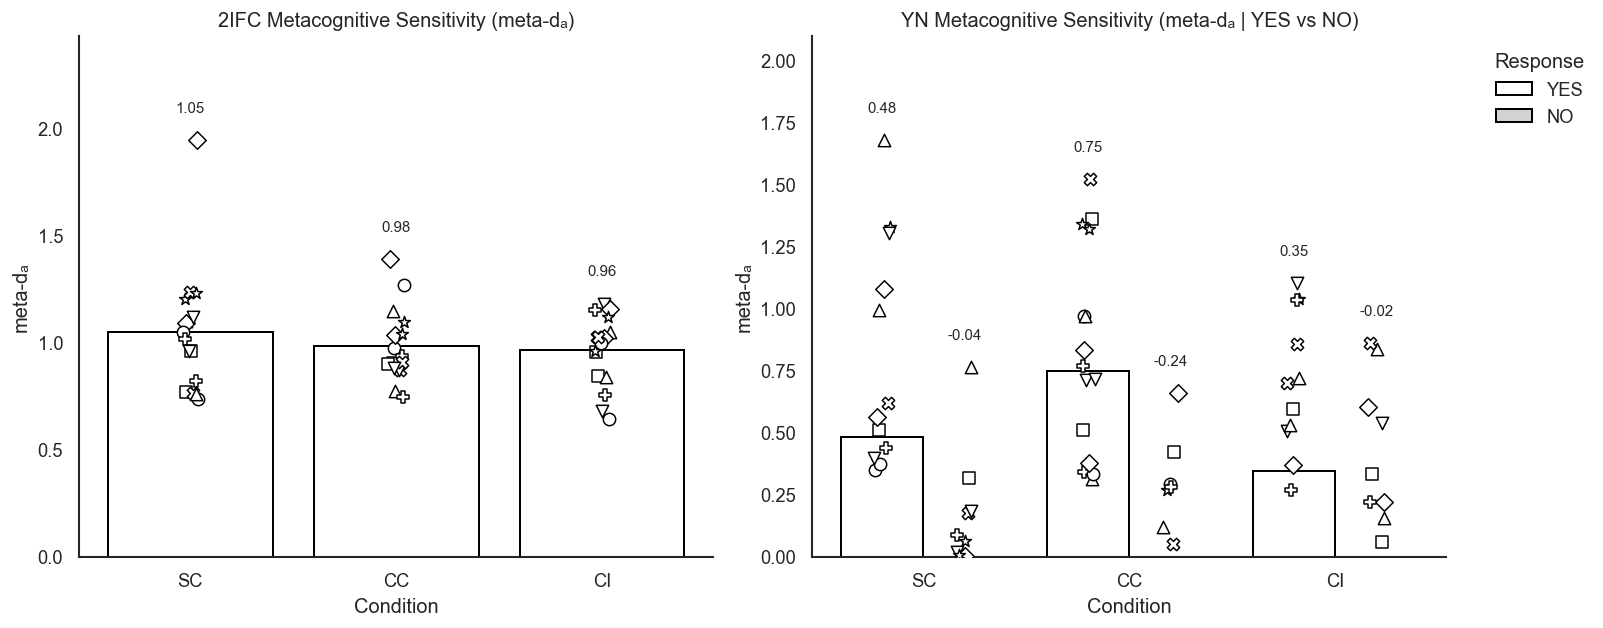

Saved: /Users/w/Desktop/NO NAME/participant_data/GROUP_summary/exp2_GROUP_metaDA_2plots_noColor_noSEM_subjectShapes.png

=== From all_results[mratio] ===
           mean_meta_da  n_rows  n_subjects
Condition                                  
SC             1.104437      16          16
CC             1.323187      16          16
CI             1.226187      16          16

=== From saved 2IFC CSV files ===
           mean_meta_da  n_rows  n_subjects
Condition                                  
SC             1.046875      16          16
CC             0.984187      16          16
CI             0.963125      16          16


In [429]:
# -------------------------------------------
# Exp 2
# -------------------------------------------
# One PNG with 2 separate plots:
# (1) 2IFC meta-d_a (SC/CC/CI)
# (2) YN meta-d_a|YES vs meta-d_a|NO (SC/CC/CI)
# - no color (grayscale only)
# - subject markers: shape only (no color)
# - mean labels placed to avoid overlap with subject points
# -------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


# -------------------
# settings
# -------------------
BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)'
GROUP_OUT = os.path.join(os.path.dirname(BASE_DIR), 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = [
    '00024', '00030', '00074', '00081',
    '000087', '00089', '00091', '00093',
    '00094', '00096', '00097', '00098',
    '00099', '00100', '00102', '00105'
]

cond_order = ['SC','CC','CI']
resp_order = ['YES','NO']

# reproducible jitter
rng = np.random.default_rng(1234)

# marker pool (shape only)
markers = ['o','s','^','D','P','X','*','v']

def _load_csvs(pids, fname_pattern):
    dfs = []
    for pid in pids:
        f = os.path.join(BASE_DIR, pid, 'summary', fname_pattern.format(pid=pid))
        if os.path.exists(f):
            d = pd.read_csv(f)
            d['Subject'] = pid
            dfs.append(d)
    if len(dfs) == 0:
        raise FileNotFoundError(f"No files found for pattern: {fname_pattern}")
    return pd.concat(dfs, ignore_index=True)

def _get_condition_col(df):
    # some saved csvs keep index as "Unnamed: 0"
    if 'Condition' in df.columns:
        return 'Condition'
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Condition'}, inplace=True)
        return 'Condition'
    raise ValueError(f"Cannot find Condition column. Columns: {df.columns.tolist()}")

def _assign_subject_markers(subjects):
    subjects = sorted(list(subjects))
    return {s: markers[i % len(markers)] for i, s in enumerate(subjects)}

def _mean_label_y(mean_y, y_max_points, frac=0.06):
    """
    Place mean label above both (bar mean) and the tallest subject point in that bar-group.
    frac controls vertical padding relative to plot range.
    """
    return max(mean_y, y_max_points) + frac

# -------------------
# 1) Load YN meta (YES/NO conditional)
# -------------------
df_yn_all = _load_csvs(PARTICIPANTS, '{pid}_yn_meta.csv')
cond_col = _get_condition_col(df_yn_all)

# keep
need_yn = ['Subject', cond_col, 'meta_da_yes', 'meta_da_no']
miss = [c for c in need_yn if c not in df_yn_all.columns]
if miss:
    raise ValueError(f"Missing columns in YN meta file(s): {miss}\nColumns: {df_yn_all.columns.tolist()}")

df_yn_all = df_yn_all.rename(columns={cond_col: 'Condition'}).copy()
df_yn_all['Condition'] = df_yn_all['Condition'].astype(str).str.strip()
df_yn_all = df_yn_all[df_yn_all['Condition'].isin(cond_order)].copy()

# long format
df_yn_long = df_yn_all.melt(
    id_vars=['Subject', 'Condition'],
    value_vars=['meta_da_yes', 'meta_da_no'],
    var_name='Response',
    value_name='meta_da_cond'
)

df_yn_long['Response'] = df_yn_long['Response'].map({'meta_da_yes': 'YES', 'meta_da_no': 'NO'})
df_yn_long['meta_da_cond'] = pd.to_numeric(df_yn_long['meta_da_cond'], errors='coerce')

df_yn_long['Condition'] = pd.Categorical(df_yn_long['Condition'], cond_order, ordered=True)
df_yn_long['Response']  = pd.Categorical(df_yn_long['Response'],  resp_order, ordered=True)

yn_mean = (df_yn_long.dropna(subset=['meta_da_cond'])
           .groupby(['Condition','Response'], as_index=False)
           .agg(mean_meta_da=('meta_da_cond','mean')))

yn_mean['Condition'] = pd.Categorical(yn_mean['Condition'], cond_order, ordered=True)
yn_mean['Response']  = pd.Categorical(yn_mean['Response'],  resp_order, ordered=True)
yn_mean = yn_mean.sort_values(['Response','Condition'])

# -------------------
# 2) Load 2IFC meta
# -------------------
df_2ifc_all = _load_csvs(PARTICIPANTS, '{pid}_2ifc_meta.csv')
cond_col2 = _get_condition_col(df_2ifc_all)

need_2ifc = ['Subject', cond_col2, 'meta_da']
miss2 = [c for c in need_2ifc if c not in df_2ifc_all.columns]
if miss2:
    raise ValueError(f"Missing columns in 2IFC meta file(s): {miss2}\nColumns: {df_2ifc_all.columns.tolist()}")

df_2ifc_all = df_2ifc_all.rename(columns={cond_col2: 'Condition'}).copy()
df_2ifc_all['Condition'] = df_2ifc_all['Condition'].astype(str).str.strip()
df_2ifc_all = df_2ifc_all[df_2ifc_all['Condition'].isin(cond_order)].copy()
df_2ifc_all['meta_da'] = pd.to_numeric(df_2ifc_all['meta_da'], errors='coerce')

df_2ifc_all['Condition'] = pd.Categorical(df_2ifc_all['Condition'], cond_order, ordered=True)

twoifc_mean = (df_2ifc_all.dropna(subset=['meta_da'])
               .groupby('Condition', as_index=False)
               .agg(mean_meta_da=('meta_da','mean')))
twoifc_mean['Condition'] = pd.Categorical(twoifc_mean['Condition'], cond_order, ordered=True)
twoifc_mean = twoifc_mean.sort_values('Condition')

# -------------------
# Subject marker mapping (shape-only, shared across both plots)
# -------------------
all_subjects = sorted(set(df_2ifc_all['Subject']).union(set(df_yn_long['Subject'])))
subj_marker = _assign_subject_markers(all_subjects)

# -------------------
# Plot (2 subplots in one PNG)
# -------------------
sns.set(style="white")  # no grid by default
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), dpi=120)

# ==========
# (A) 2IFC meta-d_a
# ==========
ax = axes[0]
sns.barplot(
    data=twoifc_mean,
    x='Condition', y='mean_meta_da',
    order=cond_order,
    color='white',
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    ax=ax
)

# subject points: white fill, black edge (no color)
for subj, sub in df_2ifc_all.groupby('Subject'):
    mkr = subj_marker[subj]
    for i, cond in enumerate(cond_order):
        v = sub.loc[sub['Condition'] == cond, 'meta_da']
        if (not v.empty) and np.isfinite(v.iloc[0]):
            jitter = (rng.random() - 0.5) * 0.08
            ax.scatter(
                i + jitter,
                float(v.iloc[0]),
                marker=mkr,
                s=55,
                facecolors='white',
                edgecolors='black',
                linewidth=0.9,
                zorder=3,
                label='_nolegend_'
            )

# mean labels placed above max(subject point, bar mean) within each condition
# compute max subject point per condition
max_pt = df_2ifc_all.groupby('Condition')['meta_da'].max()
ymax_A = np.nanmax([twoifc_mean['mean_meta_da'].max(),
                    df_2ifc_all['meta_da'].max()])

# dynamic padding based on range
padA = 0.06 * (ymax_A if np.isfinite(ymax_A) and ymax_A > 0 else 1.0)

for i, cond in enumerate(cond_order):
    mean_y = float(twoifc_mean.loc[twoifc_mean['Condition'] == cond, 'mean_meta_da'].values[0]) \
             if (twoifc_mean['Condition'] == cond).any() else np.nan
    pt_y = float(max_pt.loc[cond]) if cond in max_pt.index and np.isfinite(max_pt.loc[cond]) else -np.inf
    if np.isfinite(mean_y):
        ax.text(i, max(mean_y, pt_y) + padA, f'{mean_y:.2f}',
                ha='center', va='bottom', fontsize=9)

ax.set_title('2IFC Metacognitive Sensitivity (meta-dₐ)')
ax.set_xlabel('Condition')
ax.set_ylabel('meta-dₐ')
ax.spines[['top','right']].set_visible(False)
ax.grid(False)

# y-limit with headroom for labels
if np.isfinite(ymax_A):
    ax.set_ylim(0, ymax_A * 1.25)

# ==========
# (B) YN meta-d_a|YES vs meta-d_a|NO
# ==========
ax = axes[1]
sns.barplot(
    data=yn_mean,
    x='Condition', y='mean_meta_da', hue='Response',
    order=cond_order, hue_order=resp_order,
    palette=['white', 'lightgray'],  # grayscale only
    edgecolor='black',
    linewidth=1.2,
    errorbar=None,
    dodge=True,
    ax=ax
)

# subject points per (cond, response)
# compute x positions for dodged bars
idx = np.arange(len(cond_order))
total_w = 0.8
bar_w = total_w / len(resp_order)

for subj, sub in df_yn_long.groupby('Subject'):
    mkr = subj_marker[subj]
    for j, resp in enumerate(resp_order):
        sub_r = sub[sub['Response'] == resp]
        for i, cond in enumerate(cond_order):
            v = sub_r.loc[sub_r['Condition'] == cond, 'meta_da_cond']
            if (not v.empty) and np.isfinite(v.iloc[0]):
                jitter = (rng.random() - 0.5) * 0.08
                x = idx[i] + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(
                    x,
                    float(v.iloc[0]),
                    marker=mkr,
                    s=55,
                    facecolors='white',
                    edgecolors='black',
                    linewidth=0.9,
                    zorder=3,
                    label='_nolegend_'
                )

# mean labels (avoid overlap with tallest subject point in each (cond, resp))
# max subject point per (cond, resp)
max_pt2 = (df_yn_long.groupby(['Condition','Response'])['meta_da_cond'].max())

ymax_B = np.nanmax([yn_mean['mean_meta_da'].max(),
                    df_yn_long['meta_da_cond'].max()])
padB = 0.06 * (ymax_B if np.isfinite(ymax_B) and ymax_B > 0 else 1.0)

# label positions must match dodged bar centers
for j, resp in enumerate(resp_order):
    for i, cond in enumerate(cond_order):
        row = yn_mean[(yn_mean['Condition'] == cond) & (yn_mean['Response'] == resp)]
        if row.empty:
            continue
        mean_y = float(row['mean_meta_da'].iloc[0])
        pt_y = -np.inf
        if (cond, resp) in max_pt2.index and np.isfinite(max_pt2.loc[(cond, resp)]):
            pt_y = float(max_pt2.loc[(cond, resp)])

        x = idx[i] + (-total_w/2 + bar_w/2 + j*bar_w)
        ax.text(x, max(mean_y, pt_y) + padB, f'{mean_y:.2f}',
                ha='center', va='bottom', fontsize=9)

# legend: Response only (YES/NO) — keep clean
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(resp_order)], labels[:len(resp_order)], title='Response', frameon=False,
          bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_title('YN Metacognitive Sensitivity (meta-dₐ | YES vs NO)')
ax.set_xlabel('Condition')
ax.set_ylabel('meta-dₐ')
ax.spines[['top','right']].set_visible(False)
ax.grid(False)

if np.isfinite(ymax_B):
    ax.set_ylim(0, ymax_B * 1.25)

# optional: add a subject marker legend (shape-only) once for the whole figure
# If you want it, uncomment below. (It can get big with many subjects)
"""
subj_handles = [
    Line2D([0],[0], marker=subj_marker[s], color='w',
           markerfacecolor='white', markeredgecolor='black',
           markersize=7, label=s)
    for s in all_subjects
]
axes[1].legend(handles[:len(resp_order)] + subj_handles,
               labels[:len(resp_order)] + [h.get_label() for h in subj_handles],
               title='Response / Subject', frameon=False,
               bbox_to_anchor=(1.05,1), loc='upper left')
"""

plt.tight_layout()

out_png = os.path.join(GROUP_OUT, 'exp2_GROUP_metaDA_2plots_noColor_noSEM_subjectShapes.png')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", out_png)

print('\n=== From all_results[mratio] ===')
print(
    df_m_all.groupby('Condition', observed=True)
    .agg(
        mean_meta_da=('meta_da', 'mean'),
        n_rows=('meta_da', 'count'),
        n_subjects=('Subject', 'nunique')
    )
)

print('\n=== From saved 2IFC CSV files ===')
print(
    df_2ifc_all.groupby('Condition', observed=True)
    .agg(
        mean_meta_da=('meta_da', 'mean'),
        n_rows=('meta_da', 'count'),
        n_subjects=('Subject', 'nunique')
    )
)


=== Saved CSV: 2IFC meta-dₐ ===
           mean_meta_da  n_meta_da  n_subjects
Condition                                     
SC             1.046875         16          16
CC             0.984187         16          16
CI             0.963125         16          16

=== Saved CSV: 2IFC M-ratio ===
           mean_M_ratio  n_M_ratio  n_subjects
Condition                                     
SC             0.702471         16          16
CC             0.637614         16          16
CI             0.680235         16          16


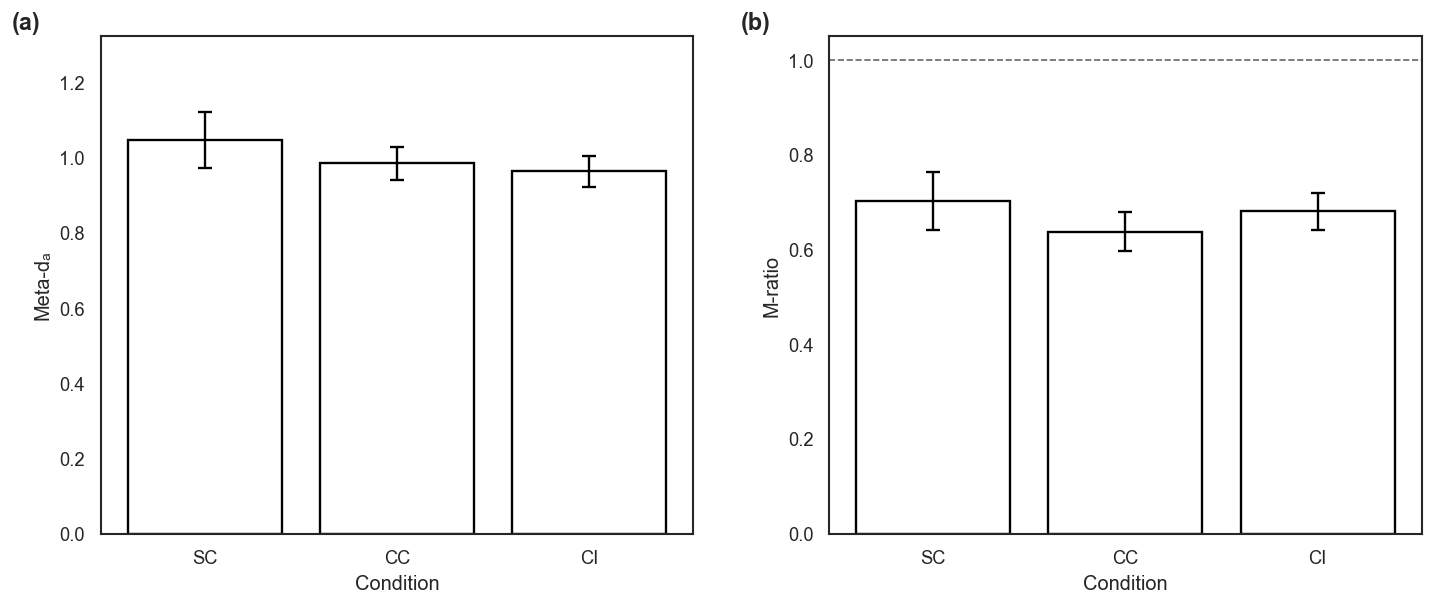


Saved: /Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)/GROUP_summary/GROUP_2IFC_metaDA_and_Mratio_from_saved_CSV.png

=== Saved CSV: 2IFC dₐ ===
            mean_da     sd_da   n
Condition                        
SC         1.524125  0.224930  16
CC         1.587125  0.260090  16
CI         1.454438  0.253853  16

2IFC META-dₐ

Repeated-measures ANOVA
      Source        SS  DF        MS         F     p_unc       ng2      eps
0  Condition  0.060733   2  0.030366  1.247123  0.301802  0.027077  0.96272
1      Error  0.730476  30  0.024349       NaN       NaN       NaN      NaN

Bonferroni pairwise comparisons
 A  B        T  dof    p_unc   p_corr p_adjust   hedges
SC CC 1.163395 15.0 0.262843 0.788528     bonf 0.252237
SC CI 1.392348 15.0 0.184116 0.552347     bonf 0.339248
CC CI 0.412317 15.0 0.685939 1.000000     bonf 0.120807

2IFC M-RATIO

Repeated-measures ANOVA
      Source        SS  DF        MS         F     p_unc       ng2       eps
0  Condition  0.034760   2  0.017380  

In [469]:
# ───────────────────────────────────────────────────────────────
# Supplementary Fig_ Exp2_ GROUP: 2IFC meta-dₐ (left) + M-ratio (right)
# Both measures are calculated from saved {pid}_2ifc_meta.csv files
# ───────────────────────────────────────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Settings
# ============================================================

BASE_DIR = '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)'

# Save inside the experiment folder
GROUP_OUT = os.path.join(BASE_DIR, 'GROUP_summary')
os.makedirs(GROUP_OUT, exist_ok=True)

PARTICIPANTS = [
    '00024', '00030', '00074', '00081',
    '000087', '00089', '00091', '00093',
    '00094', '00096', '00097', '00098',
    '00099', '00100', '00102', '00105'
]

cond_order = ['SC', 'CC', 'CI']


# ============================================================
# 2. Helper functions
# ============================================================

def load_2ifc_meta_csvs(participants):
    dfs = []

    for pid in participants:

        file_path = os.path.join(
            BASE_DIR,
            pid,
            'summary',
            f'{pid}_2ifc_meta.csv'
        )

        if not os.path.exists(file_path):
            print(f'Missing file: {file_path}')
            continue

        df = pd.read_csv(file_path)
        df['Subject'] = pid
        dfs.append(df)

    if len(dfs) == 0:
        raise FileNotFoundError(
            'No participant-level 2IFC meta files were found.'
        )

    return pd.concat(dfs, ignore_index=True)


def get_condition_column(df):

    if 'Condition' in df.columns:
        return 'Condition'

    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Condition'}, inplace=True)
        return 'Condition'

    raise ValueError(
        f'Condition column not found. Columns: {df.columns.tolist()}'
    )


# ============================================================
# 3. Load saved participant-level CSV files
# ============================================================

df_2ifc_all = load_2ifc_meta_csvs(PARTICIPANTS)

condition_col = get_condition_column(df_2ifc_all)

if condition_col != 'Condition':
    df_2ifc_all = df_2ifc_all.rename(
        columns={condition_col: 'Condition'}
    )

required_columns = [
    'Subject',
    'Condition',
    'meta_da',
    'da'
]

missing_columns = [
    col for col in required_columns
    if col not in df_2ifc_all.columns
]

if missing_columns:
    raise ValueError(
        f'Missing required columns: {missing_columns}\n'
        f'Available columns: {df_2ifc_all.columns.tolist()}'
    )


# ============================================================
# 4. Clean values and calculate M-ratio
# ============================================================

df_2ifc_all['Condition'] = (
    df_2ifc_all['Condition']
    .astype(str)
    .str.strip()
)

df_2ifc_all = df_2ifc_all[
    df_2ifc_all['Condition'].isin(cond_order)
].copy()

df_2ifc_all['meta_da'] = pd.to_numeric(
    df_2ifc_all['meta_da'],
    errors='coerce'
)

df_2ifc_all['da'] = pd.to_numeric(
    df_2ifc_all['da'],
    errors='coerce'
)

# Avoid division by zero
df_2ifc_all.loc[
    df_2ifc_all['da'] == 0,
    'da'
] = np.nan

df_2ifc_all['M_ratio'] = (
    df_2ifc_all['meta_da']
    / df_2ifc_all['da']
)

df_2ifc_all = df_2ifc_all.replace(
    [np.inf, -np.inf],
    np.nan
)

df_2ifc_all['Condition'] = pd.Categorical(
    df_2ifc_all['Condition'],
    categories=cond_order,
    ordered=True
)


# ============================================================
# 5. Means
# ============================================================

meta_mean = (
    df_2ifc_all
    .dropna(subset=['meta_da'])
    .groupby(
        'Condition',
        observed=True,
        as_index=False
    )
    .agg(
        mean=('meta_da', 'mean')
    )
    .sort_values('Condition')
    .reset_index(drop=True)
)

mratio_mean = (
    df_2ifc_all
    .dropna(subset=['M_ratio'])
    .groupby(
        'Condition',
        observed=True,
        as_index=False
    )
    .agg(
        mean=('M_ratio', 'mean')
    )
    .sort_values('Condition')
    .reset_index(drop=True)
)


# ============================================================
# Condition-wise mean and ordinary SEM across participants
# ============================================================

meta_summary = (
    df_2ifc_all
    .dropna(subset=['meta_da'])
    .groupby('Condition', observed=True, as_index=False)
    .agg(
        mean=('meta_da', 'mean'),
        sd=('meta_da', 'std'),
        n=('meta_da', 'count')
    )
)

meta_summary['sem'] = (
    meta_summary['sd']
    / np.sqrt(meta_summary['n'])
)

meta_summary['Condition'] = pd.Categorical(
    meta_summary['Condition'],
    categories=cond_order,
    ordered=True
)

meta_summary = (
    meta_summary
    .sort_values('Condition')
    .reset_index(drop=True)
)


mratio_summary = (
    df_2ifc_all
    .dropna(subset=['M_ratio'])
    .groupby('Condition', observed=True, as_index=False)
    .agg(
        mean=('M_ratio', 'mean'),
        sd=('M_ratio', 'std'),
        n=('M_ratio', 'count')
    )
)

mratio_summary['sem'] = (
    mratio_summary['sd']
    / np.sqrt(mratio_summary['n'])
)

mratio_summary['Condition'] = pd.Categorical(
    mratio_summary['Condition'],
    categories=cond_order,
    ordered=True
)

mratio_summary = (
    mratio_summary
    .sort_values('Condition')
    .reset_index(drop=True)
)

# ============================================================
# 7. Verify that means match
# ============================================================

print('\n=== Saved CSV: 2IFC meta-dₐ ===')
print(
    df_2ifc_all.groupby(
        'Condition',
        observed=True
    ).agg(
        mean_meta_da=('meta_da', 'mean'),
        n_meta_da=('meta_da', 'count'),
        n_subjects=('Subject', 'nunique')
    )
)

print('\n=== Saved CSV: 2IFC M-ratio ===')
print(
    df_2ifc_all.groupby(
        'Condition',
        observed=True
    ).agg(
        mean_M_ratio=('M_ratio', 'mean'),
        n_M_ratio=('M_ratio', 'count'),
        n_subjects=('Subject', 'nunique')
    )
)


# ============================================================
# 8. Subject markers
# ============================================================

x = np.arange(len(cond_order))


# ============================================================
# 9. Plot
# ============================================================

sns.set_style('white')

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 5.2),
    dpi=120
)


# ------------------------------------------------------------
# Panel A: 2IFC meta-dₐ
# ------------------------------------------------------------

ax = axes[0]

sns.barplot(
    data=meta_summary,
    x='Condition',
    y='mean',
    order=cond_order,
    color='white',
    edgecolor='black',
    linewidth=1.4,
    errorbar=None,
    ax=ax
)

ax.errorbar(
    x=x,
    y=meta_summary['mean'].to_numpy(),
    yerr=meta_summary['sem'].to_numpy(),
    fmt='none',
    ecolor='black',
    elinewidth=1.4,
    capsize=4,
    capthick=1.4,
    zorder=3
)

ax.set_ylabel('Meta-dₐ')

meta_values = (
    meta_summary['mean'].to_numpy(dtype=float)
    + meta_summary['sem'].to_numpy(dtype=float)
)

meta_values = meta_values[
    np.isfinite(meta_values)
]

if len(meta_values) > 0:

    meta_min = np.min(meta_values)
    meta_max = np.max(meta_values)

    if meta_min >= 0:
        ax.set_ylim(0, meta_max * 1.18)
    else:
        margin = (
            meta_max - meta_min
        ) * 0.12

        ax.set_ylim(
            meta_min - margin,
            meta_max + margin
        )


# ------------------------------------------------------------
# Panel B: 2IFC M-ratio
# ------------------------------------------------------------

ax = axes[1]
sns.barplot(
    data=mratio_summary,
    x='Condition',
    y='mean',
    order=cond_order,
    color='white',
    edgecolor='black',
    linewidth=1.4,
    errorbar=None,
    ax=ax
)

ax.errorbar(
    x=x,
    y=mratio_summary['mean'].to_numpy(),
    yerr=mratio_summary['sem'].to_numpy(),
    fmt='none',
    ecolor='black',
    elinewidth=1.4,
    capsize=4,
    capthick=1.4,
    zorder=3
)

# Reference line: M-ratio = 1
ax.axhline(
    1,
    linestyle='--',
    linewidth=1.0,
    color='black',
    alpha=0.6,
    zorder=1
)

ax.set_ylabel('M-ratio')

mratio_values = (
    mratio_summary['mean'].to_numpy(dtype=float)
    + mratio_summary['sem'].to_numpy(dtype=float)
)

mratio_values = mratio_values[
    np.isfinite(mratio_values)
]

if len(mratio_values) > 0:

    mratio_min = np.min(mratio_values)
    mratio_max = np.max(mratio_values)

    if mratio_min >= 0:
        ax.set_ylim(
            0,
            max(1.05, mratio_max * 1.18)
        )
    else:
        margin = (
            mratio_max - mratio_min
        ) * 0.12

        ax.set_ylim(
            mratio_min - margin,
            max(1.05, mratio_max + margin)
        )


# ============================================================
# 10. Panel labels and save
# ============================================================

axes[0].text(
    -0.15,
    1.05,
    '(a)',
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)

axes[1].text(
    -0.15,
    1.05,
    '(b)',
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top'
)

plt.tight_layout(w_pad=3.0)

out_path = os.path.join(
    GROUP_OUT,
    'GROUP_2IFC_metaDA_and_Mratio_from_saved_CSV.png'
)

plt.savefig(
    out_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('\nSaved:', out_path)

print('\n=== Saved CSV: 2IFC dₐ ===')
print(
    df_2ifc_all.groupby(
        'Condition',
        observed=True
    ).agg(
        mean_da=('da', 'mean'),
        sd_da=('da', 'std'),
        n=('da', 'count')
    )
)

# ============================================================
# One-way repeated-measures ANOVA
# meta-dₐ and M-ratio
# ============================================================

import pingouin as pg

def print_pairwise_results(result_df, title):

    print("\n" + title)

    preferred_columns = [
        'A',
        'B',
        'T',
        'dof',
        'p_unc',
        'p_corr',
        'p_adjust',
        'hedges'
    ]

    available_columns = [
        col for col in preferred_columns
        if col in result_df.columns
    ]

    print(result_df[available_columns].to_string(index=False))
# ------------------------------------------------------------
# 1. meta-dₐ
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2IFC META-dₐ")
print("=" * 70)

anova_meta = pg.rm_anova(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    detailed=True
)

print("\nRepeated-measures ANOVA")
print(anova_meta)

posthoc_meta = pg.pairwise_tests(
    data=df_2ifc_all,
    dv='meta_da',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print_pairwise_results(
    posthoc_meta,
    "Bonferroni pairwise comparisons"
)


# ------------------------------------------------------------
# 2. M-ratio
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2IFC M-RATIO")
print("=" * 70)

anova_mratio = pg.rm_anova(
    data=df_2ifc_all,
    dv='M_ratio',
    within='Condition',
    subject='Subject',
    detailed=True
)

print("\nRepeated-measures ANOVA")
print(anova_mratio)

posthoc_mratio = pg.pairwise_tests(
    data=df_2ifc_all,
    dv='M_ratio',
    within='Condition',
    subject='Subject',
    padjust='bonf',
    effsize='hedges'
)

print_pairwise_results(
    posthoc_mratio,
    "Bonferroni pairwise comparisons"
)


=== Participant-level 2IFC metacognition values ===
     Experiment Subject Condition  meta_da    da  M_ratio
          Exp 1   00139        SC    0.975 2.274 0.428760
          Exp 1   00139        CC    0.873 2.161 0.403980
          Exp 1   00139        CI    1.007 1.889 0.533086
          Exp 1   00173        SC    0.945 1.549 0.610071
          Exp 1   00173        CC    1.498 1.344 1.114583
          Exp 1   00173        CI    2.461 1.278 1.925665
          Exp 1   00210        SC    1.889 1.298 1.455316
          Exp 1   00210        CC    2.263 1.410 1.604965
          Exp 1   00210        CI    1.439 1.416 1.016243
          Exp 1   00212        SC    0.921 1.473 0.625255
          Exp 1   00212        CC    1.366 1.170 1.167521
          Exp 1   00212        CI    1.278 1.224 1.044118
          Exp 1   00216        SC    1.191 1.546 0.770375
          Exp 1   00216        CC    1.313 1.416 0.927260
          Exp 1   00216        CI    1.131 1.613 0.701178
          Exp 1   0

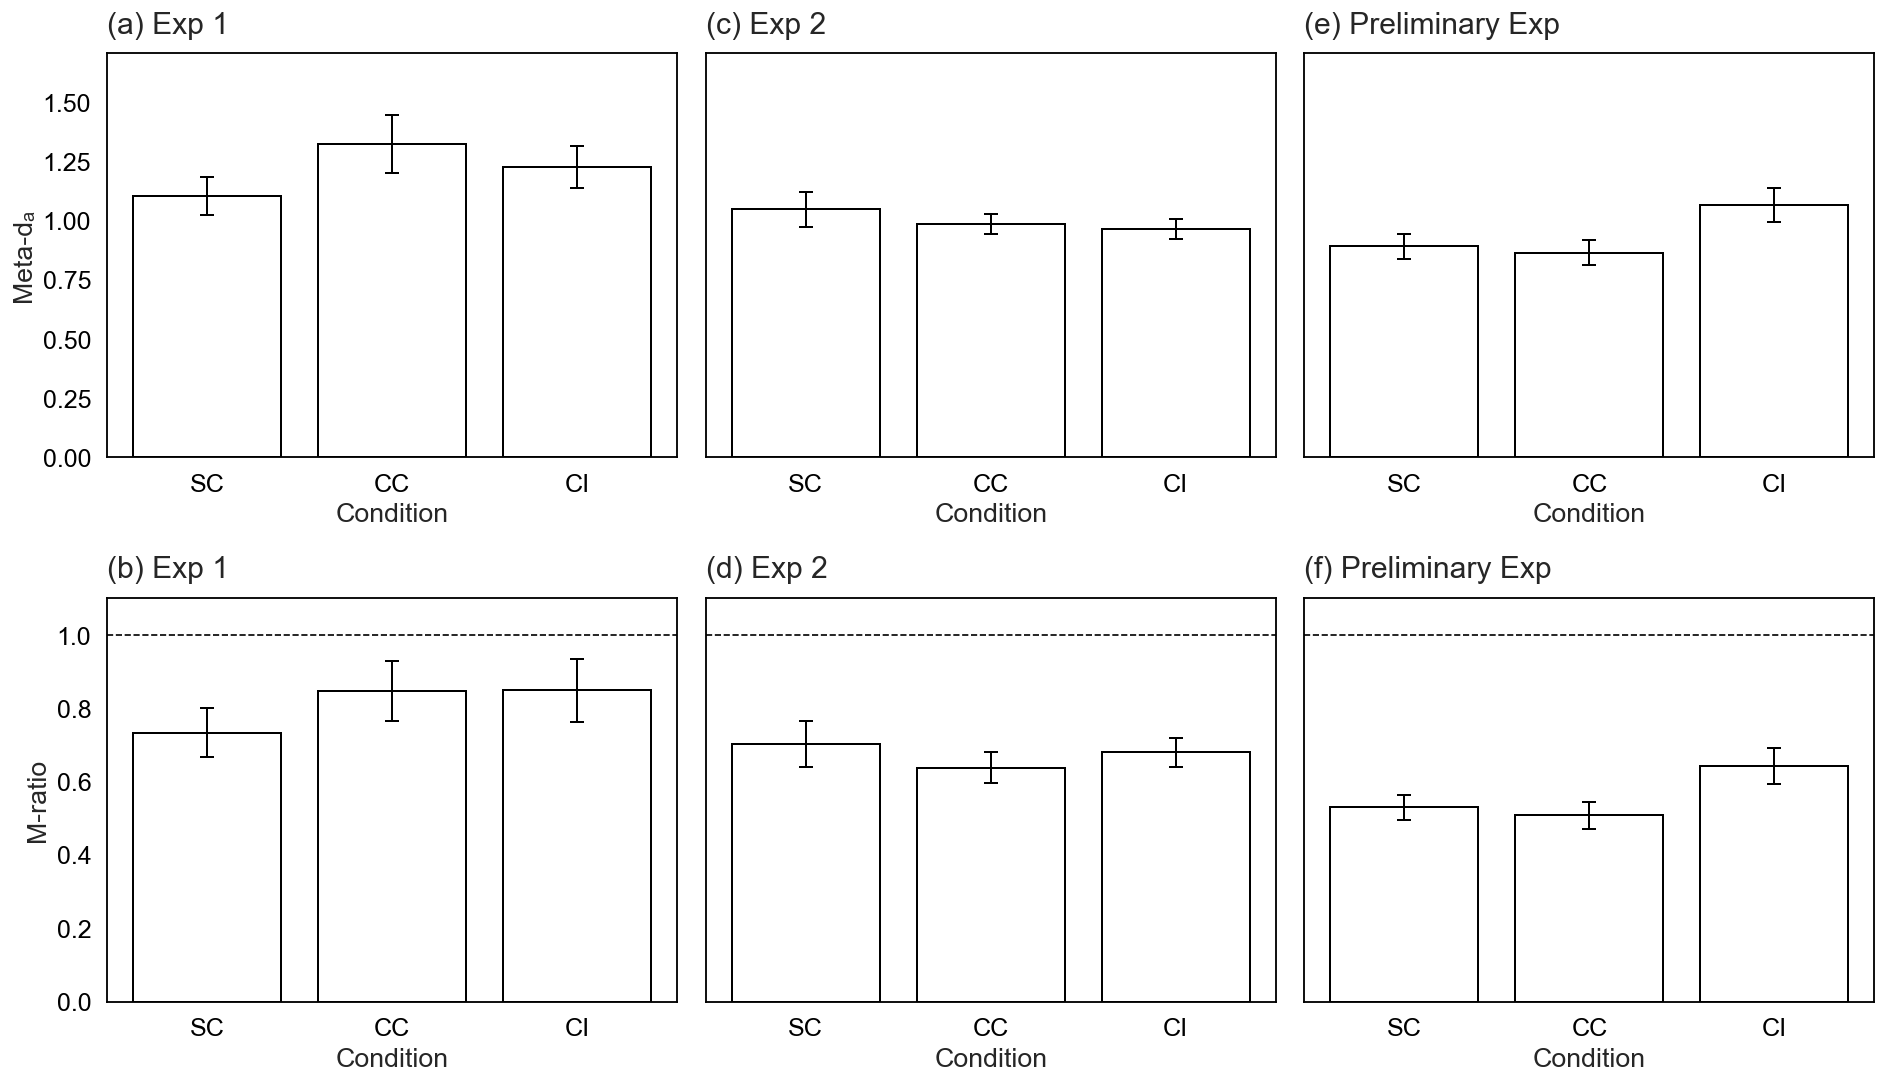


Saved participant-level values → /Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/new_exp_GROUP_summary/Exp1-3_2IFC_meta_participant_level.csv
Saved mean / SD / SEM summary → /Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/new_exp_GROUP_summary/Exp1-3_2IFC_meta_mean_SD_SEM.csv
Saved figure → /Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/new_exp_GROUP_summary/SuppFigure_Exp1-3_2IFC_metaDA_Mratio_abcdef_ordinarySEM.png
CSV loaded from:
/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)/new_exp_GROUP_summary/Exp1-3_2IFC_meta_participant_level.csv

Columns:
['Experiment', 'Subject', 'Condition', 'meta_da', 'da', 'M_ratio']

Experiments:
['Exp 1' 'Exp 2' 'Preliminary Exp']

Number of participants per experiment:
Experiment
Exp 1              16
Exp 2              16
Preliminary Exp    16
Name: Subject, dtype: int64



EXP 1
N = 16 participants

----------------------------------------------------------------------
2IFC META-dₐ
-----------------------------------------

In [493]:
# ============================================================
# Supplementary Figure:
# Exp1–Exp3 2IFC meta-dₐ and M-ratio
#
# Top row:    meta-dₐ
# Bottom row: M-ratio
#
# Ordinary SEM across participants
# No participant markers
# Data source: saved {pid}_2ifc_meta.csv files
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. Experiment information
# ============================================================

EXPERIMENTS = [
    {
        'name': 'Exp 1',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp3 (n=16)',
        'group_out': 'new_exp_GROUP_summary',
        'participants': [
            '00139', '00173', '00212', '00216',
            '00218', '00219', '00220', '00222',
            '00224', '00225', '00226', '00227',
            '00228', '00217', '00210', '00223'
        ]
    },
    
    {
        'name': 'Exp 2',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp2 (n=16)',
        'group_out': 'GROUP_summary',
        'participants': [
            '00024', '00030', '00074', '00081',
            '000087', '00089', '00091', '00093',
            '00094', '00096', '00097', '00098',
            '00099', '00100', '00102', '00105'
        ]
    },

    {
        'name': 'Preliminary Exp',
        'base_dir': '/Users/w/Desktop/NO NAME/participant_data/exp1 (n=8+8)',
        'group_out': 'GROUP_summary',
        'participants': [
            '00003', '00038', '00051', '00052',
            '00054', '00060', '00061', '00068',
            '00071', '00130', '00161', '00162',
            '00193', '00200', '00201', '00202'
        ]
    }
]

cond_order = ['SC', 'CC', 'CI']


# ============================================================
# 2. Figure style
# ============================================================

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15
})

sns.set_style('white')


# ============================================================
# 3. Helper functions
# ============================================================

def format_axes(ax):
    """Apply the same axis style as the accuracy supplementary figure."""

    ax.grid(False)

    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color('black')

    ax.tick_params(
        axis='both',
        colors='black'
    )


def get_condition_column(df):
    """Identify and standardize the condition column."""

    if 'Condition' in df.columns:
        return df

    if 'Unnamed: 0' in df.columns:
        return df.rename(
            columns={'Unnamed: 0': 'Condition'}
        )

    raise ValueError(
        'Condition column not found. '
        f'Available columns: {df.columns.tolist()}'
    )


def load_experiment_meta_data(base_dir, participants):
    """
    Load the saved participant-level 2IFC metacognition files.

    Expected location:
    base_dir / participant / summary / participant_2ifc_meta.csv
    """

    participant_dfs = []

    for pid in participants:

        file_path = os.path.join(
            base_dir,
            pid,
            'summary',
            f'{pid}_2ifc_meta.csv'
        )

        if not os.path.exists(file_path):
            print(f'Missing file: {file_path}')
            continue

        df = pd.read_csv(file_path)

        df.columns = (
            df.columns
            .astype(str)
            .str.strip()
        )

        df = get_condition_column(df)

        required_columns = {
            'Condition',
            'meta_da',
            'da'
        }

        if not required_columns.issubset(df.columns):
            print(
                f'Missing required columns for participant {pid}: '
                f'{df.columns.tolist()}'
            )
            continue

        df['Subject'] = pid

        participant_dfs.append(
            df[
                [
                    'Subject',
                    'Condition',
                    'meta_da',
                    'da'
                ]
            ].copy()
        )

    if len(participant_dfs) == 0:
        raise FileNotFoundError(
            f'No participant-level 2IFC meta files found in {base_dir}'
        )

    df_all = pd.concat(
        participant_dfs,
        ignore_index=True
    )

    # Clean condition labels
    df_all['Condition'] = (
        df_all['Condition']
        .astype(str)
        .str.strip()
    )

    df_all = df_all[
        df_all['Condition'].isin(cond_order)
    ].copy()

    # Convert measure columns to numeric
    df_all['meta_da'] = pd.to_numeric(
        df_all['meta_da'],
        errors='coerce'
    )

    df_all['da'] = pd.to_numeric(
        df_all['da'],
        errors='coerce'
    )

    # Avoid division by zero
    df_all.loc[
        df_all['da'] == 0,
        'da'
    ] = np.nan

    # Participant-level M-ratio
    df_all['M_ratio'] = (
        df_all['meta_da']
        / df_all['da']
    )

    df_all = df_all.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df_all['Condition'] = pd.Categorical(
        df_all['Condition'],
        categories=cond_order,
        ordered=True
    )

    return df_all


def calculate_summary(df, measure):
    """
    Calculate condition-wise group mean, SD, N, and ordinary SEM.

    SEM = SD across participants / sqrt(N)
    """

    summary = (
        df
        .dropna(subset=[measure])
        .groupby(
            'Condition',
            observed=True,
            as_index=False
        )
        .agg(
            mean=(measure, 'mean'),
            SD=(measure, 'std'),
            N=(measure, 'count')
        )
    )

    summary['SEM'] = (
        summary['SD']
        / np.sqrt(summary['N'])
    )

    summary['Condition'] = pd.Categorical(
        summary['Condition'],
        categories=cond_order,
        ordered=True
    )

    summary = (
        summary
        .sort_values('Condition')
        .reset_index(drop=True)
    )

    return summary


def plot_measure(
    ax,
    summary,
    panel_label,
    exp_name,
    ylabel,
    ylim,
    reference_line=None
):
    """Plot one measure using group means and ordinary SEM."""

    x = np.arange(len(cond_order))

    sns.barplot(
        data=summary,
        x='Condition',
        y='mean',
        order=cond_order,
        color='white',
        edgecolor='black',
        linewidth=1.2,
        errorbar=None,
        ax=ax
    )

    ax.errorbar(
        x=x,
        y=summary['mean'].to_numpy(dtype=float),
        yerr=summary['SEM'].to_numpy(dtype=float),
        fmt='none',
        ecolor='black',
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=3
    )

    if reference_line is not None:
        ax.axhline(
            reference_line,
            linestyle='--',
            color='black',
            linewidth=1.0,
            zorder=0
        )

    ax.set_title(
        f'{panel_label} {exp_name}',
        loc='left',
        pad=12
    )

    ax.set_xlabel('Condition')
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)

    format_axes(ax)


# ============================================================
# 4. Load and summarize all experiments
# ============================================================

all_data = []

for exp in EXPERIMENTS:

    df_meta = load_experiment_meta_data(
        exp['base_dir'],
        exp['participants']
    )

    meta_summary = calculate_summary(
        df_meta,
        'meta_da'
    )

    mratio_summary = calculate_summary(
        df_meta,
        'M_ratio'
    )

    all_data.append({
        'name': exp['name'],
        'df': df_meta,
        'meta_summary': meta_summary,
        'mratio_summary': mratio_summary
    })


# ============================================================
# 5. Determine common y-axis ranges
# ============================================================

# Common Meta-dₐ scale across Experiments 1–3
all_meta_upper = []

for exp_data in all_data:
    summary = exp_data['meta_summary']

    all_meta_upper.extend(
        (
            summary['mean']
            + summary['SEM']
        ).dropna().tolist()
    )

if len(all_meta_upper) > 0:
    meta_upper_limit = max(all_meta_upper) * 1.18
else:
    meta_upper_limit = 1

meta_ylim = (
    0,
    meta_upper_limit
)


# Common M-ratio scale across Experiments 1–3
all_mratio_upper = []

for exp_data in all_data:
    summary = exp_data['mratio_summary']

    all_mratio_upper.extend(
        (
            summary['mean']
            + summary['SEM']
        ).dropna().tolist()
    )

if len(all_mratio_upper) > 0:
    mratio_upper_limit = max(
        1.05,
        max(all_mratio_upper) * 1.18
    )
else:
    mratio_upper_limit = 1.05

mratio_ylim = (
    0,
    mratio_upper_limit
)


# ============================================================
# 6. Plot 2 × 3 figure
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9.5),
    dpi=120,
    sharey='row'
)

axes = axes.flatten()

meta_axes = [0, 1, 2]
mratio_axes = [3, 4, 5]

meta_labels = ['(a)', '(c)', '(e)']
mratio_labels = ['(b)', '(d)', '(f)']


for i, exp_data in enumerate(all_data):

    # Top row: Meta-dₐ
    plot_measure(
        ax=axes[meta_axes[i]],
        summary=exp_data['meta_summary'],
        panel_label=meta_labels[i],
        exp_name=exp_data['name'],
        ylabel='Meta-dₐ',
        ylim=meta_ylim,
        reference_line=None
    )

    # Bottom row: M-ratio
    plot_measure(
        ax=axes[mratio_axes[i]],
        summary=exp_data['mratio_summary'],
        panel_label=mratio_labels[i],
        exp_name=exp_data['name'],
        ylabel='M-ratio',
        ylim=mratio_ylim,
        reference_line=1
    )


plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


# ============================================================
# 7. Save participant-level data and SEM summaries
# ============================================================

OUT_DIR = os.path.join(
    EXPERIMENTS[0]['base_dir'],
    EXPERIMENTS[0]['group_out']
)

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# Combine participant-level values
participant_level_all = pd.concat(
    [
        exp_data['df'].assign(
            Experiment=exp_data['name']
        )
        for exp_data in all_data
    ],
    ignore_index=True
)

participant_level_all = participant_level_all[
    [
        'Experiment',
        'Subject',
        'Condition',
        'meta_da',
        'da',
        'M_ratio'
    ]
].sort_values(
    [
        'Experiment',
        'Subject',
        'Condition'
    ]
)


# Combine summaries
summary_rows = []

for exp_data in all_data:

    meta_tmp = (
        exp_data['meta_summary']
        .copy()
        .assign(
            Experiment=exp_data['name'],
            Measure='Meta-dₐ'
        )
    )

    mratio_tmp = (
        exp_data['mratio_summary']
        .copy()
        .assign(
            Experiment=exp_data['name'],
            Measure='M-ratio'
        )
    )

    summary_rows.extend(
        [meta_tmp, mratio_tmp]
    )

summary_all = pd.concat(
    summary_rows,
    ignore_index=True
)

summary_all = summary_all[
    [
        'Experiment',
        'Measure',
        'Condition',
        'mean',
        'SD',
        'N',
        'SEM'
    ]
].sort_values(
    [
        'Experiment',
        'Measure',
        'Condition'
    ]
)


# Print values
print(
    '\n=== Participant-level 2IFC metacognition values ==='
)
print(
    participant_level_all.to_string(index=False)
)

print(
    '\n=== 2IFC meta-dₐ and M-ratio mean / SD / SEM ==='
)
print(
    summary_all.to_string(index=False)
)


# Save CSV files
participant_csv_path = os.path.join(
    OUT_DIR,
    'Exp1-3_2IFC_meta_participant_level.csv'
)

summary_csv_path = os.path.join(
    OUT_DIR,
    'Exp1-3_2IFC_meta_mean_SD_SEM.csv'
)

participant_level_all.to_csv(
    participant_csv_path,
    index=False
)

summary_all.to_csv(
    summary_csv_path,
    index=False
)


# ============================================================
# 8. Save figure
# ============================================================

figure_path = os.path.join(
    OUT_DIR,
    'SuppFigure_Exp1-3_2IFC_metaDA_Mratio_abcdef_ordinarySEM.png'
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    f'\nSaved participant-level values → '
    f'{participant_csv_path}'
)

print(
    f'Saved mean / SD / SEM summary → '
    f'{summary_csv_path}'
)

print(
    f'Saved figure → '
    f'{figure_path}'
)

# ============================================================
# Experiment 1, 2, Preliminary Experiment:
# One-way repeated-measures ANOVA
# 2IFC meta-dₐ and M-ratio
# ============================================================

import pandas as pd
import pingouin as pg


# ------------------------------------------------------------
# 1. Load the combined participant-level data
# ------------------------------------------------------------

# 위 figure 코드에서 방금 저장한 CSV 사용
csv_path = participant_csv_path

df_2ifc_all = pd.read_csv(
    csv_path,
    dtype={'Subject': str}
)

# Remove accidental spaces from column names
df_2ifc_all.columns = df_2ifc_all.columns.str.strip()

# Remove accidental spaces from labels
df_2ifc_all['Experiment'] = (
    df_2ifc_all['Experiment']
    .astype(str)
    .str.strip()
)

df_2ifc_all['Condition'] = (
    df_2ifc_all['Condition']
    .astype(str)
    .str.strip()
)

print('CSV loaded from:')
print(csv_path)

print('\nColumns:')
print(df_2ifc_all.columns.tolist())

print('\nExperiments:')
print(df_2ifc_all['Experiment'].unique())

print('\nNumber of participants per experiment:')
print(
    df_2ifc_all.groupby('Experiment')['Subject']
    .nunique()
)
# ------------------------------------------------------------
# 2. Function for printing pairwise comparisons
# ------------------------------------------------------------

def print_pairwise_results(result_df, title):

    print("\n" + title)

    preferred_columns = [
        "A",
        "B",
        "T",
        "dof",
        "p_unc",
        "p_corr",
        "p_adjust",
        "hedges"
    ]

    available_columns = [
        col for col in preferred_columns
        if col in result_df.columns
    ]

    print(result_df[available_columns].to_string(index=False))


# ------------------------------------------------------------
# 3. Function for running each dependent variable
# ------------------------------------------------------------

def run_rm_anova(df_exp, dv, measure_name):

    print("\n" + "-" * 70)
    print(measure_name)
    print("-" * 70)

    # Descriptive statistics
    descriptives = (
        df_exp.groupby("Condition")[dv]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    descriptives["sem"] = (
        descriptives["std"] /
        descriptives["count"] ** 0.5
    )

    print("\nDescriptive statistics")
    print(descriptives.to_string(index=False))


    # Repeated-measures ANOVA
    anova = pg.rm_anova(
        data=df_exp,
        dv=dv,
        within="Condition",
        subject="Subject",
        detailed=True,
        effsize="ng2"
    )

    print("\nRepeated-measures ANOVA")
    print(anova.to_string(index=False))


    # Bonferroni-corrected pairwise tests
    posthoc = pg.pairwise_tests(
        data=df_exp,
        dv=dv,
        within="Condition",
        subject="Subject",
        padjust="bonf",
        effsize="hedges"
    )

    print_pairwise_results(
        posthoc,
        "\nBonferroni-corrected pairwise comparisons"
    )

    return anova, posthoc, descriptives


# ------------------------------------------------------------
# 4. Run Experiment 1, 2, and 3 separately
# ------------------------------------------------------------

all_results = {}

experiment_order = ["Exp 1", "Exp 2", "Preliminary Exp"]

for exp in experiment_order:

    df_exp = df_2ifc_all[
        df_2ifc_all["Experiment"] == exp
    ].copy()

    print("\n\n")
    print("=" * 80)
    print(exp.upper())
    print("=" * 80)

    print(
        f"N = {df_exp['Subject'].nunique()} participants"
    )

    # Check that every participant has SC, CC, and CI
    condition_counts = (
        df_exp.groupby("Subject")["Condition"]
        .nunique()
    )

    incomplete_subjects = condition_counts[
        condition_counts < 3
    ]

    if len(incomplete_subjects) > 0:
        print("\nWarning: incomplete participants")
        print(incomplete_subjects)


    # meta-dₐ
    meta_results = run_rm_anova(
        df_exp=df_exp,
        dv="meta_da",
        measure_name="2IFC META-dₐ"
    )


    # M-ratio
    mratio_results = run_rm_anova(
        df_exp=df_exp,
        dv="M_ratio",
        measure_name="2IFC M-RATIO"
    )


    all_results[exp] = {
        "meta_da": {
            "anova": meta_results[0],
            "posthoc": meta_results[1],
            "descriptives": meta_results[2]
        },
        "M_ratio": {
            "anova": mratio_results[0],
            "posthoc": mratio_results[1],
            "descriptives": mratio_results[2]
        }
    }